<a href="https://colab.research.google.com/github/Payoshnee/Breast-Cancer-Detection-Mammogram-Images-/blob/main/MBC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:111: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


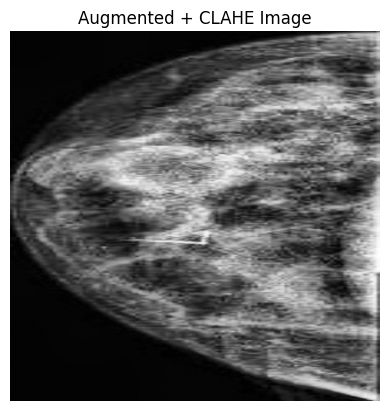

✅ Processed image saved at: /content/sample_image_processed.jpg


In [ ]:
import cv2
import os
import albumentations as A
import numpy as np
from matplotlib import pyplot as plt

# Define augmentation pipeline
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomBrightnessContrast(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.5)
])

# CLAHE function
def apply_clahe(gray_img):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(gray_img)

# Auto-cropping black background
def auto_crop_black(image, threshold=10):
    if len(image.shape) == 2:  # grayscale
        gray = image
    else:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    mask = gray > threshold
    if np.any(mask):
        coords = np.argwhere(mask)
        y0, x0 = coords.min(axis=0)
        y1, x1 = coords.max(axis=0) + 1
        return image[y0:y1, x0:x1]
    else:
        return image  # Return original if all black

# Preprocess a single image
def preprocess_single_image(img_path, target_size=(512, 512)):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"❌ Error reading image: {img_path}")
        return None

    cropped_img = auto_crop_black(img)
    resized_img = cv2.resize(cropped_img, target_size)

    # Convert to RGB for augmentation
    img_rgb = cv2.cvtColor(resized_img, cv2.COLOR_GRAY2RGB)
    augmented = augment(image=img_rgb)['image']

    # Back to grayscale
    gray_aug = cv2.cvtColor(augmented, cv2.COLOR_RGB2GRAY)

    # Apply CLAHE
    clahe_img = apply_clahe(gray_aug)
    return clahe_img

# Show image using matplotlib (for local or Colab)
def show_image(img, title="Output"):
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# === Run for one image ===
input_image = "/content/drive/MyDrive/Dataset/Cancer/mal50019.jpg"  # 🔁 Replace with your actual image path
output_path = "/content/sample_image_processed.jpg"

processed_image = preprocess_single_image(input_image)

if processed_image is not None:
    show_image(processed_image, "Augmented + CLAHE Image")
    cv2.imwrite(output_path, processed_image)
    print(f"✅ Processed image saved at: {output_path}")


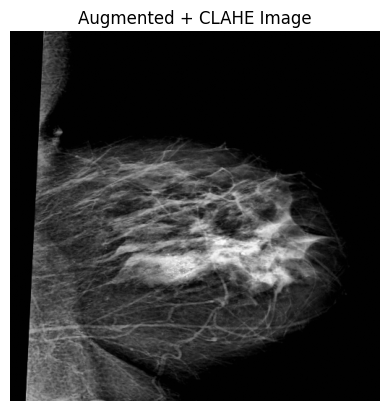

✅ Processed image saved at: /content/sample_image_processed.jpg


In [ ]:
import cv2
import os
import albumentations as A
import numpy as np
from matplotlib import pyplot as plt

# Define augmentation pipeline
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomBrightnessContrast(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.5)
])

# CLAHE function
def apply_clahe(gray_img):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(gray_img)

# Auto-cropping black background
def auto_crop_black(image, threshold=10):
    if len(image.shape) == 2:  # grayscale
        gray = image
    else:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    mask = gray > threshold
    if np.any(mask):
        coords = np.argwhere(mask)
        y0, x0 = coords.min(axis=0)
        y1, x1 = coords.max(axis=0) + 1
        return image[y0:y1, x0:x1]
    else:
        return image  # Return original if all black

# Preprocess a single image
def preprocess_single_image(img_path, target_size=(512, 512)):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"❌ Error reading image: {img_path}")
        return None

    cropped_img = auto_crop_black(img)
    resized_img = cv2.resize(cropped_img, target_size)

    # Convert to RGB for augmentation
    img_rgb = cv2.cvtColor(resized_img, cv2.COLOR_GRAY2RGB)
    augmented = augment(image=img_rgb)['image']

    # Back to grayscale
    gray_aug = cv2.cvtColor(augmented, cv2.COLOR_RGB2GRAY)

    # Apply CLAHE
    clahe_img = apply_clahe(gray_aug)
    return clahe_img

# Show image using matplotlib (for local or Colab)
def show_image(img, title="Output"):
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# === Run for one image ===
input_image = "/content/drive/MyDrive/Dataset/Cancer/IMG (1).jpg"  # 🔁 Replace with your actual image path
output_path = "/content/sample_image_processed.jpg"

processed_image = preprocess_single_image(input_image)

if processed_image is not None:
    show_image(processed_image, "Augmented + CLAHE Image")
    cv2.imwrite(output_path, processed_image)
    print(f"✅ Processed image saved at: {output_path}")

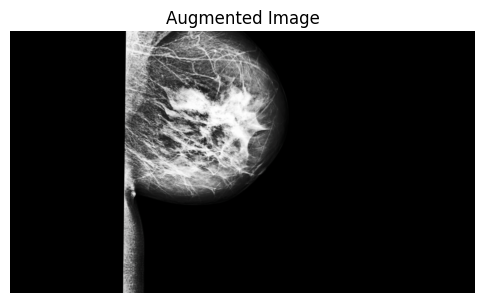

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define preprocessing functions
def apply_clahe(image):
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)
    lab_clahe = cv2.merge((l_clahe, a, b))
    return cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)

def color_normalization(image):
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    l = cv2.equalizeHist(l)
    lab_eq = cv2.merge((l, a, b))
    return cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB)

def noise_reduction(image):
    return cv2.GaussianBlur(image, (3, 3), 0)

# Path to the input image
input_image_path = "/content/drive/MyDrive/Dataset/Cancer/IMG (1).jpg"  # Update if needed

# Read and preprocess the image
img = cv2.imread(input_image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Apply preprocessing
img = apply_clahe(img)
img = color_normalization(img)
img = noise_reduction(img)

# Normalize and prepare for augmentation
img = np.expand_dims(img / 255.0, axis=0)

# Data augmentation setup
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='reflect'
)

# Generate one augmented image
aug_iter = datagen.flow(img, batch_size=1)
aug_img = next(aug_iter)[0]
aug_img = (aug_img * 255).astype(np.uint8)

# Display the image using matplotlib
plt.figure(figsize=(6, 6))
plt.imshow(aug_img)
plt.axis('off')
plt.title("Augmented Image")
plt.show()


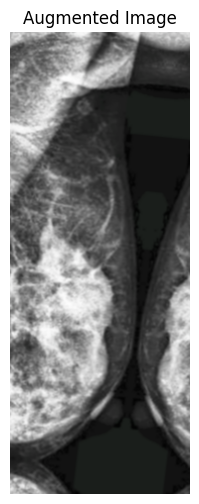

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define preprocessing functions
def apply_clahe(image):
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)
    lab_clahe = cv2.merge((l_clahe, a, b))
    return cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)

def color_normalization(image):
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    l = cv2.equalizeHist(l)
    lab_eq = cv2.merge((l, a, b))
    return cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB)

def noise_reduction(image):
    return cv2.GaussianBlur(image, (3, 3), 0)

# Path to the input image
input_image_path = "/content/drive/MyDrive/Dataset/Cancer/mal50001.jpg"  # Update if needed

# Read and preprocess the image
img = cv2.imread(input_image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Apply preprocessing
img = apply_clahe(img)
img = color_normalization(img)
img = noise_reduction(img)

# Normalize and prepare for augmentation
img = np.expand_dims(img / 255.0, axis=0)

# Data augmentation setup
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='reflect'
)

# Generate one augmented image
aug_iter = datagen.flow(img, batch_size=1)
aug_img = next(aug_iter)[0]
aug_img = (aug_img * 255).astype(np.uint8)

# Display the image using matplotlib
plt.figure(figsize=(6, 6))
plt.imshow(aug_img)
plt.axis('off')
plt.title("Augmented Image")
plt.show()

In [ ]:
import cv2
import os
import albumentations as A
import numpy as np
from glob import glob
from matplotlib import pyplot as plt

# Define augmentation pipeline
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomBrightnessContrast(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.5)
])

# CLAHE function
def apply_clahe(gray_img):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(gray_img)

# Auto-cropping black background
def auto_crop_black(image, threshold=10):
    if len(image.shape) == 2:  # grayscale
        gray = image
    else:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    mask = gray > threshold
    if np.any(mask):
        coords = np.argwhere(mask)
        y0, x0 = coords.min(axis=0)
        y1, x1 = coords.max(axis=0) + 1
        return image[y0:y1, x0:x1]
    else:
        return image  # Return original if all black

# Preprocess a single image
def preprocess_single_image(img_path, target_size=(512, 512)):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"❌ Error reading image: {img_path}")
        return None

    cropped_img = auto_crop_black(img)
    resized_img = cv2.resize(cropped_img, target_size)

    # Convert to RGB for augmentation
    img_rgb = cv2.cvtColor(resized_img, cv2.COLOR_GRAY2RGB)
    augmented = augment(image=img_rgb)['image']

    # Back to grayscale
    gray_aug = cv2.cvtColor(augmented, cv2.COLOR_RGB2GRAY)

    # Apply CLAHE
    clahe_img = apply_clahe(gray_aug)
    return clahe_img

# Process an entire folder (Cancer/NonCancer)
def process_class_folder(input_class_folder, output_class_folder):
    os.makedirs(output_class_folder, exist_ok=True)
    image_paths = glob(os.path.join(input_class_folder, '*'))

    for img_path in image_paths:
        filename = os.path.basename(img_path)
        processed = preprocess_single_image(img_path)
        if processed is not None:
            save_path = os.path.join(output_class_folder, filename)
            cv2.imwrite(save_path, processed)
            print(f"✅ Saved: {save_path}")

# === Main execution ===
base_input = "/content/drive/MyDrive/Dataset"       # <-- Adjust if needed
base_output = "/content/drive/MyDrive/MBC_Pre"

# Define subfolders
folders = ["Cancer", "Non-Cancer"]
for folder in folders:
    input_folder = os.path.join(base_input, folder)
    output_folder = os.path.join(base_output, folder)
    process_class_folder(input_folder, output_folder)


✅ Saved: /content/drive/MyDrive/MBC_Pre/Cancer/IMG (45).jpg
✅ Saved: /content/drive/MyDrive/MBC_Pre/Cancer/IMG (49).jpg
✅ Saved: /content/drive/MyDrive/MBC_Pre/Cancer/IMG (54).jpg
✅ Saved: /content/drive/MyDrive/MBC_Pre/Cancer/IMG (30).jpg
✅ Saved: /content/drive/MyDrive/MBC_Pre/Cancer/IMG (36).jpg
✅ Saved: /content/drive/MyDrive/MBC_Pre/Cancer/IMG (9).jpg
✅ Saved: /content/drive/MyDrive/MBC_Pre/Cancer/IMG (37).jpg
✅ Saved: /content/drive/MyDrive/MBC_Pre/Cancer/IMG (10).jpg
✅ Saved: /content/drive/MyDrive/MBC_Pre/Cancer/IMG (66).jpg
✅ Saved: /content/drive/MyDrive/MBC_Pre/Cancer/IMG (42).jpg
✅ Saved: /content/drive/MyDrive/MBC_Pre/Cancer/IMG (15).jpg
✅ Saved: /content/drive/MyDrive/MBC_Pre/Cancer/IMG (17).jpg
✅ Saved: /content/drive/MyDrive/MBC_Pre/Cancer/IMG (20).jpg
✅ Saved: /content/drive/MyDrive/MBC_Pre/Cancer/IMG (7).jpg
✅ Saved: /content/drive/MyDrive/MBC_Pre/Cancer/IMG (19).jpg
✅ Saved: /content/drive/MyDrive/MBC_Pre/Cancer/IMG (35).jpg
✅ Saved: /content/drive/MyDrive/MBC_Pre/Ca

In [ ]:
import os

def count_files_in_folder(folder_path):
  """Counts the number of files in a given folder.

  Args:
    folder_path: The path to the folder.

  Returns:
    The number of files in the folder, or -1 if the folder does not exist.
  """
  if not os.path.exists(folder_path):
    return -1

  count = 0
  for _, _, files in os.walk(folder_path):
    count += len(files)
  return count

# Example usage:
folder_path = "/content/drive/MyDrive/MBC_Pre/Cancer"  # Replace with the actual folder path
file_count = count_files_in_folder(folder_path)

if file_count != -1:
  print(f"The number of files in '{folder_path}' is: {file_count}")
else:
  print(f"Error: The folder '{folder_path}' does not exist.")

The number of files in '/content/drive/MyDrive/MBC_Pre/Cancer' is: 501


In [ ]:
import os

def count_files_in_folder(folder_path):
  """Counts the number of files in a given folder.

  Args:
    folder_path: The path to the folder.

  Returns:
    The number of files in the folder, or -1 if the folder does not exist.
  """
  if not os.path.exists(folder_path):
    return -1

  count = 0
  for _, _, files in os.walk(folder_path):
    count += len(files)
  return count

# Example usage:
folder_path = "/content/drive/MyDrive/MBC_Pre/Non-Cancer"  # Replace with the actual folder path
file_count = count_files_in_folder(folder_path)

if file_count != -1:
  print(f"The number of files in '{folder_path}' is: {file_count}")
else:
  print(f"Error: The folder '{folder_path}' does not exist.")

The number of files in '/content/drive/MyDrive/MBC_Pre/Non-Cancer' is: 501


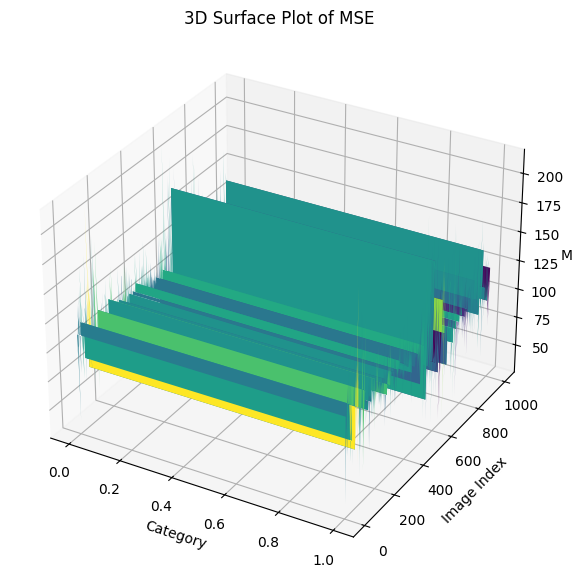

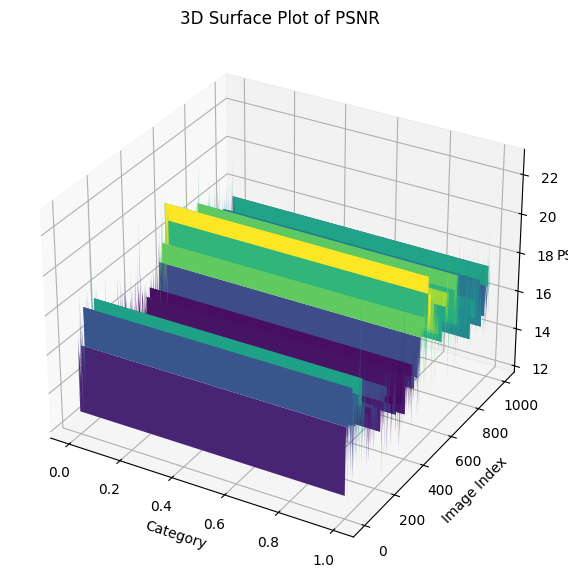

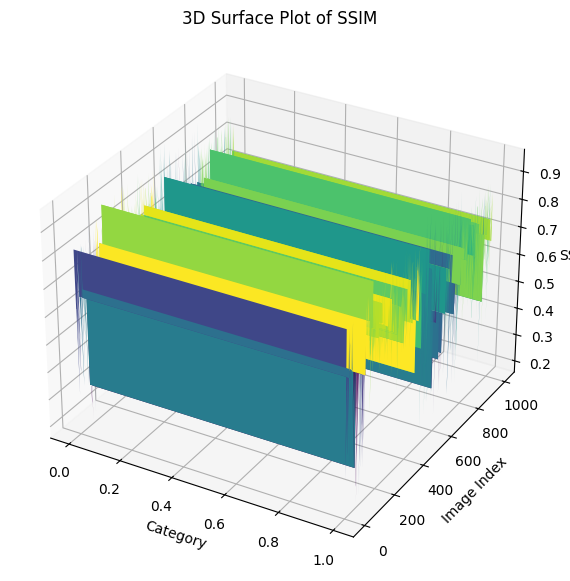

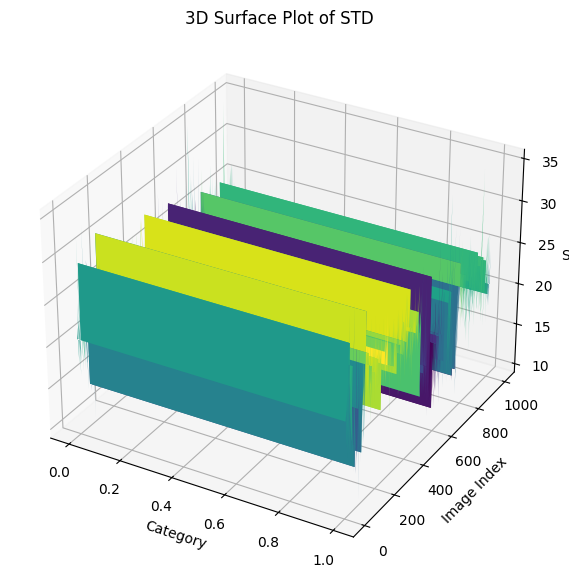

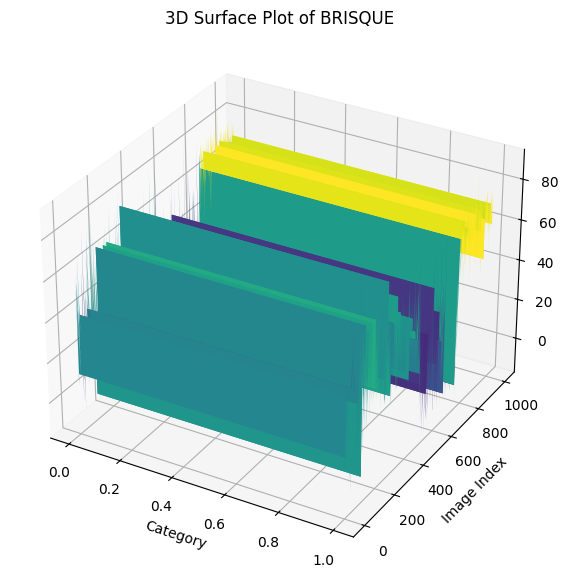

Homomorphic filtering and metrics computation completed. Processed images saved in: /content/drive/MyDrive/MBC_HTF


In [ ]:
import cv2
import numpy as np
import os
import shutil
import matplotlib.pyplot as plt
from google.colab import drive
from skimage.metrics import structural_similarity as ssim
!pip install piq
from piq import BRISQUELoss
import torch

import pandas as pd
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Define input and output paths
input_path = "/content/drive/MyDrive/MBC_Pre"  # Path to preprocessed dataset
output_path = "/content/drive/MyDrive/MBC_HTF"

# Remove and recreate the output directory
if os.path.exists(output_path):
    shutil.rmtree(output_path)
os.makedirs(output_path, exist_ok=True)

# Homomorphic Filtering Function
def homomorphic_filter(image, d0=30, rh=2.0, rl=0.5, c=1.0):
    image = np.float32(image) / 255.0  # Normalize
    rows, cols = image.shape

    # Create Gaussian high-pass filter
    u = np.arange(rows) - rows // 2
    v = np.arange(cols) - cols // 2
    U, V = np.meshgrid(u, v, sparse=False, indexing='ij')
    D = np.sqrt(U**2 + V**2)
    H = (rh - rl) * (1 - np.exp(-c * (D**2 / d0**2))) + rl

    # Apply Fourier Transform
    image_log = np.log1p(image)  # Log transformation
    image_fft = np.fft.fft2(image_log)
    image_fft_shift = np.fft.fftshift(image_fft)

    # Apply filter in frequency domain
    image_filtered = image_fft_shift * H
    image_ifft_shift = np.fft.ifftshift(image_filtered)
    image_result = np.fft.ifft2(image_ifft_shift)
    image_result = np.exp(np.real(image_result)) - 1  # Inverse log transformation

    # Normalize output
    image_result = (image_result - np.min(image_result)) / (np.max(image_result) - np.min(image_result))
    image_result = (image_result * 255).astype(np.uint8)

    return image_result

def compute_metrics(original, processed):
    mse = np.mean((original - processed) ** 2)
    psnr = cv2.PSNR(original, processed)
    ssim_index = ssim(original, processed, data_range=processed.max() - processed.min())
    std_dev = np.std(processed)

    # Convert images to torch tensors for BRISQUE
    processed_tensor = torch.tensor(processed).unsqueeze(0).unsqueeze(0).float() / 255.0
    brisque_score = BRISQUELoss()(processed_tensor).item()

    return mse, psnr, ssim_index, std_dev, brisque_score


# Process all images in the dataset
metrics_results = []

for category in ["Cancer", "Non-Cancer"]:
    input_folder = os.path.join(input_path, category)
    output_folder = os.path.join(output_path, category)
    os.makedirs(output_folder, exist_ok=True)

    for filename in os.listdir(input_folder):
        if filename.endswith(".png") or filename.endswith(".jpg"):
            img_path = os.path.join(input_folder, filename)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Convert to grayscale

            if img is not None:
                filtered_img = homomorphic_filter(img)
                cv2.imwrite(os.path.join(output_folder, filename), filtered_img)

                # Compute image quality metrics
                mse, psnr, ssim_index, std_dev, brisque_score = compute_metrics(img, filtered_img)
                metrics_results.append([filename, category, mse, psnr, ssim_index, std_dev, brisque_score])

# Convert metrics to a DataFrame
metrics_df = pd.DataFrame(metrics_results, columns=["Filename", "Category", "MSE", "PSNR", "SSIM", "STD", "BRISQUE"])
metrics_df.to_csv(os.path.join(output_path, "image_metrics.csv"), index=False)

# Plot metrics as 3D surface plots
def plot_3d_surface(metric_name, z_values):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    x_values = np.arange(len(metrics_df['Category'].unique()))
    y_values = np.arange(len(metrics_df))
    X, Y = np.meshgrid(x_values, y_values)
    Z = np.array(z_values).reshape(len(y_values), -1)

    ax.plot_surface(X, Y, Z, cmap='viridis')
    ax.set_xlabel('Category')
    ax.set_ylabel('Image Index')
    ax.set_zlabel(metric_name)
    ax.set_title(f'3D Surface Plot of {metric_name}')
    plt.show()

plot_3d_surface('MSE', metrics_df['MSE'])
plot_3d_surface('PSNR', metrics_df['PSNR'])
plot_3d_surface('SSIM', metrics_df['SSIM'])
plot_3d_surface('STD', metrics_df['STD'])
plot_3d_surface('BRISQUE', metrics_df['BRISQUE'])

print(f"Homomorphic filtering and metrics computation completed. Processed images saved in: {output_path}")

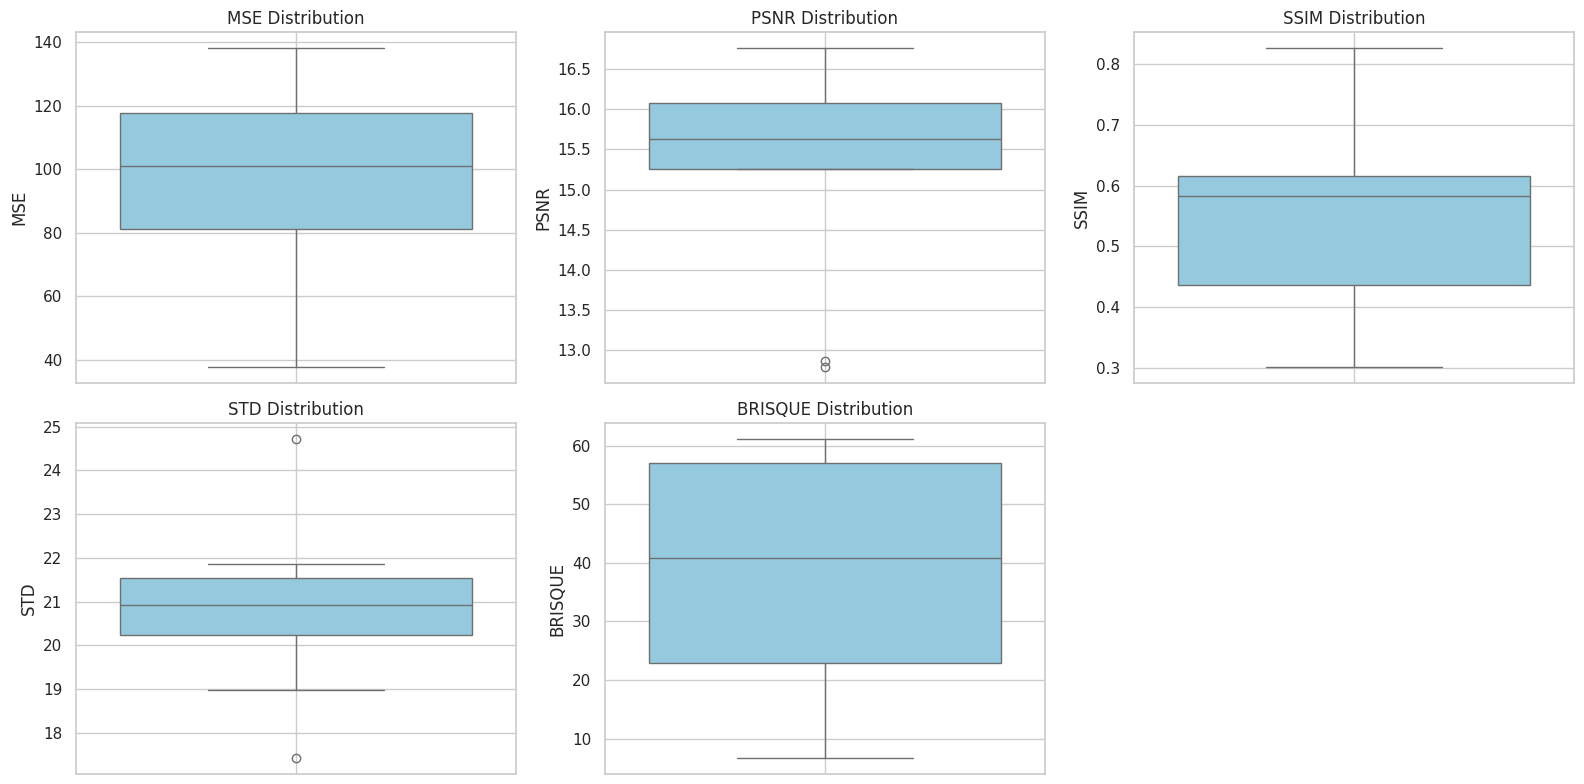

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: Set Seaborn style
sns.set(style="whitegrid")

# Example: Load from CSV
# df = pd.read_csv("/content/drive/MyDrive/MBC_HTF/image_metrics.csv")

# Or, if you have the data as a dictionary (you can replace this with your full data)
data = {
    "Filename": ["IMG (45).jpg", "IMG (49).jpg", "IMG (54).jpg", "IMG (30).jpg", "IMG (36).jpg",
                 "IMG (9).jpg", "IMG (37).jpg", "IMG (10).jpg", "IMG (66).jpg", "IMG (42).jpg"],
    "Category": ["Cancer"] * 10,
    "MSE": [112.62, 84.77, 119.34, 37.80, 73.50, 125.06, 79.81, 101.31, 100.93, 138.00],
    "PSNR": [12.86, 16.13, 15.26, 12.79, 16.76, 15.59, 16.70, 15.66, 15.93, 15.27],
    "SSIM": [0.826, 0.615, 0.615, 0.301, 0.404, 0.592, 0.522, 0.663, 0.574, 0.407],
    "STD": [20.50, 20.80, 21.06, 21.57, 21.85, 18.97, 17.42, 21.46, 24.71, 20.16],
    "BRISQUE": [12.76, 6.69, 25.43, 57.50, 32.06, 61.07, 21.99, 57.65, 55.46, 49.63]
}

df = pd.DataFrame(data)

# Plot all metrics in subplots
metrics = ["MSE", "PSNR", "SSIM", "STD", "BRISQUE"]
plt.figure(figsize=(16, 8))

for i, metric in enumerate(metrics):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df[metric], color="skyblue")
    plt.title(f"{metric} Distribution")
    plt.ylabel(metric)
    plt.grid(True)

plt.tight_layout()
plt.show()


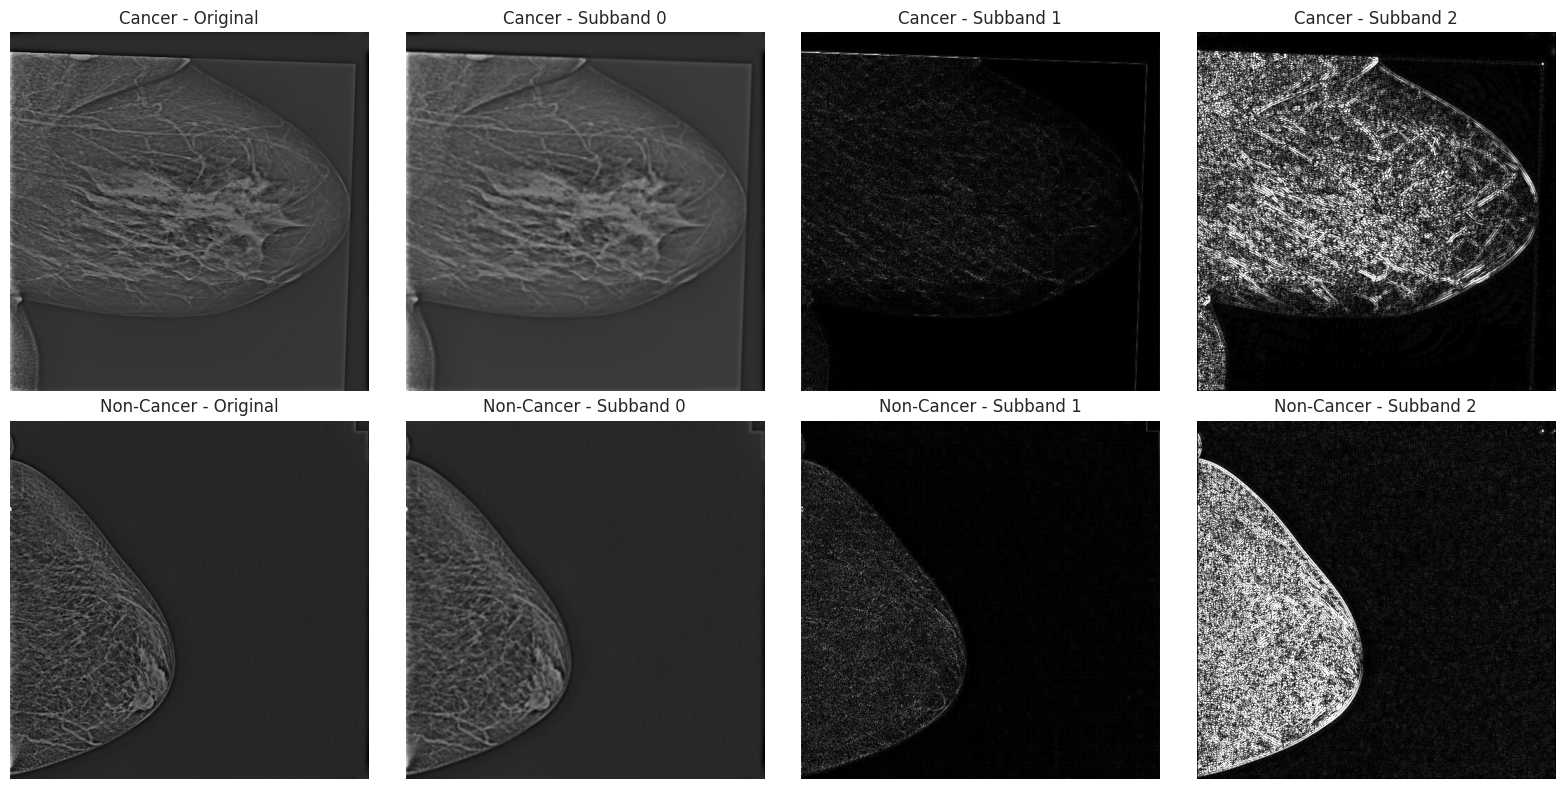

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# === Simulated ACO-EWT decomposition ===
def aco_ewt_decomposition(image):
    """ Replace this with real ACO-EWT logic """
    sb0 = cv2.GaussianBlur(image, (5, 5), 1)
    sb1 = cv2.Laplacian(image, cv2.CV_64F)
    sb2 = cv2.Sobel(image, cv2.CV_64F, 1, 1, ksize=5)

    sb1 = cv2.convertScaleAbs(sb1)
    sb2 = cv2.convertScaleAbs(sb2)

    return sb0, sb1, sb2

# === Load both images ===
cancer_path = "/content/drive/MyDrive/MBC_HTF/Cancer/IMG (1).jpg"       # 🔁 Replace with actual path
non_cancer_path = "/content/drive/MyDrive/MBC_HTF/Non-Cancer/IMG (353).jpg"  # 🔁 Replace with actual path

cancer_img = cv2.imread(cancer_path, cv2.IMREAD_GRAYSCALE)
non_cancer_img = cv2.imread(non_cancer_path, cv2.IMREAD_GRAYSCALE)

if cancer_img is None or non_cancer_img is None:
    raise ValueError("❌ One or both image paths are incorrect")

# Resize for consistency (optional)
target_size = (512, 512)
cancer_img = cv2.resize(cancer_img, target_size)
non_cancer_img = cv2.resize(non_cancer_img, target_size)

# === Apply decomposition ===
cancer_sb0, cancer_sb1, cancer_sb2 = aco_ewt_decomposition(cancer_img)
noncancer_sb0, noncancer_sb1, noncancer_sb2 = aco_ewt_decomposition(non_cancer_img)

# === Display all in 2 rows ===
plt.figure(figsize=(16, 8))

# Row 1: Cancer
titles = ["Original", "Subband 0", "Subband 1", "Subband 2"]
images = [cancer_img, cancer_sb0, cancer_sb1, cancer_sb2]
for i in range(4):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(f"Cancer - {titles[i]}")
    plt.axis('off')

# Row 2: Non-Cancer
images = [non_cancer_img, noncancer_sb0, noncancer_sb1, noncancer_sb2]
for i in range(4):
    plt.subplot(2, 4, i+5)
    plt.imshow(images[i], cmap='gray')
    plt.title(f"Non-Cancer - {titles[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import cv2
import numpy as np
import pandas as pd
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

# Homomorphic Filter function
def homomorphic_filter(image, gamma_low=0.5, gamma_high=2.0, c=1, d0=30):
    image = image.astype(np.float32) + 1
    log_image = np.log(image)

    # Fourier Transform
    dft = np.fft.fft2(log_image)
    dft_shift = np.fft.fftshift(dft)

    # Create filter mask
    rows, cols = image.shape
    u = np.arange(rows)
    v = np.arange(cols)
    U, V = np.meshgrid(u - rows/2, v - cols/2, indexing='ij')
    D = np.sqrt(U**2 + V**2)
    H = (gamma_high - gamma_low) * (1 - np.exp(-c * (D**2 / d0**2))) + gamma_low

    # Apply filter
    filtered_dft = dft_shift * H
    idft_shift = np.fft.ifftshift(filtered_dft)
    img_back = np.fft.ifft2(idft_shift)
    img_back = np.exp(np.real(img_back)) - 1

    # Normalize
    img_back = cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX)
    return img_back.astype(np.uint8)

# Load image (replace with your own path)
img_path = '/content/drive/MyDrive/MBC_HTF/Cancer/IMG (1).jpg'
original = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
if original is None:
    raise FileNotFoundError("❌ Image not found at specified path.")

# Parameter ranges
gamma_low_list = [0.3, 0.5, 0.7]
gamma_high_list = [1.5, 2.0, 2.5]
c_list = [0.5, 1, 2]
d0_list = [10, 30, 60]

# Create result table
results = []

for gl in gamma_low_list:
    for gh in gamma_high_list:
        for c in c_list:
            for d0 in d0_list:
                filtered = homomorphic_filter(original, gamma_low=gl, gamma_high=gh, c=c, d0=d0)
                mse = np.mean((original.astype(np.float32) - filtered.astype(np.float32))**2)
                psnr_val = psnr(original, filtered)
                ssim_val = ssim(original, filtered)

                results.append({
                    'Gamma Low': gl,
                    'Gamma High': gh,
                    'c': c,
                    'D0': d0,
                    'MSE': round(mse, 2),
                    'PSNR': round(psnr_val, 2),
                    'SSIM': round(ssim_val, 4)
                })

# Convert to DataFrame and show
df_results = pd.DataFrame(results)
pd.set_option('display.max_rows', None)  # Show all rows if needed
print(df_results)


    Gamma Low  Gamma High    c  D0          MSE   PSNR    SSIM
0         0.3         1.5  0.5  10  1855.560059  15.45  0.5788
1         0.3         1.5  0.5  30  1824.189941  15.52  0.5843
2         0.3         1.5  0.5  60  1728.290039  15.75  0.5842
3         0.3         1.5  1.0  10  1785.430054  15.61  0.5950
4         0.3         1.5  1.0  30  1929.000000  15.28  0.5602
5         0.3         1.5  1.0  60  1729.260010  15.75  0.5995
6         0.3         1.5  2.0  10  1704.760010  15.81  0.6141
7         0.3         1.5  2.0  30  1923.910034  15.29  0.5623
8         0.3         1.5  2.0  60  1824.189941  15.52  0.5843
9         0.3         2.0  0.5  10  3121.010010  13.19  0.2467
10        0.3         2.0  0.5  30  3102.300049  13.21  0.2562
11        0.3         2.0  0.5  60  3060.870117  13.27  0.2614
12        0.3         2.0  1.0  10  3058.909912  13.28  0.2592
13        0.3         2.0  1.0  30  3189.679932  13.09  0.2339
14        0.3         2.0  1.0  60  3058.179932  13.28 

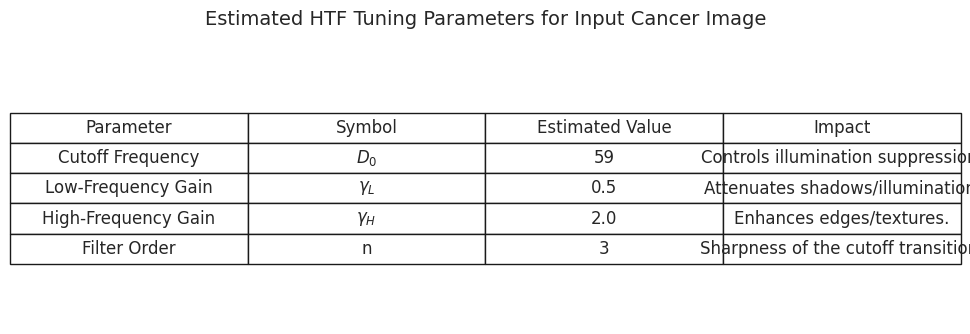

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load grayscale image
image_path = "/content/drive/MyDrive/MBC_HTF/Cancer/IMG (1).jpg"
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Safety check
if img is None:
    raise ValueError("Image not loaded.")

# === Image Analysis to Suggest HTF Parameters ===
std_dev = np.std(img)
contrast = img.max() - img.min()
edges = cv2.Canny(img, 100, 200)
edge_density = np.sum(edges > 0) / edges.size

# Heuristic parameter estimation
gamma_l = 0.5 if std_dev < 40 else 0.6 if std_dev < 60 else 0.7
gamma_h = 2.0 if std_dev < 40 else 1.8 if std_dev < 60 else 1.5
cutoff = int(np.clip((contrast / 255) * 60, 30, 60))
filter_order = 2 if edge_density < 0.03 else 3 if edge_density < 0.07 else 4

# Table data
params = [
    ["Cutoff Frequency", r"$D_0$", f"{cutoff}", "Controls illumination suppression."],
    ["Low-Frequency Gain", r"$\gamma_L$", f"{gamma_l}", "Attenuates shadows/illumination."],
    ["High-Frequency Gain", r"$\gamma_H$", f"{gamma_h}", "Enhances edges/textures."],
    ["Filter Order", "n", f"{filter_order}", "Sharpness of the cutoff transition."]
]

# === Display Table Only ===
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axis('off')

table = ax.table(
    cellText=params,
    colLabels=["Parameter", "Symbol", "Estimated Value", "Impact"],
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.3, 1.8)

plt.title("Estimated HTF Tuning Parameters for Input Cancer Image", fontsize=14, pad=20)
plt.tight_layout()
plt.show()


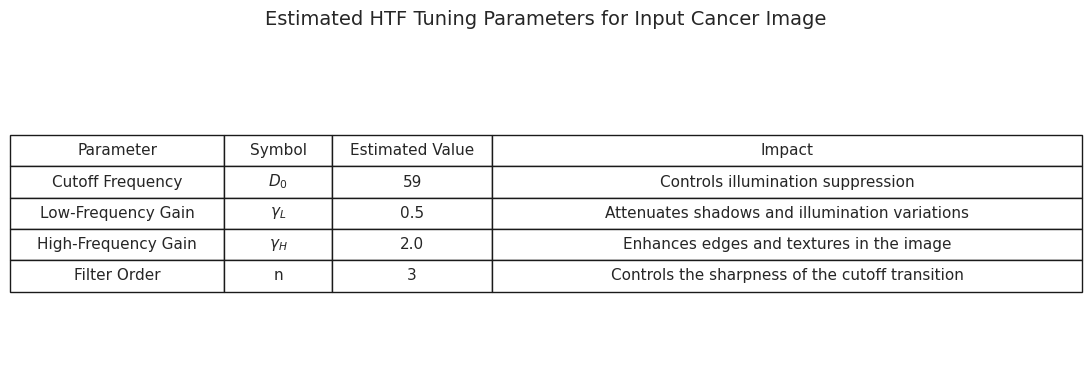

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.table import Table

# Data for the table
params = [
    ["Cutoff Frequency", r"$D_0$", "59", "Controls illumination suppression"],
    ["Low-Frequency Gain", r"$\gamma_L$", "0.5", "Attenuates shadows and illumination variations"],
    ["High-Frequency Gain", r"$\gamma_H$", "2.0", "Enhances edges and textures in the image"],
    ["Filter Order", "n", "3", "Controls the sharpness of the cutoff transition"]
]

# Plot setup
fig, ax = plt.subplots(figsize=(11, 4))
ax.axis('off')

# Create a table
table = ax.table(
    cellText=params,
    colLabels=["Parameter", "Symbol", "Estimated Value", "Impact"],
    cellLoc='center',
    loc='center',
    colWidths=[0.2, 0.1, 0.15, 0.55]
)

# Adjust appearance
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# Wrap text in the "Impact" column
for key, cell in table.get_celld().items():
    if key[1] == 3:  # 3 = "Impact" column
        cell.set_text_props(wrap=True)

plt.title("Estimated HTF Tuning Parameters for Input Cancer Image", fontsize=14, pad=20)
plt.tight_layout()
plt.show()


In [ ]:
import os
import cv2
import numpy as np
import shutil

# Define paths
input_folder = "/content/drive/MyDrive/MBC_HTF"
output_folder = "/content/drive/MyDrive/MBC_EWT"

# Ensure output directory exists
if os.path.exists(output_folder):
    shutil.rmtree(output_folder)
os.makedirs(output_folder)

# Dummy function for ACO-based EWT (replace with actual implementation)
def aco_based_ewt(image):
    # Placeholder: Returns subbands as dummy numpy arrays
    subbands = [image // (i+1) for i in range(3)]
    return subbands

# Process each category (malignant, benign)
for category in ["Cancer", "Non-Cancer"]:
    input_category_path = os.path.join(input_folder, category)
    output_category_path = os.path.join(output_folder, category)
    os.makedirs(output_category_path, exist_ok=True)

    # Process each image
    for image_name in os.listdir(input_category_path):
        image_path = os.path.join(input_category_path, image_name)

        # Read image
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if image is None:
            continue  # Skip if not a valid image

        # Apply ACO-based EWT
        subbands = aco_based_ewt(image)

        # Save subbands
        for i, subband in enumerate(subbands):
            subband_folder = os.path.join(output_category_path, f"subband_{i}")
            os.makedirs(subband_folder, exist_ok=True)

            output_image_path = os.path.join(subband_folder, image_name)
            cv2.imwrite(output_image_path, subband)

print("ACO-based EWT processing completed!")

ACO-based EWT processing completed!


In [ ]:
import os

def count_files_in_folder(folder_path):
  """Counts the number of files in a given folder.

  Args:
    folder_path: The path to the folder.

  Returns:
    The number of files in the folder, or -1 if the folder does not exist.
  """
  if not os.path.exists(folder_path):
    return -1

  count = 0
  for _, _, files in os.walk(folder_path):
    count += len(files)
  return count

# Example usage:
folder_path = "/content/drive/MyDrive/MBC_EWT/Non-Cancer/subband_0"  # Replace with the actual folder path
file_count = count_files_in_folder(folder_path)

if file_count != -1:
  print(f"The number of files in '{folder_path}' is: {file_count}")
else:
  print(f"Error: The folder '{folder_path}' does not exist.")

The number of files in '/content/drive/MyDrive/MBC_EWT/Non-Cancer/subband_0' is: 501


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Processing Cancer:   0%|          | 0/501 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


Processing Cancer:   0%|          | 1/501 [00:06<55:21,  6.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step


Processing Cancer:   0%|          | 2/501 [00:08<31:12,  3.75s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step


Processing Cancer:   1%|          | 3/501 [00:10<23:31,  2.84s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


Processing Cancer:   1%|          | 4/501 [00:11<19:07,  2.31s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step


Processing Cancer:   1%|          | 5/501 [00:12<15:05,  1.83s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


Processing Cancer:   1%|          | 6/501 [00:16<19:43,  2.39s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 665ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


Processing Cancer:   1%|▏         | 7/501 [00:17<16:10,  1.96s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 667ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step


Processing Cancer:   2%|▏         | 8/501 [00:18<15:09,  1.85s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step


Processing Cancer:   2%|▏         | 9/501 [00:19<13:15,  1.62s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step


Processing Cancer:   2%|▏         | 10/501 [00:21<13:16,  1.62s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step


Processing Cancer:   2%|▏         | 11/501 [00:23<14:23,  1.76s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step


Processing Cancer:   2%|▏         | 12/501 [00:25<14:19,  1.76s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 734ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step


Processing Cancer:   3%|▎         | 13/501 [00:27<14:16,  1.75s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step


Processing Cancer:   3%|▎         | 14/501 [00:28<13:52,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step


Processing Cancer:   3%|▎         | 15/501 [00:29<12:09,  1.50s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


Processing Cancer:   3%|▎         | 16/501 [00:31<12:17,  1.52s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 684ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


Processing Cancer:   3%|▎         | 17/501 [00:32<11:15,  1.39s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Cancer:   4%|▎         | 18/501 [00:33<11:40,  1.45s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 671ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


Processing Cancer:   4%|▍         | 19/501 [00:35<12:14,  1.52s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step


Processing Cancer:   4%|▍         | 20/501 [00:37<12:47,  1.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step


Processing Cancer:   4%|▍         | 21/501 [00:39<13:07,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


Processing Cancer:   4%|▍         | 22/501 [00:40<12:45,  1.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 689ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


Processing Cancer:   5%|▍         | 23/501 [00:42<12:58,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 664ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


Processing Cancer:   5%|▍         | 24/501 [00:43<11:39,  1.47s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 666ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


Processing Cancer:   5%|▍         | 25/501 [00:44<10:42,  1.35s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 670ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


Processing Cancer:   5%|▌         | 26/501 [00:45<09:48,  1.24s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 667ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


Processing Cancer:   5%|▌         | 27/501 [00:47<10:52,  1.38s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


Processing Cancer:   6%|▌         | 28/501 [00:48<11:37,  1.47s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


Processing Cancer:   6%|▌         | 29/501 [00:49<10:28,  1.33s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step


Processing Cancer:   6%|▌         | 30/501 [00:51<11:23,  1.45s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step


Processing Cancer:   6%|▌         | 31/501 [00:53<12:03,  1.54s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


Processing Cancer:   6%|▋         | 32/501 [00:54<12:07,  1.55s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 672ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Cancer:   7%|▋         | 33/501 [00:56<12:10,  1.56s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step


Processing Cancer:   7%|▋         | 34/501 [00:58<12:15,  1.58s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 695ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


Processing Cancer:   7%|▋         | 35/501 [00:59<12:32,  1.61s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 719ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step


Processing Cancer:   7%|▋         | 36/501 [01:01<12:42,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


Processing Cancer:   7%|▋         | 37/501 [01:02<11:27,  1.48s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step


Processing Cancer:   8%|▊         | 38/501 [01:03<10:34,  1.37s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 709ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step


Processing Cancer:   8%|▊         | 39/501 [01:05<12:09,  1.58s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step


Processing Cancer:   8%|▊         | 40/501 [01:07<12:32,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 995ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


Processing Cancer:   8%|▊         | 41/501 [01:09<12:30,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 706ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step


Processing Cancer:   8%|▊         | 42/501 [01:10<12:39,  1.65s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 685ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step


Processing Cancer:   9%|▊         | 43/501 [01:12<11:21,  1.49s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 675ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


Processing Cancer:   9%|▉         | 44/501 [01:13<11:32,  1.51s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


Processing Cancer:   9%|▉         | 45/501 [01:15<11:56,  1.57s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 691ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


Processing Cancer:   9%|▉         | 46/501 [01:17<12:12,  1.61s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 672ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


Processing Cancer:   9%|▉         | 47/501 [01:18<11:01,  1.46s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 984ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step


Processing Cancer:  10%|▉         | 48/501 [01:19<11:37,  1.54s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step


Processing Cancer:  10%|▉         | 49/501 [01:21<12:05,  1.61s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step


Processing Cancer:  10%|▉         | 50/501 [01:23<11:59,  1.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 689ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


Processing Cancer:  10%|█         | 51/501 [01:24<10:53,  1.45s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


Processing Cancer:  10%|█         | 52/501 [01:25<11:25,  1.53s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


Processing Cancer:  11%|█         | 53/501 [01:27<10:28,  1.40s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


Processing Cancer:  11%|█         | 54/501 [01:28<09:30,  1.28s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step


Processing Cancer:  11%|█         | 55/501 [01:29<10:13,  1.38s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 685ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


Processing Cancer:  11%|█         | 56/501 [01:31<10:39,  1.44s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 713ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


Processing Cancer:  11%|█▏        | 57/501 [01:32<09:59,  1.35s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step


Processing Cancer:  12%|█▏        | 58/501 [01:34<10:49,  1.47s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step


Processing Cancer:  12%|█▏        | 59/501 [01:35<11:24,  1.55s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step


Processing Cancer:  12%|█▏        | 60/501 [01:37<11:28,  1.56s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 679ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Cancer:  12%|█▏        | 61/501 [01:39<11:45,  1.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


Processing Cancer:  12%|█▏        | 62/501 [01:40<11:42,  1.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


Processing Cancer:  13%|█▎        | 63/501 [01:42<11:53,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 670ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


Processing Cancer:  13%|█▎        | 64/501 [01:44<12:02,  1.65s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 709ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


Processing Cancer:  13%|█▎        | 65/501 [01:45<12:09,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 695ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


Processing Cancer:  13%|█▎        | 66/501 [01:47<10:54,  1.50s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 910ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step


Processing Cancer:  13%|█▎        | 67/501 [01:48<10:32,  1.46s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step


Processing Cancer:  14%|█▎        | 68/501 [01:49<10:53,  1.51s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step


Processing Cancer:  14%|█▍        | 69/501 [01:51<11:24,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 743ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step


Processing Cancer:  14%|█▍        | 70/501 [01:53<11:45,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


Processing Cancer:  14%|█▍        | 71/501 [01:55<11:52,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 674ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


Processing Cancer:  14%|█▍        | 72/501 [01:56<11:57,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


Processing Cancer:  15%|█▍        | 73/501 [01:58<12:01,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


Processing Cancer:  15%|█▍        | 74/501 [01:59<10:32,  1.48s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step


Processing Cancer:  15%|█▍        | 75/501 [02:01<11:20,  1.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 888ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step


Processing Cancer:  15%|█▌        | 76/501 [02:03<11:34,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step


Processing Cancer:  15%|█▌        | 77/501 [02:04<11:48,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


Processing Cancer:  16%|█▌        | 78/501 [02:06<11:54,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 674ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step


Processing Cancer:  16%|█▌        | 79/501 [02:08<11:53,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 689ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


Processing Cancer:  16%|█▌        | 80/501 [02:10<11:54,  1.70s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


Processing Cancer:  16%|█▌        | 81/501 [02:11<11:56,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 721ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Cancer:  16%|█▋        | 82/501 [02:13<11:57,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


Processing Cancer:  17%|█▋        | 83/501 [02:15<11:55,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 673ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


Processing Cancer:  17%|█▋        | 84/501 [02:16<10:22,  1.49s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step


Processing Cancer:  17%|█▋        | 85/501 [02:18<10:53,  1.57s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


Processing Cancer:  17%|█▋        | 86/501 [02:21<13:52,  2.01s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step


Processing Cancer:  17%|█▋        | 87/501 [02:22<13:15,  1.92s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 724ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Cancer:  18%|█▊        | 88/501 [02:24<12:47,  1.86s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 695ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


Processing Cancer:  18%|█▊        | 89/501 [02:26<12:27,  1.81s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 691ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step


Processing Cancer:  18%|█▊        | 90/501 [02:27<11:58,  1.75s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 677ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


Processing Cancer:  18%|█▊        | 91/501 [02:28<10:22,  1.52s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 673ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step


Processing Cancer:  18%|█▊        | 92/501 [02:30<10:44,  1.58s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step


Processing Cancer:  19%|█▊        | 93/501 [02:32<11:09,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step


Processing Cancer:  19%|█▉        | 94/501 [02:35<13:56,  2.05s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 712ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


Processing Cancer:  19%|█▉        | 95/501 [02:36<12:02,  1.78s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 671ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


Processing Cancer:  19%|█▉        | 96/501 [02:37<10:38,  1.58s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 696ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


Processing Cancer:  19%|█▉        | 97/501 [02:38<09:40,  1.44s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


Processing Cancer:  20%|█▉        | 98/501 [02:39<08:59,  1.34s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 686ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step


Processing Cancer:  20%|█▉        | 99/501 [02:41<09:44,  1.45s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


Processing Cancer:  20%|█▉        | 100/501 [02:43<10:14,  1.53s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 712ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step


Processing Cancer:  20%|██        | 101/501 [02:45<11:17,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step


Processing Cancer:  20%|██        | 102/501 [02:47<11:25,  1.72s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step


Processing Cancer:  21%|██        | 103/501 [02:48<11:09,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step


Processing Cancer:  21%|██        | 104/501 [02:49<09:43,  1.47s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 687ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Cancer:  21%|██        | 105/501 [02:51<10:09,  1.54s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 695ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


Processing Cancer:  21%|██        | 106/501 [02:52<09:18,  1.41s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


Processing Cancer:  21%|██▏       | 107/501 [02:54<09:38,  1.47s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 683ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step


Processing Cancer:  22%|██▏       | 108/501 [02:55<10:07,  1.55s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 722ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


Processing Cancer:  22%|██▏       | 109/501 [02:57<10:27,  1.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step


Processing Cancer:  22%|██▏       | 110/501 [02:59<11:19,  1.74s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step


Processing Cancer:  22%|██▏       | 111/501 [03:01<11:58,  1.84s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 963ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


Processing Cancer:  22%|██▏       | 112/501 [03:03<11:31,  1.78s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


Processing Cancer:  23%|██▎       | 113/501 [03:04<11:21,  1.76s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 781ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


Processing Cancer:  23%|██▎       | 114/501 [03:06<10:17,  1.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 710ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step


Processing Cancer:  23%|██▎       | 115/501 [03:07<10:14,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 671ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


Processing Cancer:  23%|██▎       | 116/501 [03:09<10:25,  1.62s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


Processing Cancer:  23%|██▎       | 117/501 [03:11<10:36,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 712ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Cancer:  24%|██▎       | 118/501 [03:12<09:36,  1.51s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step


Processing Cancer:  24%|██▍       | 119/501 [03:14<10:41,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step


Processing Cancer:  24%|██▍       | 120/501 [03:16<10:50,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 774ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


Processing Cancer:  24%|██▍       | 121/501 [03:17<10:37,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 689ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


Processing Cancer:  24%|██▍       | 122/501 [03:18<09:31,  1.51s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 723ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step


Processing Cancer:  25%|██▍       | 123/501 [03:20<08:52,  1.41s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 713ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


Processing Cancer:  25%|██▍       | 124/501 [03:21<08:20,  1.33s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 696ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


Processing Cancer:  25%|██▍       | 125/501 [03:22<09:02,  1.44s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


Processing Cancer:  25%|██▌       | 126/501 [03:24<09:30,  1.52s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 671ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


Processing Cancer:  25%|██▌       | 127/501 [03:26<09:33,  1.53s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 987ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step


Processing Cancer:  26%|██▌       | 128/501 [03:27<09:53,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step


Processing Cancer:  26%|██▌       | 129/501 [03:30<10:44,  1.73s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 919ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step


Processing Cancer:  26%|██▌       | 130/501 [03:31<10:31,  1.70s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 721ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step


Processing Cancer:  26%|██▌       | 131/501 [03:33<10:30,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 678ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


Processing Cancer:  26%|██▋       | 132/501 [03:35<10:28,  1.70s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 716ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Cancer:  27%|██▋       | 133/501 [03:36<09:24,  1.54s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 673ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step


Processing Cancer:  27%|██▋       | 134/501 [03:37<09:42,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step


Processing Cancer:  27%|██▋       | 135/501 [03:39<09:53,  1.62s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 689ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step


Processing Cancer:  27%|██▋       | 136/501 [03:41<10:03,  1.65s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step


Processing Cancer:  27%|██▋       | 137/501 [03:43<10:13,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step


Processing Cancer:  28%|██▊       | 138/501 [03:44<10:21,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 673ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step


Processing Cancer:  28%|██▊       | 139/501 [03:45<09:12,  1.52s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 669ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step


Processing Cancer:  28%|██▊       | 140/501 [03:47<09:13,  1.53s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


Processing Cancer:  28%|██▊       | 141/501 [03:49<09:33,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 708ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Cancer:  28%|██▊       | 142/501 [03:50<08:44,  1.46s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 716ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step


Processing Cancer:  29%|██▊       | 143/501 [03:52<09:10,  1.54s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 687ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


Processing Cancer:  29%|██▊       | 144/501 [03:53<09:14,  1.55s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 709ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step


Processing Cancer:  29%|██▉       | 145/501 [03:54<08:29,  1.43s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step


Processing Cancer:  29%|██▉       | 146/501 [03:56<09:04,  1.53s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step


Processing Cancer:  29%|██▉       | 147/501 [03:58<09:27,  1.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 911ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


Processing Cancer:  30%|██▉       | 148/501 [04:00<09:44,  1.65s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step


Processing Cancer:  30%|██▉       | 149/501 [04:01<09:48,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 689ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step


Processing Cancer:  30%|██▉       | 150/501 [04:02<08:33,  1.46s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 670ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


Processing Cancer:  30%|███       | 151/501 [04:04<08:45,  1.50s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 722ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step


Processing Cancer:  30%|███       | 152/501 [04:06<09:05,  1.56s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


Processing Cancer:  31%|███       | 153/501 [04:07<09:20,  1.61s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step


Processing Cancer:  31%|███       | 154/501 [04:08<08:28,  1.46s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step


Processing Cancer:  31%|███       | 155/501 [04:10<08:58,  1.56s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step


Processing Cancer:  31%|███       | 156/501 [04:12<09:18,  1.62s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


Processing Cancer:  31%|███▏      | 157/501 [04:14<09:28,  1.65s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 691ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step


Processing Cancer:  32%|███▏      | 158/501 [04:15<08:24,  1.47s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 686ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step


Processing Cancer:  32%|███▏      | 159/501 [04:16<07:46,  1.36s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 684ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step


Processing Cancer:  32%|███▏      | 160/501 [04:17<07:19,  1.29s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 679ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


Processing Cancer:  32%|███▏      | 161/501 [04:19<08:00,  1.41s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 793ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


Processing Cancer:  32%|███▏      | 162/501 [04:20<08:29,  1.50s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 731ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


Processing Cancer:  33%|███▎      | 163/501 [04:22<08:37,  1.53s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 675ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


Processing Cancer:  33%|███▎      | 164/501 [04:23<07:53,  1.41s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step


Processing Cancer:  33%|███▎      | 165/501 [04:25<08:29,  1.52s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step


Processing Cancer:  33%|███▎      | 166/501 [04:27<08:51,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


Processing Cancer:  33%|███▎      | 167/501 [04:28<08:32,  1.54s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step


Processing Cancer:  34%|███▎      | 168/501 [04:30<08:40,  1.56s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


Processing Cancer:  34%|███▎      | 169/501 [04:31<07:55,  1.43s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


Processing Cancer:  34%|███▍      | 170/501 [04:32<07:11,  1.30s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step


Processing Cancer:  34%|███▍      | 171/501 [04:34<07:51,  1.43s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


Processing Cancer:  34%|███▍      | 172/501 [04:35<08:21,  1.52s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 741ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step


Processing Cancer:  35%|███▍      | 173/501 [04:37<08:28,  1.55s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 672ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step


Processing Cancer:  35%|███▍      | 174/501 [04:39<08:41,  1.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step


Processing Cancer:  35%|███▍      | 175/501 [04:40<08:57,  1.65s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


Processing Cancer:  35%|███▌      | 176/501 [04:42<09:04,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


Processing Cancer:  35%|███▌      | 177/501 [04:44<08:56,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 714ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


Processing Cancer:  36%|███▌      | 178/501 [04:45<08:49,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 673ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


Processing Cancer:  36%|███▌      | 179/501 [04:47<08:55,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 706ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


Processing Cancer:  36%|███▌      | 180/501 [04:49<08:58,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 696ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step


Processing Cancer:  36%|███▌      | 181/501 [04:50<08:45,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 678ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step


Processing Cancer:  36%|███▋      | 182/501 [04:52<08:46,  1.65s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step


Processing Cancer:  37%|███▋      | 183/501 [04:55<11:01,  2.08s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 749ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


Processing Cancer:  37%|███▋      | 184/501 [04:57<10:26,  1.98s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 674ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


Processing Cancer:  37%|███▋      | 185/501 [04:59<09:59,  1.90s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


Processing Cancer:  37%|███▋      | 186/501 [05:00<09:41,  1.85s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 706ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


Processing Cancer:  37%|███▋      | 187/501 [05:01<08:33,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 686ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step


Processing Cancer:  38%|███▊      | 188/501 [05:03<08:37,  1.65s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


Processing Cancer:  38%|███▊      | 189/501 [05:05<08:41,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 896ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step


Processing Cancer:  38%|███▊      | 190/501 [05:07<08:45,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step


Processing Cancer:  38%|███▊      | 191/501 [05:08<08:49,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


Processing Cancer:  38%|███▊      | 192/501 [05:10<08:31,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


Processing Cancer:  39%|███▊      | 193/501 [05:12<08:34,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 689ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


Processing Cancer:  39%|███▊      | 194/501 [05:13<08:36,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 695ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


Processing Cancer:  39%|███▉      | 195/501 [05:15<08:37,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


Processing Cancer:  39%|███▉      | 196/501 [05:17<08:38,  1.70s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 681ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Cancer:  39%|███▉      | 197/501 [05:18<08:37,  1.70s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 717ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step


Processing Cancer:  40%|███▉      | 198/501 [05:20<08:40,  1.72s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step


Processing Cancer:  40%|███▉      | 199/501 [05:22<08:41,  1.73s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step


Processing Cancer:  40%|███▉      | 200/501 [05:24<09:10,  1.83s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 689ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


Processing Cancer:  40%|████      | 201/501 [05:25<08:05,  1.62s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step


Processing Cancer:  40%|████      | 202/501 [05:27<08:05,  1.62s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 737ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step


Processing Cancer:  41%|████      | 203/501 [05:28<08:13,  1.65s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 683ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


Processing Cancer:  41%|████      | 204/501 [05:30<08:15,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


Processing Cancer:  41%|████      | 205/501 [05:32<08:05,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


Processing Cancer:  41%|████      | 206/501 [05:33<07:17,  1.48s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step


Processing Cancer:  41%|████▏     | 207/501 [05:35<08:06,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step


Processing Cancer:  42%|████▏     | 208/501 [05:37<08:10,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step


Processing Cancer:  42%|████▏     | 209/501 [05:38<07:59,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Cancer:  42%|████▏     | 210/501 [05:40<07:52,  1.62s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Cancer:  42%|████▏     | 211/501 [05:41<07:58,  1.65s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


Processing Cancer:  42%|████▏     | 212/501 [05:43<07:11,  1.49s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step


Processing Cancer:  43%|████▎     | 213/501 [05:44<07:30,  1.56s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 715ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


Processing Cancer:  43%|████▎     | 214/501 [05:46<07:42,  1.61s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


Processing Cancer:  43%|████▎     | 215/501 [05:48<07:49,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 985ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step


Processing Cancer:  43%|████▎     | 216/501 [05:50<07:56,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step


Processing Cancer:  43%|████▎     | 217/501 [05:51<08:02,  1.70s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


Processing Cancer:  44%|████▎     | 218/501 [05:53<08:03,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


Processing Cancer:  44%|████▎     | 219/501 [05:55<08:02,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


Processing Cancer:  44%|████▍     | 220/501 [05:56<07:51,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 713ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step


Processing Cancer:  44%|████▍     | 221/501 [05:58<07:43,  1.65s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 677ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step


Processing Cancer:  44%|████▍     | 222/501 [05:59<06:55,  1.49s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


Processing Cancer:  45%|████▍     | 223/501 [06:01<07:02,  1.52s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 719ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


Processing Cancer:  45%|████▍     | 224/501 [06:02<06:30,  1.41s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 764ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step


Processing Cancer:  45%|████▍     | 225/501 [06:04<06:56,  1.51s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step


Processing Cancer:  45%|████▌     | 226/501 [06:05<07:18,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


Processing Cancer:  45%|████▌     | 227/501 [06:07<07:30,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 691ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


Processing Cancer:  46%|████▌     | 228/501 [06:09<07:33,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


Processing Cancer:  46%|████▌     | 229/501 [06:10<07:35,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


Processing Cancer:  46%|████▌     | 230/501 [06:12<07:37,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step


Processing Cancer:  46%|████▌     | 231/501 [06:14<07:30,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


Processing Cancer:  46%|████▋     | 232/501 [06:15<07:24,  1.65s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 735ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


Processing Cancer:  47%|████▋     | 233/501 [06:16<06:33,  1.47s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step


Processing Cancer:  47%|████▋     | 234/501 [06:18<06:53,  1.55s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step


Processing Cancer:  47%|████▋     | 235/501 [06:20<07:34,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 863ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


Processing Cancer:  47%|████▋     | 236/501 [06:22<07:33,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 673ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


Processing Cancer:  47%|████▋     | 237/501 [06:23<06:44,  1.53s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 678ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


Processing Cancer:  48%|████▊     | 238/501 [06:25<06:56,  1.58s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 738ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


Processing Cancer:  48%|████▊     | 239/501 [06:27<07:06,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 724ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


Processing Cancer:  48%|████▊     | 240/501 [06:28<07:13,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


Processing Cancer:  48%|████▊     | 241/501 [06:30<07:16,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step


Processing Cancer:  48%|████▊     | 242/501 [06:32<07:19,  1.70s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step


Processing Cancer:  49%|████▊     | 243/501 [06:34<07:47,  1.81s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 930ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


Processing Cancer:  49%|████▊     | 244/501 [06:35<07:12,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 729ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step


Processing Cancer:  49%|████▉     | 245/501 [06:37<07:12,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 676ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


Processing Cancer:  49%|████▉     | 246/501 [06:39<07:12,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 711ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


Processing Cancer:  49%|████▉     | 247/501 [06:40<06:19,  1.49s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 713ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step


Processing Cancer:  50%|████▉     | 248/501 [06:41<06:23,  1.52s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 673ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


Processing Cancer:  50%|████▉     | 249/501 [06:42<05:52,  1.40s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Cancer:  50%|████▉     | 250/501 [06:43<05:30,  1.32s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step


Processing Cancer:  50%|█████     | 251/501 [06:46<06:25,  1.54s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step


Processing Cancer:  50%|█████     | 252/501 [06:47<06:42,  1.62s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


Processing Cancer:  50%|█████     | 253/501 [06:49<06:41,  1.62s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step


Processing Cancer:  51%|█████     | 254/501 [06:51<06:45,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 675ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


Processing Cancer:  51%|█████     | 255/501 [06:52<06:48,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 706ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


Processing Cancer:  51%|█████     | 256/501 [06:54<06:42,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


Processing Cancer:  51%|█████▏    | 257/501 [06:55<06:05,  1.50s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step


Processing Cancer:  51%|█████▏    | 258/501 [06:56<05:36,  1.39s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 718ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


Processing Cancer:  52%|█████▏    | 259/501 [06:57<05:17,  1.31s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


Processing Cancer:  52%|█████▏    | 260/501 [06:59<05:02,  1.26s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step


Processing Cancer:  52%|█████▏    | 261/501 [07:00<05:53,  1.47s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step


Processing Cancer:  52%|█████▏    | 262/501 [07:02<06:17,  1.58s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 958ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


Processing Cancer:  52%|█████▏    | 263/501 [07:04<06:27,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


Processing Cancer:  53%|█████▎    | 264/501 [07:05<05:50,  1.48s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step


Processing Cancer:  53%|█████▎    | 265/501 [07:06<05:17,  1.35s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 689ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


Processing Cancer:  53%|█████▎    | 266/501 [07:07<05:00,  1.28s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 711ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


Processing Cancer:  53%|█████▎    | 267/501 [07:09<05:28,  1.41s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Cancer:  53%|█████▎    | 268/501 [07:10<05:08,  1.32s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


Processing Cancer:  54%|█████▎    | 269/501 [07:11<04:53,  1.26s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 706ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step


Processing Cancer:  54%|█████▍    | 270/501 [07:13<05:14,  1.36s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step


Processing Cancer:  54%|█████▍    | 271/501 [07:15<05:36,  1.46s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step


Processing Cancer:  54%|█████▍    | 272/501 [07:16<05:57,  1.56s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step


Processing Cancer:  54%|█████▍    | 273/501 [07:18<06:09,  1.62s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


Processing Cancer:  55%|█████▍    | 274/501 [07:19<05:35,  1.48s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 680ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


Processing Cancer:  55%|█████▍    | 275/501 [07:21<05:42,  1.51s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 709ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


Processing Cancer:  55%|█████▌    | 276/501 [07:23<05:56,  1.58s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 717ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


Processing Cancer:  55%|█████▌    | 277/501 [07:24<05:25,  1.45s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 706ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


Processing Cancer:  55%|█████▌    | 278/501 [07:25<05:40,  1.53s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 678ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


Processing Cancer:  56%|█████▌    | 279/501 [07:27<05:42,  1.54s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 854ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step


Processing Cancer:  56%|█████▌    | 280/501 [07:28<05:25,  1.47s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step


Processing Cancer:  56%|█████▌    | 281/501 [07:30<05:42,  1.56s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step


Processing Cancer:  56%|█████▋    | 282/501 [07:32<05:48,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 802ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


Processing Cancer:  56%|█████▋    | 283/501 [07:34<05:56,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


Processing Cancer:  57%|█████▋    | 284/501 [07:35<05:21,  1.48s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 691ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step


Processing Cancer:  57%|█████▋    | 285/501 [07:36<05:34,  1.55s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


Processing Cancer:  57%|█████▋    | 286/501 [07:38<05:34,  1.56s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


Processing Cancer:  57%|█████▋    | 287/501 [07:40<05:34,  1.56s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 726ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Cancer:  57%|█████▋    | 288/501 [07:41<05:42,  1.61s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 672ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step


Processing Cancer:  58%|█████▊    | 289/501 [07:43<05:48,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step


Processing Cancer:  58%|█████▊    | 290/501 [07:45<05:54,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Cancer:  58%|█████▊    | 291/501 [07:46<05:58,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 691ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


Processing Cancer:  58%|█████▊    | 292/501 [07:48<05:57,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 720ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


Processing Cancer:  58%|█████▊    | 293/501 [07:49<05:14,  1.51s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 713ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


Processing Cancer:  59%|█████▊    | 294/501 [07:50<04:49,  1.40s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


Processing Cancer:  59%|█████▉    | 295/501 [07:52<05:07,  1.49s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


Processing Cancer:  59%|█████▉    | 296/501 [07:54<05:10,  1.51s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step


Processing Cancer:  59%|█████▉    | 297/501 [07:55<05:21,  1.58s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 751ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step


Processing Cancer:  59%|█████▉    | 298/501 [07:57<04:59,  1.47s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step


Processing Cancer:  60%|█████▉    | 299/501 [07:59<05:35,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step


Processing Cancer:  60%|█████▉    | 300/501 [08:00<05:40,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 689ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


Processing Cancer:  60%|██████    | 301/501 [08:02<05:38,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


Processing Cancer:  60%|██████    | 302/501 [08:04<05:29,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Cancer:  60%|██████    | 303/501 [08:05<05:23,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


Processing Cancer:  61%|██████    | 304/501 [08:07<05:26,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 749ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


Processing Cancer:  61%|██████    | 305/501 [08:08<04:56,  1.51s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 717ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step


Processing Cancer:  61%|██████    | 306/501 [08:09<04:35,  1.41s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 717ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step


Processing Cancer:  61%|██████▏   | 307/501 [08:11<05:11,  1.61s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step


Processing Cancer:  61%|██████▏   | 308/501 [08:13<05:19,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


Processing Cancer:  62%|██████▏   | 309/501 [08:15<05:05,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Cancer:  62%|██████▏   | 310/501 [08:16<05:04,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step


Processing Cancer:  62%|██████▏   | 311/501 [08:17<04:35,  1.45s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 680ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


Processing Cancer:  62%|██████▏   | 312/501 [08:19<04:49,  1.53s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 710ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Cancer:  62%|██████▏   | 313/501 [08:21<04:59,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step


Processing Cancer:  63%|██████▎   | 314/501 [08:23<05:03,  1.62s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 674ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step


Processing Cancer:  63%|██████▎   | 315/501 [08:24<04:32,  1.47s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step


Processing Cancer:  63%|██████▎   | 316/501 [08:25<04:46,  1.55s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step


Processing Cancer:  63%|██████▎   | 317/501 [08:27<04:57,  1.62s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


Processing Cancer:  63%|██████▎   | 318/501 [08:29<04:56,  1.62s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 670ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step


Processing Cancer:  64%|██████▎   | 319/501 [08:30<04:20,  1.43s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 670ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


Processing Cancer:  64%|██████▍   | 320/501 [08:31<04:00,  1.33s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 691ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


Processing Cancer:  64%|██████▍   | 321/501 [08:32<04:14,  1.41s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 725ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Cancer:  64%|██████▍   | 322/501 [08:34<03:52,  1.30s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step


Processing Cancer:  64%|██████▍   | 323/501 [08:35<04:13,  1.42s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 679ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


Processing Cancer:  65%|██████▍   | 324/501 [08:37<04:26,  1.51s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


Processing Cancer:  65%|██████▍   | 325/501 [08:38<03:58,  1.35s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 913ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step


Processing Cancer:  65%|██████▌   | 326/501 [08:40<04:16,  1.46s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step


Processing Cancer:  65%|██████▌   | 327/501 [08:42<04:43,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 975ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step


Processing Cancer:  65%|██████▌   | 328/501 [08:43<04:49,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 706ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


Processing Cancer:  66%|██████▌   | 329/501 [08:45<04:50,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


Processing Cancer:  66%|██████▌   | 330/501 [08:46<04:13,  1.48s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step


Processing Cancer:  66%|██████▌   | 331/501 [08:48<04:17,  1.51s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 670ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


Processing Cancer:  66%|██████▋   | 332/501 [08:49<04:18,  1.53s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 696ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step


Processing Cancer:  66%|██████▋   | 333/501 [08:51<04:26,  1.58s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 675ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


Processing Cancer:  67%|██████▋   | 334/501 [08:52<03:55,  1.41s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 862ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step


Processing Cancer:  67%|██████▋   | 335/501 [08:54<04:10,  1.51s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step


Processing Cancer:  67%|██████▋   | 336/501 [08:56<04:22,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


Processing Cancer:  67%|██████▋   | 337/501 [08:57<04:28,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 669ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


Processing Cancer:  67%|██████▋   | 338/501 [08:58<04:00,  1.47s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 671ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


Processing Cancer:  68%|██████▊   | 339/501 [08:59<03:35,  1.33s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 680ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step


Processing Cancer:  68%|██████▊   | 340/501 [09:01<03:53,  1.45s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 724ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


Processing Cancer:  68%|██████▊   | 341/501 [09:03<04:04,  1.53s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


Processing Cancer:  68%|██████▊   | 342/501 [09:04<04:05,  1.54s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


Processing Cancer:  68%|██████▊   | 343/501 [09:06<04:11,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 810ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step


Processing Cancer:  69%|██████▊   | 344/501 [09:08<04:18,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step


Processing Cancer:  69%|██████▉   | 345/501 [09:10<04:22,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


Processing Cancer:  69%|██████▉   | 346/501 [09:11<04:14,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


Processing Cancer:  69%|██████▉   | 347/501 [09:12<03:48,  1.49s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


Processing Cancer:  69%|██████▉   | 348/501 [09:14<03:51,  1.51s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 696ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


Processing Cancer:  70%|██████▉   | 349/501 [09:16<03:58,  1.57s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 695ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


Processing Cancer:  70%|██████▉   | 350/501 [09:17<03:59,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 735ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step


Processing Cancer:  70%|███████   | 351/501 [09:18<03:35,  1.44s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 686ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


Processing Cancer:  70%|███████   | 352/501 [09:20<03:41,  1.48s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Cancer:  70%|███████   | 353/501 [09:21<03:23,  1.38s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step


Processing Cancer:  71%|███████   | 354/501 [09:23<03:54,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step


Processing Cancer:  71%|███████   | 355/501 [09:25<04:00,  1.65s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 729ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Cancer:  71%|███████   | 356/501 [09:27<04:02,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 727ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step


Processing Cancer:  71%|███████▏  | 357/501 [09:28<03:39,  1.52s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 710ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step


Processing Cancer:  71%|███████▏  | 358/501 [09:30<03:46,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 709ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step


Processing Cancer:  72%|███████▏  | 359/501 [09:31<03:50,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 689ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step


Processing Cancer:  72%|███████▏  | 360/501 [09:33<03:52,  1.65s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 710ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Cancer:  72%|███████▏  | 361/501 [09:35<03:54,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 857ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step


Processing Cancer:  72%|███████▏  | 362/501 [09:36<03:54,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step


Processing Cancer:  72%|███████▏  | 363/501 [09:38<04:09,  1.81s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 975ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


Processing Cancer:  73%|███████▎  | 364/501 [09:40<03:47,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 712ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


Processing Cancer:  73%|███████▎  | 365/501 [09:42<03:48,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


Processing Cancer:  73%|███████▎  | 366/501 [09:43<03:48,  1.70s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 706ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step


Processing Cancer:  73%|███████▎  | 367/501 [09:45<03:48,  1.70s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 681ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


Processing Cancer:  73%|███████▎  | 368/501 [09:47<03:46,  1.70s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 696ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


Processing Cancer:  74%|███████▎  | 369/501 [09:48<03:45,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 722ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step


Processing Cancer:  74%|███████▍  | 370/501 [09:50<03:57,  1.81s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step


Processing Cancer:  74%|███████▍  | 371/501 [09:52<03:52,  1.79s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


Processing Cancer:  74%|███████▍  | 372/501 [09:54<03:49,  1.78s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Cancer:  74%|███████▍  | 373/501 [09:56<03:45,  1.76s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 722ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


Processing Cancer:  75%|███████▍  | 374/501 [09:57<03:37,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


Processing Cancer:  75%|███████▍  | 375/501 [09:58<03:09,  1.51s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Cancer:  75%|███████▌  | 376/501 [09:59<02:50,  1.36s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 695ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


Processing Cancer:  75%|███████▌  | 377/501 [10:00<02:35,  1.25s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 695ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


Processing Cancer:  75%|███████▌  | 378/501 [10:02<02:46,  1.35s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 685ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step


Processing Cancer:  76%|███████▌  | 379/501 [10:04<03:10,  1.56s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step


Processing Cancer:  76%|███████▌  | 380/501 [10:06<03:28,  1.72s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


Processing Cancer:  76%|███████▌  | 381/501 [10:08<03:18,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


Processing Cancer:  76%|███████▌  | 382/501 [10:09<02:58,  1.50s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


Processing Cancer:  76%|███████▋  | 383/501 [10:10<03:04,  1.57s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 731ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


Processing Cancer:  77%|███████▋  | 384/501 [10:12<03:08,  1.61s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


Processing Cancer:  77%|███████▋  | 385/501 [10:14<03:10,  1.65s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 709ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


Processing Cancer:  77%|███████▋  | 386/501 [10:15<02:51,  1.49s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Cancer:  77%|███████▋  | 387/501 [10:16<02:33,  1.34s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step


Processing Cancer:  77%|███████▋  | 388/501 [10:18<02:56,  1.57s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step


Processing Cancer:  78%|███████▊  | 389/501 [10:20<03:02,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step


Processing Cancer:  78%|███████▊  | 390/501 [10:21<02:59,  1.62s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 708ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Cancer:  78%|███████▊  | 391/501 [10:23<02:41,  1.47s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


Processing Cancer:  78%|███████▊  | 392/501 [10:24<02:47,  1.54s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Cancer:  78%|███████▊  | 393/501 [10:25<02:29,  1.38s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 710ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


Processing Cancer:  79%|███████▊  | 394/501 [10:26<02:17,  1.28s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 712ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step


Processing Cancer:  79%|███████▉  | 395/501 [10:28<02:26,  1.38s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 731ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


Processing Cancer:  79%|███████▉  | 396/501 [10:29<02:18,  1.32s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 680ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


Processing Cancer:  79%|███████▉  | 397/501 [10:30<02:06,  1.22s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 674ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


Processing Cancer:  79%|███████▉  | 398/501 [10:31<02:02,  1.19s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step


Processing Cancer:  80%|███████▉  | 399/501 [10:33<02:16,  1.34s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step


Processing Cancer:  80%|███████▉  | 400/501 [10:35<02:29,  1.48s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


Processing Cancer:  80%|████████  | 401/501 [10:36<02:36,  1.57s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 736ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


Processing Cancer:  80%|████████  | 402/501 [10:38<02:40,  1.62s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 713ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step


Processing Cancer:  80%|████████  | 403/501 [10:40<02:38,  1.61s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 684ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Cancer:  81%|████████  | 404/501 [10:41<02:35,  1.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 706ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


Processing Cancer:  81%|████████  | 405/501 [10:43<02:37,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 714ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step


Processing Cancer:  81%|████████  | 406/501 [10:45<02:34,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step


Processing Cancer:  81%|████████  | 407/501 [10:46<02:36,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step


Processing Cancer:  81%|████████▏ | 408/501 [10:49<02:46,  1.79s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


Processing Cancer:  82%|████████▏ | 409/501 [10:50<02:43,  1.78s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 679ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Cancer:  82%|████████▏ | 410/501 [10:52<02:39,  1.75s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


Processing Cancer:  82%|████████▏ | 411/501 [10:54<02:37,  1.75s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 744ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step


Processing Cancer:  82%|████████▏ | 412/501 [10:55<02:18,  1.55s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step


Processing Cancer:  82%|████████▏ | 413/501 [10:56<02:02,  1.40s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


Processing Cancer:  83%|████████▎ | 414/501 [10:58<02:09,  1.49s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 696ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


Processing Cancer:  83%|████████▎ | 415/501 [10:59<02:11,  1.52s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 725ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step


Processing Cancer:  83%|████████▎ | 416/501 [11:00<02:01,  1.42s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step


Processing Cancer:  83%|████████▎ | 417/501 [11:02<02:16,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step


Processing Cancer:  83%|████████▎ | 418/501 [11:04<02:17,  1.65s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 681ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step


Processing Cancer:  84%|████████▎ | 419/501 [11:05<02:02,  1.49s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 687ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step


Processing Cancer:  84%|████████▍ | 420/501 [11:07<02:06,  1.56s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 712ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Cancer:  84%|████████▍ | 421/501 [11:09<02:09,  1.62s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


Processing Cancer:  84%|████████▍ | 422/501 [11:10<02:09,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 673ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step


Processing Cancer:  84%|████████▍ | 423/501 [11:12<02:10,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 719ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step


Processing Cancer:  85%|████████▍ | 424/501 [11:14<02:10,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step


Processing Cancer:  85%|████████▍ | 425/501 [11:16<02:09,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step


Processing Cancer:  85%|████████▌ | 426/501 [11:18<02:16,  1.83s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 986ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Cancer:  85%|████████▌ | 427/501 [11:20<02:13,  1.81s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


Processing Cancer:  85%|████████▌ | 428/501 [11:21<02:09,  1.78s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


Processing Cancer:  86%|████████▌ | 429/501 [11:23<02:04,  1.72s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Cancer:  86%|████████▌ | 430/501 [11:24<01:59,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step


Processing Cancer:  86%|████████▌ | 431/501 [11:26<01:58,  1.70s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 723ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step


Processing Cancer:  86%|████████▌ | 432/501 [11:27<01:44,  1.51s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step


Processing Cancer:  86%|████████▋ | 433/501 [11:29<01:47,  1.58s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step


Processing Cancer:  87%|████████▋ | 434/501 [11:31<01:49,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step


Processing Cancer:  87%|████████▋ | 435/501 [11:33<01:57,  1.77s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


Processing Cancer:  87%|████████▋ | 436/501 [11:34<01:42,  1.58s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step


Processing Cancer:  87%|████████▋ | 437/501 [11:36<01:42,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


Processing Cancer:  87%|████████▋ | 438/501 [11:37<01:32,  1.46s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 736ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


Processing Cancer:  88%|████████▊ | 439/501 [11:38<01:35,  1.54s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 708ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


Processing Cancer:  88%|████████▊ | 440/501 [11:39<01:23,  1.38s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


Processing Cancer:  88%|████████▊ | 441/501 [11:41<01:18,  1.30s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Cancer:  88%|████████▊ | 442/501 [11:42<01:11,  1.22s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 706ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


Processing Cancer:  88%|████████▊ | 443/501 [11:43<01:07,  1.16s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step


Processing Cancer:  89%|████████▊ | 444/501 [11:44<01:16,  1.33s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step


Processing Cancer:  89%|████████▉ | 445/501 [11:46<01:21,  1.46s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


Processing Cancer:  89%|████████▉ | 446/501 [11:48<01:22,  1.51s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


Processing Cancer:  89%|████████▉ | 447/501 [11:49<01:15,  1.39s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


Processing Cancer:  89%|████████▉ | 448/501 [11:51<01:18,  1.49s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 683ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


Processing Cancer:  90%|████████▉ | 449/501 [11:52<01:20,  1.56s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


Processing Cancer:  90%|████████▉ | 450/501 [11:54<01:21,  1.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


Processing Cancer:  90%|█████████ | 451/501 [11:56<01:19,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 710ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


Processing Cancer:  90%|█████████ | 452/501 [11:57<01:19,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step


Processing Cancer:  90%|█████████ | 453/501 [11:59<01:24,  1.76s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step


Processing Cancer:  91%|█████████ | 454/501 [12:01<01:23,  1.77s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 894ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


Processing Cancer:  91%|█████████ | 455/501 [12:03<01:21,  1.77s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step


Processing Cancer:  91%|█████████ | 456/501 [12:04<01:09,  1.54s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 711ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


Processing Cancer:  91%|█████████ | 457/501 [12:05<01:00,  1.38s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 689ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


Processing Cancer:  91%|█████████▏| 458/501 [12:07<01:01,  1.44s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 675ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


Processing Cancer:  92%|█████████▏| 459/501 [12:08<01:02,  1.49s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 725ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


Processing Cancer:  92%|█████████▏| 460/501 [12:10<01:03,  1.55s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


Processing Cancer:  92%|█████████▏| 461/501 [12:12<01:03,  1.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step


Processing Cancer:  92%|█████████▏| 462/501 [12:13<01:04,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step


Processing Cancer:  92%|█████████▏| 463/501 [12:15<01:07,  1.78s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 858ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step


Processing Cancer:  93%|█████████▎| 464/501 [12:17<01:04,  1.73s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 672ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


Processing Cancer:  93%|█████████▎| 465/501 [12:19<01:02,  1.73s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 715ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


Processing Cancer:  93%|█████████▎| 466/501 [12:20<00:58,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 678ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


Processing Cancer:  93%|█████████▎| 467/501 [12:21<00:51,  1.52s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


Processing Cancer:  93%|█████████▎| 468/501 [12:23<00:50,  1.54s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


Processing Cancer:  94%|█████████▎| 469/501 [12:25<00:50,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 712ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step


Processing Cancer:  94%|█████████▍| 470/501 [12:26<00:50,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step


Processing Cancer:  94%|█████████▍| 471/501 [12:29<00:53,  1.77s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


Processing Cancer:  94%|█████████▍| 472/501 [12:30<00:50,  1.73s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


Processing Cancer:  94%|█████████▍| 473/501 [12:31<00:42,  1.51s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


Processing Cancer:  95%|█████████▍| 474/501 [12:32<00:36,  1.36s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


Processing Cancer:  95%|█████████▍| 475/501 [12:33<00:33,  1.29s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Cancer:  95%|█████████▌| 476/501 [12:34<00:31,  1.24s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 717ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step


Processing Cancer:  95%|█████████▌| 477/501 [12:36<00:33,  1.39s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 716ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step


Processing Cancer:  95%|█████████▌| 478/501 [12:38<00:34,  1.49s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 713ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


Processing Cancer:  96%|█████████▌| 479/501 [12:40<00:34,  1.57s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 996ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step


Processing Cancer:  96%|█████████▌| 480/501 [12:41<00:33,  1.62s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step


Processing Cancer:  96%|█████████▌| 481/501 [12:43<00:33,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Cancer:  96%|█████████▌| 482/501 [12:45<00:31,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step


Processing Cancer:  96%|█████████▋| 483/501 [12:46<00:30,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 708ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step


Processing Cancer:  97%|█████████▋| 484/501 [12:48<00:25,  1.51s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 679ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step


Processing Cancer:  97%|█████████▋| 485/501 [12:49<00:25,  1.58s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 735ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


Processing Cancer:  97%|█████████▋| 486/501 [12:50<00:21,  1.42s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 695ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


Processing Cancer:  97%|█████████▋| 487/501 [12:52<00:20,  1.47s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 687ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


Processing Cancer:  97%|█████████▋| 488/501 [12:54<00:19,  1.54s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 721ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step


Processing Cancer:  98%|█████████▊| 489/501 [12:55<00:19,  1.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


Processing Cancer:  98%|█████████▊| 490/501 [12:58<00:21,  1.99s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 713ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


Processing Cancer:  98%|█████████▊| 491/501 [13:00<00:19,  1.90s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 689ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


Processing Cancer:  98%|█████████▊| 492/501 [13:01<00:14,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 673ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


Processing Cancer:  98%|█████████▊| 493/501 [13:03<00:13,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 714ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step


Processing Cancer:  99%|█████████▊| 494/501 [13:04<00:11,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 676ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


Processing Cancer:  99%|█████████▉| 495/501 [13:06<00:09,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Cancer:  99%|█████████▉| 496/501 [13:07<00:07,  1.50s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 909ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step


Processing Cancer:  99%|█████████▉| 497/501 [13:09<00:06,  1.57s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step


Processing Cancer:  99%|█████████▉| 498/501 [13:11<00:05,  1.73s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 971ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step


Processing Cancer: 100%|█████████▉| 499/501 [13:13<00:03,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 706ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


Processing Cancer: 100%|█████████▉| 500/501 [13:14<00:01,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 720ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


Processing Non-Cancer:   0%|          | 0/501 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


Processing Non-Cancer:   0%|          | 1/501 [00:01<09:44,  1.17s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


Processing Non-Cancer:   0%|          | 2/501 [00:02<09:32,  1.15s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


Processing Non-Cancer:   1%|          | 3/501 [00:03<09:29,  1.14s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


Processing Non-Cancer:   1%|          | 4/501 [00:04<09:27,  1.14s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 709ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step


Processing Non-Cancer:   1%|          | 5/501 [00:06<11:19,  1.37s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step


Processing Non-Cancer:   1%|          | 6/501 [00:09<17:10,  2.08s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 785ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


Processing Non-Cancer:   1%|▏         | 7/501 [00:11<14:55,  1.81s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step


Processing Non-Cancer:   2%|▏         | 8/501 [00:12<14:38,  1.78s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 680ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


Processing Non-Cancer:   2%|▏         | 9/501 [00:14<14:24,  1.76s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 718ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


Processing Non-Cancer:   2%|▏         | 10/501 [00:16<13:55,  1.70s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 695ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Non-Cancer:   2%|▏         | 11/501 [00:17<13:53,  1.70s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 719ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step


Processing Non-Cancer:   2%|▏         | 12/501 [00:18<12:34,  1.54s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 686ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step


Processing Non-Cancer:   3%|▎         | 13/501 [00:20<13:01,  1.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step


Processing Non-Cancer:   3%|▎         | 14/501 [00:22<13:10,  1.62s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step


Processing Non-Cancer:   3%|▎         | 15/501 [00:24<13:30,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 844ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step


Processing Non-Cancer:   3%|▎         | 16/501 [00:25<12:34,  1.56s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


Processing Non-Cancer:   3%|▎         | 17/501 [00:27<12:53,  1.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step


Processing Non-Cancer:   4%|▎         | 18/501 [00:28<13:08,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 712ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


Processing Non-Cancer:   4%|▍         | 19/501 [00:30<13:02,  1.62s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


Processing Non-Cancer:   4%|▍         | 20/501 [00:32<13:16,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 708ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step


Processing Non-Cancer:   4%|▍         | 21/501 [00:33<13:25,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 748ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step


Processing Non-Cancer:   4%|▍         | 22/501 [00:35<14:20,  1.80s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step


Processing Non-Cancer:   5%|▍         | 23/501 [00:37<14:15,  1.79s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 894ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


Processing Non-Cancer:   5%|▍         | 24/501 [00:39<14:07,  1.78s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 709ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step


Processing Non-Cancer:   5%|▍         | 25/501 [00:41<13:56,  1.76s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step


Processing Non-Cancer:   5%|▌         | 26/501 [00:42<13:51,  1.75s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


Processing Non-Cancer:   5%|▌         | 27/501 [00:44<13:42,  1.74s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step


Processing Non-Cancer:   6%|▌         | 28/501 [00:46<13:35,  1.72s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 689ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


Processing Non-Cancer:   6%|▌         | 29/501 [00:48<13:30,  1.72s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step


Processing Non-Cancer:   6%|▌         | 30/501 [00:49<13:32,  1.72s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step


Processing Non-Cancer:   6%|▌         | 31/501 [00:51<14:23,  1.84s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 903ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Non-Cancer:   6%|▋         | 32/501 [00:53<13:15,  1.70s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


Processing Non-Cancer:   7%|▋         | 33/501 [00:54<11:53,  1.53s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


Processing Non-Cancer:   7%|▋         | 34/501 [00:55<12:00,  1.54s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 696ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


Processing Non-Cancer:   7%|▋         | 35/501 [00:57<12:04,  1.55s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step


Processing Non-Cancer:   7%|▋         | 36/501 [00:59<12:12,  1.58s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


Processing Non-Cancer:   7%|▋         | 37/501 [01:00<12:14,  1.58s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


Processing Non-Cancer:   8%|▊         | 38/501 [01:02<12:16,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step


Processing Non-Cancer:   8%|▊         | 39/501 [01:04<12:37,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step


Processing Non-Cancer:   8%|▊         | 40/501 [01:05<12:47,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


Processing Non-Cancer:   8%|▊         | 41/501 [01:07<12:42,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 687ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Non-Cancer:   8%|▊         | 42/501 [01:09<12:47,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 711ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


Processing Non-Cancer:   9%|▊         | 43/501 [01:10<12:52,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


Processing Non-Cancer:   9%|▉         | 44/501 [01:12<12:54,  1.70s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


Processing Non-Cancer:   9%|▉         | 45/501 [01:13<11:23,  1.50s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 673ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


Processing Non-Cancer:   9%|▉         | 46/501 [01:15<11:51,  1.56s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 696ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


Processing Non-Cancer:   9%|▉         | 47/501 [01:16<10:49,  1.43s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 770ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step


Processing Non-Cancer:  10%|▉         | 48/501 [01:18<11:33,  1.53s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step


Processing Non-Cancer:  10%|▉         | 49/501 [01:20<12:03,  1.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


Processing Non-Cancer:  10%|▉         | 50/501 [01:21<12:26,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


Processing Non-Cancer:  10%|█         | 51/501 [01:23<12:31,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 674ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


Processing Non-Cancer:  10%|█         | 52/501 [01:24<11:13,  1.50s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 676ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


Processing Non-Cancer:  11%|█         | 53/501 [01:26<11:37,  1.56s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 715ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


Processing Non-Cancer:  11%|█         | 54/501 [01:28<11:59,  1.61s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


Processing Non-Cancer:  11%|█         | 55/501 [01:29<11:58,  1.61s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step


Processing Non-Cancer:  11%|█         | 56/501 [01:30<10:40,  1.44s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 768ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step


Processing Non-Cancer:  11%|█▏        | 57/501 [01:32<11:17,  1.53s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step


Processing Non-Cancer:  12%|█▏        | 58/501 [01:34<12:29,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 905ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


Processing Non-Cancer:  12%|█▏        | 59/501 [01:35<11:43,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 675ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


Processing Non-Cancer:  12%|█▏        | 60/501 [01:37<11:58,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 723ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step


Processing Non-Cancer:  12%|█▏        | 61/501 [01:39<11:57,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


Processing Non-Cancer:  12%|█▏        | 62/501 [01:40<12:07,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 708ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


Processing Non-Cancer:  13%|█▎        | 63/501 [01:42<11:55,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


Processing Non-Cancer:  13%|█▎        | 64/501 [01:44<12:04,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 686ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step


Processing Non-Cancer:  13%|█▎        | 65/501 [01:45<12:12,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step


Processing Non-Cancer:  13%|█▎        | 66/501 [01:48<13:07,  1.81s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step


Processing Non-Cancer:  13%|█▎        | 67/501 [01:49<12:56,  1.79s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 677ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


Processing Non-Cancer:  14%|█▎        | 68/501 [01:50<11:13,  1.55s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


Processing Non-Cancer:  14%|█▍        | 69/501 [01:52<11:33,  1.61s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


Processing Non-Cancer:  14%|█▍        | 70/501 [01:54<11:45,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 715ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step


Processing Non-Cancer:  14%|█▍        | 71/501 [01:55<11:41,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 677ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step


Processing Non-Cancer:  14%|█▍        | 72/501 [01:57<11:52,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 717ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step


Processing Non-Cancer:  15%|█▍        | 73/501 [01:59<12:01,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step


Processing Non-Cancer:  15%|█▍        | 74/501 [02:01<12:11,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step


Processing Non-Cancer:  15%|█▍        | 75/501 [02:02<12:21,  1.74s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 935ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step


Processing Non-Cancer:  15%|█▌        | 76/501 [02:04<11:35,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 675ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


Processing Non-Cancer:  15%|█▌        | 77/501 [02:05<11:28,  1.62s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 706ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step


Processing Non-Cancer:  16%|█▌        | 78/501 [02:07<11:40,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


Processing Non-Cancer:  16%|█▌        | 79/501 [02:09<11:44,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 715ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


Processing Non-Cancer:  16%|█▌        | 80/501 [02:10<10:23,  1.48s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 720ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step


Processing Non-Cancer:  16%|█▌        | 81/501 [02:12<10:52,  1.55s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 721ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step


Processing Non-Cancer:  16%|█▋        | 82/501 [02:13<11:12,  1.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step


Processing Non-Cancer:  17%|█▋        | 83/501 [02:15<11:33,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step


Processing Non-Cancer:  17%|█▋        | 84/501 [02:17<11:49,  1.70s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 955ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step


Processing Non-Cancer:  17%|█▋        | 85/501 [02:19<11:43,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 718ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Non-Cancer:  17%|█▋        | 86/501 [02:20<10:35,  1.53s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


Processing Non-Cancer:  17%|█▋        | 87/501 [02:21<09:25,  1.37s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 739ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


Processing Non-Cancer:  18%|█▊        | 88/501 [02:22<10:07,  1.47s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 712ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


Processing Non-Cancer:  18%|█▊        | 89/501 [02:24<09:24,  1.37s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


Processing Non-Cancer:  18%|█▊        | 90/501 [02:25<10:04,  1.47s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 735ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


Processing Non-Cancer:  18%|█▊        | 91/501 [02:27<10:22,  1.52s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 728ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step


Processing Non-Cancer:  18%|█▊        | 92/501 [02:29<10:47,  1.58s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step


Processing Non-Cancer:  19%|█▊        | 93/501 [02:31<11:49,  1.74s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 932ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Non-Cancer:  19%|█▉        | 94/501 [02:32<10:51,  1.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 717ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


Processing Non-Cancer:  19%|█▉        | 95/501 [02:34<11:04,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 696ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


Processing Non-Cancer:  19%|█▉        | 96/501 [02:35<09:44,  1.44s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 677ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


Processing Non-Cancer:  19%|█▉        | 97/501 [02:36<10:16,  1.52s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


Processing Non-Cancer:  20%|█▉        | 98/501 [02:37<09:14,  1.37s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


Processing Non-Cancer:  20%|█▉        | 99/501 [02:39<08:43,  1.30s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 687ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step


Processing Non-Cancer:  20%|█▉        | 100/501 [02:40<09:32,  1.43s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 711ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Non-Cancer:  20%|██        | 101/501 [02:41<08:57,  1.34s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step


Processing Non-Cancer:  20%|██        | 102/501 [02:43<09:45,  1.47s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step


Processing Non-Cancer:  21%|██        | 103/501 [02:45<10:19,  1.56s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Non-Cancer:  21%|██        | 104/501 [02:47<10:42,  1.62s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step


Processing Non-Cancer:  21%|██        | 105/501 [02:48<10:53,  1.65s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 685ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


Processing Non-Cancer:  21%|██        | 106/501 [02:50<10:58,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


Processing Non-Cancer:  21%|██▏       | 107/501 [02:51<09:38,  1.47s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 728ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


Processing Non-Cancer:  22%|██▏       | 108/501 [02:53<10:04,  1.54s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 739ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step


Processing Non-Cancer:  22%|██▏       | 109/501 [02:55<10:15,  1.57s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 691ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step


Processing Non-Cancer:  22%|██▏       | 110/501 [02:56<09:10,  1.41s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 860ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step


Processing Non-Cancer:  22%|██▏       | 111/501 [02:57<09:46,  1.50s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step


Processing Non-Cancer:  22%|██▏       | 112/501 [02:59<10:51,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 909ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step


Processing Non-Cancer:  23%|██▎       | 113/501 [03:01<10:47,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 680ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step


Processing Non-Cancer:  23%|██▎       | 114/501 [03:02<09:40,  1.50s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


Processing Non-Cancer:  23%|██▎       | 115/501 [03:04<10:03,  1.56s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


Processing Non-Cancer:  23%|██▎       | 116/501 [03:06<10:18,  1.61s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


Processing Non-Cancer:  23%|██▎       | 117/501 [03:07<09:21,  1.46s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step


Processing Non-Cancer:  24%|██▎       | 118/501 [03:08<09:47,  1.53s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 673ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Non-Cancer:  24%|██▍       | 119/501 [03:10<10:05,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step


Processing Non-Cancer:  24%|██▍       | 120/501 [03:12<10:26,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step


Processing Non-Cancer:  24%|██▍       | 121/501 [03:14<11:17,  1.78s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 762ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


Processing Non-Cancer:  24%|██▍       | 122/501 [03:16<10:57,  1.73s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


Processing Non-Cancer:  25%|██▍       | 123/501 [03:17<10:39,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 696ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


Processing Non-Cancer:  25%|██▍       | 124/501 [03:19<10:40,  1.70s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 689ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


Processing Non-Cancer:  25%|██▍       | 125/501 [03:21<10:40,  1.70s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


Processing Non-Cancer:  25%|██▌       | 126/501 [03:22<09:32,  1.53s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step


Processing Non-Cancer:  25%|██▌       | 127/501 [03:23<09:52,  1.58s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 755ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step


Processing Non-Cancer:  26%|██▌       | 128/501 [03:26<10:43,  1.73s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step


Processing Non-Cancer:  26%|██▌       | 129/501 [03:27<10:41,  1.72s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


Processing Non-Cancer:  26%|██▌       | 130/501 [03:29<10:28,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step


Processing Non-Cancer:  26%|██▌       | 131/501 [03:31<10:27,  1.70s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 679ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step


Processing Non-Cancer:  26%|██▋       | 132/501 [03:32<09:08,  1.49s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 680ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step


Processing Non-Cancer:  27%|██▋       | 133/501 [03:33<09:33,  1.56s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 733ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Non-Cancer:  27%|██▋       | 134/501 [03:35<09:49,  1.61s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


Processing Non-Cancer:  27%|██▋       | 135/501 [03:37<10:00,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step


Processing Non-Cancer:  27%|██▋       | 136/501 [03:38<10:08,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step


Processing Non-Cancer:  27%|██▋       | 137/501 [03:40<10:09,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step


Processing Non-Cancer:  28%|██▊       | 138/501 [03:42<10:19,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 963ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


Processing Non-Cancer:  28%|██▊       | 139/501 [03:44<10:26,  1.73s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 719ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


Processing Non-Cancer:  28%|██▊       | 140/501 [03:45<09:09,  1.52s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 713ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step


Processing Non-Cancer:  28%|██▊       | 141/501 [03:46<09:27,  1.58s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 681ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step


Processing Non-Cancer:  28%|██▊       | 142/501 [03:48<08:38,  1.44s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 709ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


Processing Non-Cancer:  29%|██▊       | 143/501 [03:49<09:04,  1.52s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 679ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


Processing Non-Cancer:  29%|██▊       | 144/501 [03:51<09:24,  1.58s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 750ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step


Processing Non-Cancer:  29%|██▉       | 145/501 [03:53<09:38,  1.62s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step


Processing Non-Cancer:  29%|██▉       | 146/501 [03:55<09:52,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Non-Cancer:  29%|██▉       | 147/501 [03:57<12:03,  2.04s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Non-Cancer:  30%|██▉       | 148/501 [03:59<10:24,  1.77s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


Processing Non-Cancer:  30%|██▉       | 149/501 [04:00<10:17,  1.75s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


Processing Non-Cancer:  30%|██▉       | 150/501 [04:02<10:11,  1.74s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


Processing Non-Cancer:  30%|███       | 151/501 [04:04<10:10,  1.74s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step


Processing Non-Cancer:  30%|███       | 152/501 [04:05<08:52,  1.53s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 717ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step


Processing Non-Cancer:  31%|███       | 153/501 [04:06<09:00,  1.55s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step


Processing Non-Cancer:  31%|███       | 154/501 [04:08<09:17,  1.61s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step


Processing Non-Cancer:  31%|███       | 155/501 [04:10<09:34,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


Processing Non-Cancer:  31%|███       | 156/501 [04:12<09:28,  1.65s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step


Processing Non-Cancer:  31%|███▏      | 157/501 [04:13<09:34,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 729ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


Processing Non-Cancer:  32%|███▏      | 158/501 [04:15<09:27,  1.65s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step


Processing Non-Cancer:  32%|███▏      | 159/501 [04:16<08:23,  1.47s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


Processing Non-Cancer:  32%|███▏      | 160/501 [04:18<08:36,  1.51s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


Processing Non-Cancer:  32%|███▏      | 161/501 [04:19<08:42,  1.54s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 677ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


Processing Non-Cancer:  32%|███▏      | 162/501 [04:21<08:57,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 926ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step


Processing Non-Cancer:  33%|███▎      | 163/501 [04:23<09:11,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step


Processing Non-Cancer:  33%|███▎      | 164/501 [04:25<09:57,  1.77s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 887ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


Processing Non-Cancer:  33%|███▎      | 165/501 [04:26<09:13,  1.65s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 723ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


Processing Non-Cancer:  33%|███▎      | 166/501 [04:28<09:20,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 706ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


Processing Non-Cancer:  33%|███▎      | 167/501 [04:29<08:12,  1.47s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step


Processing Non-Cancer:  34%|███▎      | 168/501 [04:30<07:35,  1.37s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


Processing Non-Cancer:  34%|███▎      | 169/501 [04:31<07:11,  1.30s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step


Processing Non-Cancer:  34%|███▍      | 170/501 [04:33<07:51,  1.42s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 695ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


Processing Non-Cancer:  34%|███▍      | 171/501 [04:34<08:19,  1.51s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 773ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step


Processing Non-Cancer:  34%|███▍      | 172/501 [04:36<08:23,  1.53s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step


Processing Non-Cancer:  35%|███▍      | 173/501 [04:38<09:18,  1.70s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


Processing Non-Cancer:  35%|███▍      | 174/501 [04:40<09:11,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 712ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


Processing Non-Cancer:  35%|███▍      | 175/501 [04:41<09:13,  1.70s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 727ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


Processing Non-Cancer:  35%|███▌      | 176/501 [04:43<08:21,  1.54s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step


Processing Non-Cancer:  35%|███▌      | 177/501 [04:44<08:36,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step


Processing Non-Cancer:  36%|███▌      | 178/501 [04:46<08:47,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 736ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


Processing Non-Cancer:  36%|███▌      | 179/501 [04:48<08:53,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step


Processing Non-Cancer:  36%|███▌      | 180/501 [04:50<08:56,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step


Processing Non-Cancer:  36%|███▌      | 181/501 [04:52<09:40,  1.81s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step


Processing Non-Cancer:  36%|███▋      | 182/501 [04:53<09:36,  1.81s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 725ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


Processing Non-Cancer:  37%|███▋      | 183/501 [04:55<09:19,  1.76s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 712ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


Processing Non-Cancer:  37%|███▋      | 184/501 [04:57<09:13,  1.75s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 723ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


Processing Non-Cancer:  37%|███▋      | 185/501 [04:59<09:08,  1.74s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


Processing Non-Cancer:  37%|███▋      | 186/501 [05:00<09:05,  1.73s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 737ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


Processing Non-Cancer:  37%|███▋      | 187/501 [05:02<09:05,  1.74s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 683ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step


Processing Non-Cancer:  38%|███▊      | 188/501 [05:04<09:04,  1.74s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step


Processing Non-Cancer:  38%|███▊      | 189/501 [05:06<09:09,  1.76s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step


Processing Non-Cancer:  38%|███▊      | 190/501 [05:09<11:07,  2.15s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


Processing Non-Cancer:  38%|███▊      | 191/501 [05:10<10:12,  1.98s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


Processing Non-Cancer:  38%|███▊      | 192/501 [05:11<08:53,  1.73s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 709ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step


Processing Non-Cancer:  39%|███▊      | 193/501 [05:13<08:41,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 718ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


Processing Non-Cancer:  39%|███▊      | 194/501 [05:15<08:43,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


Processing Non-Cancer:  39%|███▉      | 195/501 [05:16<08:43,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 717ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step


Processing Non-Cancer:  39%|███▉      | 196/501 [05:18<09:17,  1.83s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step


Processing Non-Cancer:  39%|███▉      | 197/501 [05:20<09:19,  1.84s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step


Processing Non-Cancer:  40%|███▉      | 198/501 [05:22<09:11,  1.82s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 679ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step


Processing Non-Cancer:  40%|███▉      | 199/501 [05:24<09:02,  1.80s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 721ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


Processing Non-Cancer:  40%|███▉      | 200/501 [05:25<07:53,  1.57s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step


Processing Non-Cancer:  40%|████      | 201/501 [05:27<07:55,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step


Processing Non-Cancer:  40%|████      | 202/501 [05:28<07:12,  1.45s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 712ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step


Processing Non-Cancer:  41%|████      | 203/501 [05:29<07:26,  1.50s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 712ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


Processing Non-Cancer:  41%|████      | 204/501 [05:30<06:54,  1.40s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step


Processing Non-Cancer:  41%|████      | 205/501 [05:32<07:21,  1.49s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step


Processing Non-Cancer:  41%|████      | 206/501 [05:34<07:45,  1.58s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step


Processing Non-Cancer:  41%|████▏     | 207/501 [05:36<08:00,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 954ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


Processing Non-Cancer:  42%|████▏     | 208/501 [05:37<08:10,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 719ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Non-Cancer:  42%|████▏     | 209/501 [05:39<08:10,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 677ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


Processing Non-Cancer:  42%|████▏     | 210/501 [05:41<08:11,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step


Processing Non-Cancer:  42%|████▏     | 211/501 [05:42<08:04,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


Processing Non-Cancer:  42%|████▏     | 212/501 [05:44<07:17,  1.52s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


Processing Non-Cancer:  43%|████▎     | 213/501 [05:45<06:32,  1.36s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 696ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


Processing Non-Cancer:  43%|████▎     | 214/501 [05:46<06:11,  1.30s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 767ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step


Processing Non-Cancer:  43%|████▎     | 215/501 [05:48<07:15,  1.52s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step


Processing Non-Cancer:  43%|████▎     | 216/501 [05:50<08:03,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 717ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step


Processing Non-Cancer:  43%|████▎     | 217/501 [05:52<08:00,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 758ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


Processing Non-Cancer:  44%|████▎     | 218/501 [05:53<08:02,  1.70s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 709ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


Processing Non-Cancer:  44%|████▎     | 219/501 [05:54<07:03,  1.50s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 695ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


Processing Non-Cancer:  44%|████▍     | 220/501 [05:55<06:20,  1.36s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Non-Cancer:  44%|████▍     | 221/501 [05:56<05:50,  1.25s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 695ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


Processing Non-Cancer:  44%|████▍     | 222/501 [05:58<06:27,  1.39s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step


Processing Non-Cancer:  45%|████▍     | 223/501 [05:59<06:04,  1.31s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step


Processing Non-Cancer:  45%|████▍     | 224/501 [06:01<07:05,  1.54s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step


Processing Non-Cancer:  45%|████▍     | 225/501 [06:03<07:23,  1.61s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


Processing Non-Cancer:  45%|████▌     | 226/501 [06:05<07:32,  1.65s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


Processing Non-Cancer:  45%|████▌     | 227/501 [06:07<07:35,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


Processing Non-Cancer:  46%|████▌     | 228/501 [06:08<06:40,  1.47s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 684ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step


Processing Non-Cancer:  46%|████▌     | 229/501 [06:09<06:51,  1.51s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 717ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step


Processing Non-Cancer:  46%|████▌     | 230/501 [06:11<07:08,  1.58s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 746ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


Processing Non-Cancer:  46%|████▌     | 231/501 [06:13<07:19,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step


Processing Non-Cancer:  46%|████▋     | 232/501 [06:14<07:25,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step


Processing Non-Cancer:  47%|████▋     | 233/501 [06:16<07:35,  1.70s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step


Processing Non-Cancer:  47%|████▋     | 234/501 [06:18<07:37,  1.72s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 976ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


Processing Non-Cancer:  47%|████▋     | 235/501 [06:20<07:40,  1.73s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step


Processing Non-Cancer:  47%|████▋     | 236/501 [06:21<07:37,  1.73s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 720ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step


Processing Non-Cancer:  47%|████▋     | 237/501 [06:23<06:54,  1.57s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 681ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


Processing Non-Cancer:  48%|████▊     | 238/501 [06:24<07:04,  1.61s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 706ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


Processing Non-Cancer:  48%|████▊     | 239/501 [06:26<07:10,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step


Processing Non-Cancer:  48%|████▊     | 240/501 [06:28<07:13,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 695ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step


Processing Non-Cancer:  48%|████▊     | 241/501 [06:29<06:33,  1.51s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step


Processing Non-Cancer:  48%|████▊     | 242/501 [06:31<06:52,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step


Processing Non-Cancer:  49%|████▊     | 243/501 [06:34<08:34,  1.99s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


Processing Non-Cancer:  49%|████▊     | 244/501 [06:35<08:01,  1.87s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 683ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Non-Cancer:  49%|████▉     | 245/501 [06:36<07:01,  1.65s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


Processing Non-Cancer:  49%|████▉     | 246/501 [06:38<06:55,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


Processing Non-Cancer:  49%|████▉     | 247/501 [06:40<07:01,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 752ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step


Processing Non-Cancer:  50%|████▉     | 248/501 [06:41<07:04,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 721ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step


Processing Non-Cancer:  50%|████▉     | 249/501 [06:42<06:19,  1.50s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step


Processing Non-Cancer:  50%|████▉     | 250/501 [06:44<06:34,  1.57s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step


Processing Non-Cancer:  50%|█████     | 251/501 [06:46<06:45,  1.62s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


Processing Non-Cancer:  50%|█████     | 252/501 [06:48<06:45,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


Processing Non-Cancer:  50%|█████     | 253/501 [06:49<06:40,  1.62s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step


Processing Non-Cancer:  51%|█████     | 254/501 [06:51<06:47,  1.65s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step


Processing Non-Cancer:  51%|█████     | 255/501 [06:53<06:50,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 706ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step


Processing Non-Cancer:  51%|█████     | 256/501 [06:54<06:52,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


Processing Non-Cancer:  51%|█████▏    | 257/501 [06:56<06:44,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step


Processing Non-Cancer:  51%|█████▏    | 258/501 [06:58<06:50,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step


Processing Non-Cancer:  52%|█████▏    | 259/501 [07:00<07:20,  1.82s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step


Processing Non-Cancer:  52%|█████▏    | 260/501 [07:02<07:17,  1.82s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 743ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step


Processing Non-Cancer:  52%|█████▏    | 261/501 [07:03<06:59,  1.75s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


Processing Non-Cancer:  52%|█████▏    | 262/501 [07:04<06:13,  1.56s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Non-Cancer:  52%|█████▏    | 263/501 [07:05<05:40,  1.43s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 677ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


Processing Non-Cancer:  53%|█████▎    | 264/501 [07:07<05:49,  1.47s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 887ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


Processing Non-Cancer:  53%|█████▎    | 265/501 [07:09<06:05,  1.55s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 681ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step


Processing Non-Cancer:  53%|█████▎    | 266/501 [07:10<06:16,  1.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 723ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step


Processing Non-Cancer:  53%|█████▎    | 267/501 [07:12<06:24,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step


Processing Non-Cancer:  53%|█████▎    | 268/501 [07:14<06:53,  1.78s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


Processing Non-Cancer:  54%|█████▎    | 269/501 [07:16<06:36,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


Processing Non-Cancer:  54%|█████▍    | 270/501 [07:18<06:33,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 714ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


Processing Non-Cancer:  54%|█████▍    | 271/501 [07:19<05:54,  1.54s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


Processing Non-Cancer:  54%|█████▍    | 272/501 [07:20<05:25,  1.42s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step


Processing Non-Cancer:  54%|█████▍    | 273/501 [07:22<05:44,  1.51s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 691ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step


Processing Non-Cancer:  55%|█████▍    | 274/501 [07:23<05:12,  1.38s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Non-Cancer:  55%|█████▍    | 275/501 [07:24<04:47,  1.27s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 716ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


Processing Non-Cancer:  55%|█████▌    | 276/501 [07:25<05:15,  1.40s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step


Processing Non-Cancer:  55%|█████▌    | 277/501 [07:27<05:38,  1.51s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step


Processing Non-Cancer:  55%|█████▌    | 278/501 [07:29<05:56,  1.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Non-Cancer:  56%|█████▌    | 279/501 [07:31<06:04,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 696ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


Processing Non-Cancer:  56%|█████▌    | 280/501 [07:32<06:07,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


Processing Non-Cancer:  56%|█████▌    | 281/501 [07:34<05:31,  1.51s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 737ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step


Processing Non-Cancer:  56%|█████▋    | 282/501 [07:35<05:44,  1.57s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step


Processing Non-Cancer:  56%|█████▋    | 283/501 [07:36<05:07,  1.41s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 681ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


Processing Non-Cancer:  57%|█████▋    | 284/501 [07:38<05:26,  1.51s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 710ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


Processing Non-Cancer:  57%|█████▋    | 285/501 [07:40<05:31,  1.54s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 906ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step


Processing Non-Cancer:  57%|█████▋    | 286/501 [07:41<05:43,  1.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step


Processing Non-Cancer:  57%|█████▋    | 287/501 [07:43<05:52,  1.65s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


Processing Non-Cancer:  57%|█████▋    | 288/501 [07:45<05:55,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 687ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step


Processing Non-Cancer:  58%|█████▊    | 289/501 [07:47<05:58,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 737ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


Processing Non-Cancer:  58%|█████▊    | 290/501 [07:48<05:52,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Non-Cancer:  58%|█████▊    | 291/501 [07:50<05:52,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 677ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


Processing Non-Cancer:  58%|█████▊    | 292/501 [07:51<05:15,  1.51s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 675ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step


Processing Non-Cancer:  58%|█████▊    | 293/501 [07:52<04:49,  1.39s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 713ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


Processing Non-Cancer:  59%|█████▊    | 294/501 [07:54<05:06,  1.48s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 833ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step


Processing Non-Cancer:  59%|█████▉    | 295/501 [07:56<05:20,  1.56s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step


Processing Non-Cancer:  59%|█████▉    | 296/501 [07:58<05:52,  1.72s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 954ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Non-Cancer:  59%|█████▉    | 297/501 [07:59<05:53,  1.73s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step


Processing Non-Cancer:  59%|█████▉    | 298/501 [08:00<05:08,  1.52s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 683ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Non-Cancer:  60%|█████▉    | 299/501 [08:02<05:10,  1.54s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


Processing Non-Cancer:  60%|█████▉    | 300/501 [08:04<05:19,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


Processing Non-Cancer:  60%|██████    | 301/501 [08:05<05:25,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


Processing Non-Cancer:  60%|██████    | 302/501 [08:07<05:29,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step


Processing Non-Cancer:  60%|██████    | 303/501 [08:09<05:35,  1.70s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step


Processing Non-Cancer:  61%|██████    | 304/501 [08:11<05:39,  1.73s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step


Processing Non-Cancer:  61%|██████    | 305/501 [08:13<05:43,  1.75s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 799ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step


Processing Non-Cancer:  61%|██████    | 306/501 [08:14<05:35,  1.72s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 687ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step


Processing Non-Cancer:  61%|██████▏   | 307/501 [08:15<04:59,  1.54s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step


Processing Non-Cancer:  61%|██████▏   | 308/501 [08:17<05:02,  1.57s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 731ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


Processing Non-Cancer:  62%|██████▏   | 309/501 [08:18<04:31,  1.41s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 696ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


Processing Non-Cancer:  62%|██████▏   | 310/501 [08:20<04:47,  1.50s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 696ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


Processing Non-Cancer:  62%|██████▏   | 311/501 [08:21<04:57,  1.57s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


Processing Non-Cancer:  62%|██████▏   | 312/501 [08:23<04:30,  1.43s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step


Processing Non-Cancer:  62%|██████▏   | 313/501 [08:24<04:46,  1.52s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step


Processing Non-Cancer:  63%|██████▎   | 314/501 [08:26<04:59,  1.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


Processing Non-Cancer:  63%|██████▎   | 315/501 [08:28<04:54,  1.58s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


Processing Non-Cancer:  63%|██████▎   | 316/501 [08:29<05:00,  1.62s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


Processing Non-Cancer:  63%|██████▎   | 317/501 [08:31<05:03,  1.65s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 680ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


Processing Non-Cancer:  63%|██████▎   | 318/501 [08:33<04:58,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step


Processing Non-Cancer:  64%|██████▎   | 319/501 [08:34<04:58,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 713ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


Processing Non-Cancer:  64%|██████▍   | 320/501 [08:36<05:01,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 729ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step


Processing Non-Cancer:  64%|██████▍   | 321/501 [08:38<05:03,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step


Processing Non-Cancer:  64%|██████▍   | 322/501 [08:40<05:07,  1.72s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step


Processing Non-Cancer:  64%|██████▍   | 323/501 [08:41<05:08,  1.73s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 994ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step


Processing Non-Cancer:  65%|██████▍   | 324/501 [08:43<04:51,  1.65s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 685ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step


Processing Non-Cancer:  65%|██████▍   | 325/501 [08:44<04:17,  1.46s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


Processing Non-Cancer:  65%|██████▌   | 326/501 [08:45<04:22,  1.50s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 715ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


Processing Non-Cancer:  65%|██████▌   | 327/501 [08:47<04:03,  1.40s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 718ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


Processing Non-Cancer:  65%|██████▌   | 328/501 [08:48<04:18,  1.50s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 716ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step


Processing Non-Cancer:  66%|██████▌   | 329/501 [08:50<04:28,  1.56s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 689ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


Processing Non-Cancer:  66%|██████▌   | 330/501 [08:52<04:35,  1.61s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 889ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step


Processing Non-Cancer:  66%|██████▌   | 331/501 [08:53<04:39,  1.65s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step


Processing Non-Cancer:  66%|██████▋   | 332/501 [08:55<04:45,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Non-Cancer:  66%|██████▋   | 333/501 [08:57<04:46,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 730ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


Processing Non-Cancer:  67%|██████▋   | 334/501 [08:59<04:46,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Non-Cancer:  67%|██████▋   | 335/501 [09:00<04:43,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


Processing Non-Cancer:  67%|██████▋   | 336/501 [09:02<04:42,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 708ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step


Processing Non-Cancer:  67%|██████▋   | 337/501 [09:04<04:40,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Non-Cancer:  67%|██████▋   | 338/501 [09:06<04:38,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 696ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


Processing Non-Cancer:  68%|██████▊   | 339/501 [09:07<04:08,  1.54s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step


Processing Non-Cancer:  68%|██████▊   | 340/501 [09:09<04:37,  1.72s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step


Processing Non-Cancer:  68%|██████▊   | 341/501 [09:11<04:38,  1.74s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 778ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step


Processing Non-Cancer:  68%|██████▊   | 342/501 [09:12<04:37,  1.74s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Non-Cancer:  68%|██████▊   | 343/501 [09:14<04:34,  1.74s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


Processing Non-Cancer:  69%|██████▊   | 344/501 [09:16<04:25,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 706ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


Processing Non-Cancer:  69%|██████▉   | 345/501 [09:17<04:24,  1.70s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Non-Cancer:  69%|██████▉   | 346/501 [09:19<04:23,  1.70s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step


Processing Non-Cancer:  69%|██████▉   | 347/501 [09:21<04:23,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step


Processing Non-Cancer:  69%|██████▉   | 348/501 [09:23<04:23,  1.72s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step


Processing Non-Cancer:  70%|██████▉   | 349/501 [09:25<04:40,  1.85s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 860ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Non-Cancer:  70%|██████▉   | 350/501 [09:26<04:29,  1.79s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 708ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step


Processing Non-Cancer:  70%|███████   | 351/501 [09:28<04:24,  1.77s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 685ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


Processing Non-Cancer:  70%|███████   | 352/501 [09:30<04:15,  1.72s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 719ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


Processing Non-Cancer:  70%|███████   | 353/501 [09:31<04:14,  1.72s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


Processing Non-Cancer:  71%|███████   | 354/501 [09:33<04:07,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 706ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step


Processing Non-Cancer:  71%|███████   | 355/501 [09:35<04:09,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 898ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step


Processing Non-Cancer:  71%|███████   | 356/501 [09:37<04:09,  1.72s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step


Processing Non-Cancer:  71%|███████▏  | 357/501 [09:38<04:09,  1.73s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step


Processing Non-Cancer:  71%|███████▏  | 358/501 [09:40<04:10,  1.75s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 729ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step


Processing Non-Cancer:  72%|███████▏  | 359/501 [09:42<04:08,  1.75s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 709ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


Processing Non-Cancer:  72%|███████▏  | 360/501 [09:44<04:05,  1.74s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 737ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step


Processing Non-Cancer:  72%|███████▏  | 361/501 [09:45<04:03,  1.74s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 728ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step


Processing Non-Cancer:  72%|███████▏  | 362/501 [09:47<03:57,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step


Processing Non-Cancer:  72%|███████▏  | 363/501 [09:48<03:29,  1.52s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 684ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


Processing Non-Cancer:  73%|███████▎  | 364/501 [09:50<03:37,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step


Processing Non-Cancer:  73%|███████▎  | 365/501 [09:53<04:35,  2.03s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 834ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step


Processing Non-Cancer:  73%|███████▎  | 366/501 [09:55<04:22,  1.94s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 685ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step


Processing Non-Cancer:  73%|███████▎  | 367/501 [09:56<04:07,  1.85s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 723ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


Processing Non-Cancer:  73%|███████▎  | 368/501 [09:58<04:01,  1.81s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step


Processing Non-Cancer:  74%|███████▎  | 369/501 [10:00<03:55,  1.78s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


Processing Non-Cancer:  74%|███████▍  | 370/501 [10:01<03:50,  1.76s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


Processing Non-Cancer:  74%|███████▍  | 371/501 [10:02<03:24,  1.57s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 720ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step


Processing Non-Cancer:  74%|███████▍  | 372/501 [10:04<03:07,  1.46s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step


Processing Non-Cancer:  74%|███████▍  | 373/501 [10:05<03:17,  1.54s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step


Processing Non-Cancer:  75%|███████▍  | 374/501 [10:07<03:24,  1.61s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 964ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


Processing Non-Cancer:  75%|███████▍  | 375/501 [10:09<03:16,  1.56s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step


Processing Non-Cancer:  75%|███████▌  | 376/501 [10:10<03:20,  1.61s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


Processing Non-Cancer:  75%|███████▌  | 377/501 [10:12<03:18,  1.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step


Processing Non-Cancer:  75%|███████▌  | 378/501 [10:13<03:16,  1.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


Processing Non-Cancer:  76%|███████▌  | 379/501 [10:15<03:19,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


Processing Non-Cancer:  76%|███████▌  | 380/501 [10:16<03:00,  1.49s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 711ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step


Processing Non-Cancer:  76%|███████▌  | 381/501 [10:18<03:08,  1.57s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step


Processing Non-Cancer:  76%|███████▌  | 382/501 [10:20<03:26,  1.73s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step


Processing Non-Cancer:  76%|███████▋  | 383/501 [10:23<04:10,  2.13s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Non-Cancer:  77%|███████▋  | 384/501 [10:25<03:49,  1.96s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 686ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


Processing Non-Cancer:  77%|███████▋  | 385/501 [10:27<03:39,  1.90s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 735ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step


Processing Non-Cancer:  77%|███████▋  | 386/501 [10:28<03:33,  1.86s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 728ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


Processing Non-Cancer:  77%|███████▋  | 387/501 [10:30<03:08,  1.65s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


Processing Non-Cancer:  77%|███████▋  | 388/501 [10:31<02:45,  1.46s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 718ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


Processing Non-Cancer:  78%|███████▊  | 389/501 [10:32<02:33,  1.37s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step


Processing Non-Cancer:  78%|███████▊  | 390/501 [10:33<02:35,  1.41s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step


Processing Non-Cancer:  78%|███████▊  | 391/501 [10:35<02:57,  1.61s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


Processing Non-Cancer:  78%|███████▊  | 392/501 [10:37<03:00,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


Processing Non-Cancer:  78%|███████▊  | 393/501 [10:39<02:57,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 687ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step


Processing Non-Cancer:  79%|███████▊  | 394/501 [10:40<02:59,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 728ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step


Processing Non-Cancer:  79%|███████▉  | 395/501 [10:42<02:56,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


Processing Non-Cancer:  79%|███████▉  | 396/501 [10:44<02:56,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 727ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


Processing Non-Cancer:  79%|███████▉  | 397/501 [10:45<02:35,  1.50s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step


Processing Non-Cancer:  79%|███████▉  | 398/501 [10:47<02:41,  1.57s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step


Processing Non-Cancer:  80%|███████▉  | 399/501 [10:48<02:47,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step


Processing Non-Cancer:  80%|███████▉  | 400/501 [10:50<02:49,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


Processing Non-Cancer:  80%|████████  | 401/501 [10:52<02:38,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step


Processing Non-Cancer:  80%|████████  | 402/501 [10:53<02:23,  1.45s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 728ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


Processing Non-Cancer:  80%|████████  | 403/501 [10:54<02:30,  1.54s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Non-Cancer:  81%|████████  | 404/501 [10:56<02:34,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 715ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


Processing Non-Cancer:  81%|████████  | 405/501 [10:57<02:20,  1.46s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step


Processing Non-Cancer:  81%|████████  | 406/501 [10:59<02:26,  1.54s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 685ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step


Processing Non-Cancer:  81%|████████  | 407/501 [11:01<02:26,  1.56s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 893ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step


Processing Non-Cancer:  81%|████████▏ | 408/501 [11:03<02:39,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step


Processing Non-Cancer:  82%|████████▏ | 409/501 [11:05<02:41,  1.75s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 933ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


Processing Non-Cancer:  82%|████████▏ | 410/501 [11:06<02:39,  1.75s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 689ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


Processing Non-Cancer:  82%|████████▏ | 411/501 [11:08<02:33,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 713ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


Processing Non-Cancer:  82%|████████▏ | 412/501 [11:09<02:14,  1.51s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step


Processing Non-Cancer:  82%|████████▏ | 413/501 [11:11<02:18,  1.57s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 683ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


Processing Non-Cancer:  83%|████████▎ | 414/501 [11:12<02:17,  1.58s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 751ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step


Processing Non-Cancer:  83%|████████▎ | 415/501 [11:14<02:17,  1.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 735ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step


Processing Non-Cancer:  83%|████████▎ | 416/501 [11:16<02:28,  1.75s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step


Processing Non-Cancer:  83%|████████▎ | 417/501 [11:18<02:33,  1.82s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step


Processing Non-Cancer:  83%|████████▎ | 418/501 [11:20<02:27,  1.77s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 706ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Non-Cancer:  84%|████████▎ | 419/501 [11:21<02:06,  1.55s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step


Processing Non-Cancer:  84%|████████▍ | 420/501 [11:22<02:09,  1.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 719ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step


Processing Non-Cancer:  84%|████████▍ | 421/501 [11:23<01:54,  1.44s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 716ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


Processing Non-Cancer:  84%|████████▍ | 422/501 [11:25<02:01,  1.53s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


Processing Non-Cancer:  84%|████████▍ | 423/501 [11:26<01:51,  1.42s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 684ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


Processing Non-Cancer:  85%|████████▍ | 424/501 [11:28<01:56,  1.51s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 714ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step


Processing Non-Cancer:  85%|████████▍ | 425/501 [11:30<02:08,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step


Processing Non-Cancer:  85%|████████▌ | 426/501 [11:32<02:08,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step


Processing Non-Cancer:  85%|████████▌ | 427/501 [11:34<02:07,  1.73s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


Processing Non-Cancer:  85%|████████▌ | 428/501 [11:35<02:06,  1.73s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Non-Cancer:  86%|████████▌ | 429/501 [11:37<01:51,  1.55s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


Processing Non-Cancer:  86%|████████▌ | 430/501 [11:38<01:53,  1.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 719ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step


Processing Non-Cancer:  86%|████████▌ | 431/501 [11:40<01:54,  1.64s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 686ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


Processing Non-Cancer:  86%|████████▌ | 432/501 [11:42<01:52,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 718ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


Processing Non-Cancer:  86%|████████▋ | 433/501 [11:43<01:53,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step


Processing Non-Cancer:  87%|████████▋ | 434/501 [11:45<01:53,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step


Processing Non-Cancer:  87%|████████▋ | 435/501 [11:47<01:59,  1.82s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 905ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


Processing Non-Cancer:  87%|████████▋ | 436/501 [11:49<01:54,  1.77s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 708ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


Processing Non-Cancer:  87%|████████▋ | 437/501 [11:50<01:41,  1.58s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step


Processing Non-Cancer:  87%|████████▋ | 438/501 [11:52<01:40,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 685ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


Processing Non-Cancer:  88%|████████▊ | 439/501 [11:53<01:41,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 768ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


Processing Non-Cancer:  88%|████████▊ | 440/501 [11:55<01:39,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 723ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


Processing Non-Cancer:  88%|████████▊ | 441/501 [11:57<01:39,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step


Processing Non-Cancer:  88%|████████▊ | 442/501 [11:59<01:40,  1.70s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step


Processing Non-Cancer:  88%|████████▊ | 443/501 [12:01<01:45,  1.82s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step


Processing Non-Cancer:  89%|████████▊ | 444/501 [12:02<01:42,  1.80s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 687ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step


Processing Non-Cancer:  89%|████████▉ | 445/501 [12:04<01:29,  1.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 712ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step


Processing Non-Cancer:  89%|████████▉ | 446/501 [12:05<01:20,  1.47s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 740ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step


Processing Non-Cancer:  89%|████████▉ | 447/501 [12:06<01:23,  1.55s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 696ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


Processing Non-Cancer:  89%|████████▉ | 448/501 [12:08<01:24,  1.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


Processing Non-Cancer:  90%|████████▉ | 449/501 [12:10<01:22,  1.59s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 711ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


Processing Non-Cancer:  90%|████████▉ | 450/501 [12:11<01:23,  1.63s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 773ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step


Processing Non-Cancer:  90%|█████████ | 451/501 [12:13<01:23,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step


Processing Non-Cancer:  90%|█████████ | 452/501 [12:15<01:28,  1.80s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 955ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Non-Cancer:  90%|█████████ | 453/501 [12:17<01:19,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


Processing Non-Cancer:  91%|█████████ | 454/501 [12:18<01:18,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 706ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


Processing Non-Cancer:  91%|█████████ | 455/501 [12:20<01:17,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 673ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step


Processing Non-Cancer:  91%|█████████ | 456/501 [12:21<01:06,  1.48s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 679ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


Processing Non-Cancer:  91%|█████████ | 457/501 [12:22<00:58,  1.34s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 686ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


Processing Non-Cancer:  91%|█████████▏| 458/501 [12:24<01:01,  1.43s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 740ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step


Processing Non-Cancer:  92%|█████████▏| 459/501 [12:25<00:55,  1.33s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 714ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step


Processing Non-Cancer:  92%|█████████▏| 460/501 [12:27<01:03,  1.55s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step


Processing Non-Cancer:  92%|█████████▏| 461/501 [12:29<01:08,  1.72s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


Processing Non-Cancer:  92%|█████████▏| 462/501 [12:31<01:07,  1.72s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 684ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


Processing Non-Cancer:  92%|█████████▏| 463/501 [12:32<01:04,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 706ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


Processing Non-Cancer:  93%|█████████▎| 464/501 [12:33<00:56,  1.53s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


Processing Non-Cancer:  93%|█████████▎| 465/501 [12:35<00:50,  1.41s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 711ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


Processing Non-Cancer:  93%|█████████▎| 466/501 [12:36<00:46,  1.33s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step


Processing Non-Cancer:  93%|█████████▎| 467/501 [12:37<00:48,  1.43s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 723ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step


Processing Non-Cancer:  93%|█████████▎| 468/501 [12:39<00:50,  1.52s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 710ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step


Processing Non-Cancer:  94%|█████████▎| 469/501 [12:41<00:51,  1.60s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step


Processing Non-Cancer:  94%|█████████▍| 470/501 [12:43<00:54,  1.75s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 992ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


Processing Non-Cancer:  94%|█████████▍| 471/501 [12:45<00:52,  1.76s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step


Processing Non-Cancer:  94%|█████████▍| 472/501 [12:46<00:50,  1.75s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step


Processing Non-Cancer:  94%|█████████▍| 473/501 [12:48<00:48,  1.74s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 721ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


Processing Non-Cancer:  95%|█████████▍| 474/501 [12:49<00:42,  1.57s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


Processing Non-Cancer:  95%|█████████▍| 475/501 [12:51<00:42,  1.62s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step


Processing Non-Cancer:  95%|█████████▌| 476/501 [12:53<00:41,  1.65s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 687ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step


Processing Non-Cancer:  95%|█████████▌| 477/501 [12:55<00:40,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step


Processing Non-Cancer:  95%|█████████▌| 478/501 [12:57<00:41,  1.81s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step


Processing Non-Cancer:  96%|█████████▌| 479/501 [12:58<00:38,  1.75s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step


Processing Non-Cancer:  96%|█████████▌| 480/501 [13:00<00:35,  1.70s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 755ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


Processing Non-Cancer:  96%|█████████▌| 481/501 [13:02<00:34,  1.72s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 714ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step


Processing Non-Cancer:  96%|█████████▌| 482/501 [13:03<00:32,  1.72s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


Processing Non-Cancer:  96%|█████████▋| 483/501 [13:05<00:30,  1.72s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


Processing Non-Cancer:  97%|█████████▋| 484/501 [13:07<00:29,  1.72s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step


Processing Non-Cancer:  97%|█████████▋| 485/501 [13:09<00:27,  1.72s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step


Processing Non-Cancer:  97%|█████████▋| 486/501 [13:10<00:25,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step


Processing Non-Cancer:  97%|█████████▋| 487/501 [13:12<00:23,  1.71s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 883ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


Processing Non-Cancer:  97%|█████████▋| 488/501 [13:14<00:21,  1.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


Processing Non-Cancer:  98%|█████████▊| 489/501 [13:15<00:20,  1.69s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


Processing Non-Cancer:  98%|█████████▊| 490/501 [13:17<00:18,  1.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


Processing Non-Cancer:  98%|█████████▊| 491/501 [13:18<00:14,  1.48s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 687ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


Processing Non-Cancer:  98%|█████████▊| 492/501 [13:19<00:12,  1.38s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


Processing Non-Cancer:  98%|█████████▊| 493/501 [13:21<00:11,  1.48s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step


Processing Non-Cancer:  99%|█████████▊| 494/501 [13:22<00:10,  1.53s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step


Processing Non-Cancer:  99%|█████████▉| 495/501 [13:24<00:09,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step


Processing Non-Cancer:  99%|█████████▉| 496/501 [13:26<00:08,  1.79s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 731ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step


Processing Non-Cancer:  99%|█████████▉| 497/501 [13:28<00:06,  1.58s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 676ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


Processing Non-Cancer:  99%|█████████▉| 498/501 [13:29<00:04,  1.62s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 729ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


Processing Non-Cancer: 100%|█████████▉| 499/501 [13:31<00:03,  1.62s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 709ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


Processing Non-Cancer: 100%|█████████▉| 500/501 [13:33<00:01,  1.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step


Processing Non-Cancer: 100%|██████████| 501/501 [13:34<00:00,  1.63s/it]

Features and labels saved to /content/drive/MyDrive/MBC_Feat


Random Forest Accuracy: 0.9402985074626866


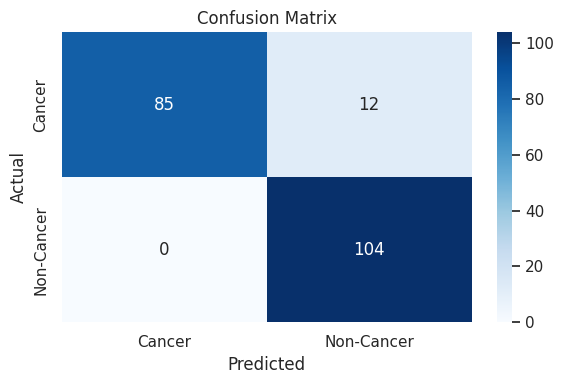

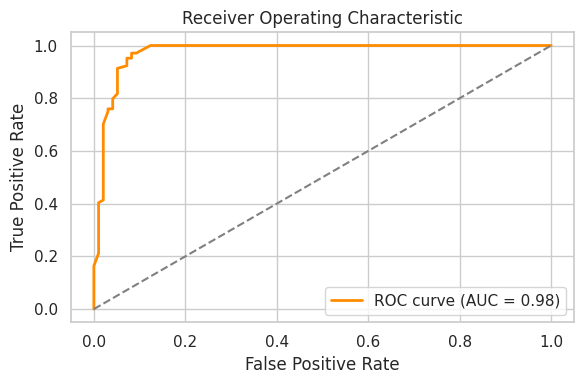

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.preprocessing import image
from keras.applications.vgg19 import VGG19, preprocess_input as vgg19_preprocess_input
from keras.applications.densenet import DenseNet121, preprocess_input as densenet_preprocess_input
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder, label_binarize
from tqdm import tqdm

# Load pretrained models
vgg19_model = VGG19(weights='imagenet', include_top=False, pooling='avg')
densenet_model = DenseNet121(weights='imagenet', include_top=False, pooling='avg')

# Feature extraction using VGG19
def extract_vgg19_features(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = vgg19_preprocess_input(x)
    features = vgg19_model.predict(x)
    return features.flatten()

# Feature extraction using DenseNet121
def extract_densenet_features(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = densenet_preprocess_input(x)
    features = densenet_model.predict(x)
    return features.flatten()

# Load images and extract combined features
def load_and_extract_features(folder_path, label):
    features = []
    labels = []
    for fname in tqdm(os.listdir(folder_path), desc=f"Processing {label}"):
        if fname.endswith(('.jpg', '.png')):
            img_path = os.path.join(folder_path, fname)
            vgg_feat = extract_vgg19_features(img_path)
            densenet_feat = extract_densenet_features(img_path)
            combined_feat = np.concatenate([vgg_feat, densenet_feat])
            features.append(combined_feat)
            labels.append(label)
    return features, labels

# Input paths
class1_folder = r"/content/drive/MyDrive/MBC_EWT/Cancer/subband_0"
class2_folder = r"/content/drive/MyDrive/MBC_EWT/Non-Cancer/subband_0"
output_folder = r"/content/drive/MyDrive/MBC_Feat"
os.makedirs(output_folder, exist_ok=True)

# Extract features and labels
class1_features, class1_labels = load_and_extract_features(class1_folder, "Cancer")
class2_features, class2_labels = load_and_extract_features(class2_folder, "Non-Cancer")

# Combine and encode labels
all_features = np.array(class1_features + class2_features)
all_labels = np.array(class1_labels + class2_labels)
le = LabelEncoder()
encoded_labels = le.fit_transform(all_labels)

# Save for future use
np.save(os.path.join(output_folder, 'features.npy'), all_features)
np.save(os.path.join(output_folder, 'labels.npy'), encoded_labels)
print(f"Features and labels saved to {output_folder}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(all_features, encoded_labels, test_size=0.2, random_state=42)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]  # Probabilities for ROC

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [ ]:
pip install xgboost



===== SVM =====
Accuracy: 0.9502487562189055
Classification Report:
               precision    recall  f1-score   support

      Benign       0.99      0.91      0.95        97
   Malignant       0.92      0.99      0.95       104

    accuracy                           0.95       201
   macro avg       0.95      0.95      0.95       201
weighted avg       0.95      0.95      0.95       201



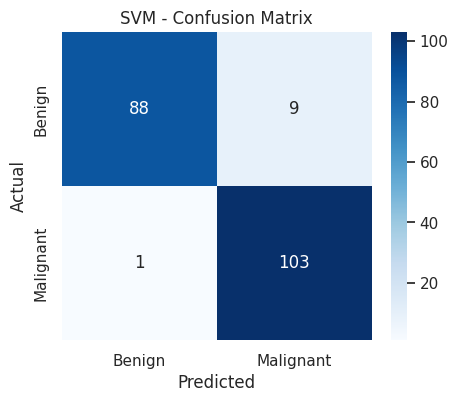


===== Random Forest =====
Accuracy: 0.9402985074626866
Classification Report:
               precision    recall  f1-score   support

      Benign       1.00      0.88      0.93        97
   Malignant       0.90      1.00      0.95       104

    accuracy                           0.94       201
   macro avg       0.95      0.94      0.94       201
weighted avg       0.95      0.94      0.94       201



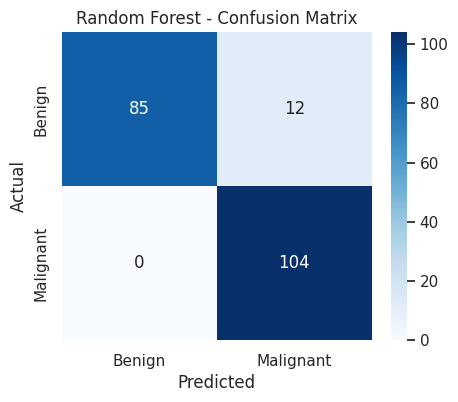


===== KNN =====
Accuracy: 0.9353233830845771
Classification Report:
               precision    recall  f1-score   support

      Benign       0.95      0.92      0.93        97
   Malignant       0.93      0.95      0.94       104

    accuracy                           0.94       201
   macro avg       0.94      0.93      0.94       201
weighted avg       0.94      0.94      0.94       201



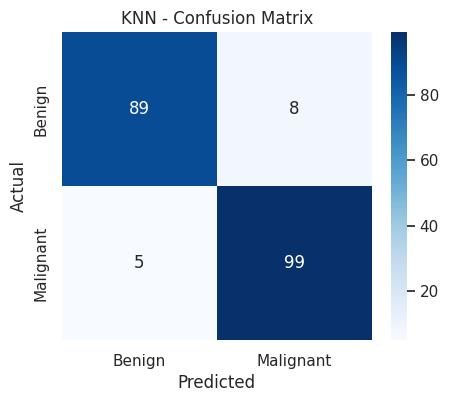


===== XGBoost =====


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:21:05] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.945273631840796
Classification Report:
               precision    recall  f1-score   support

      Benign       0.97      0.92      0.94        97
   Malignant       0.93      0.97      0.95       104

    accuracy                           0.95       201
   macro avg       0.95      0.94      0.95       201
weighted avg       0.95      0.95      0.95       201



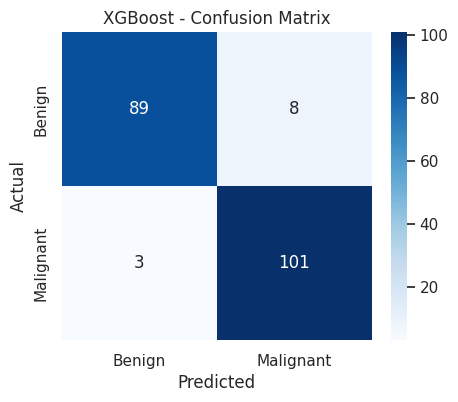

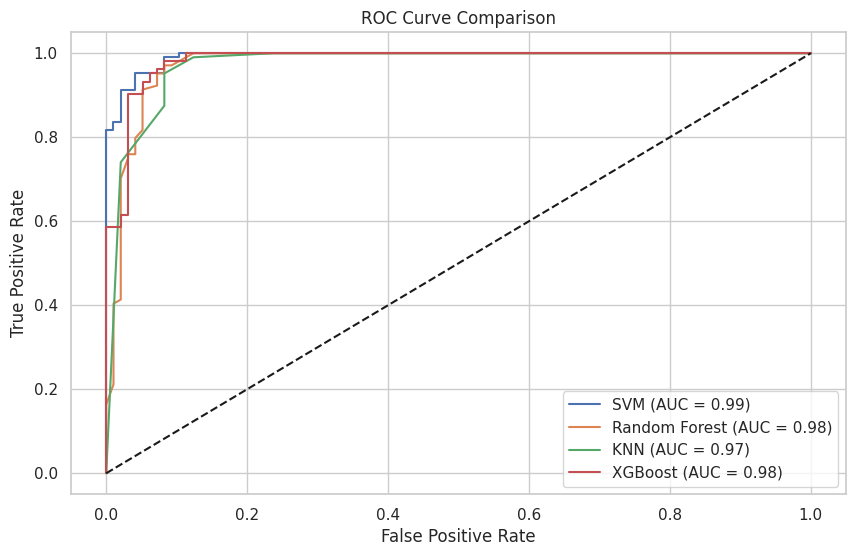

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelBinarizer

# === Load Data ===
X = np.load("/content/drive/MyDrive/MBC_Feat/features.npy")
y = np.load("/content/drive/MyDrive/MBC_Feat/labels.npy").ravel()  # Flatten labels if needed

# === Train-test split ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === Class names for confusion matrix ===
class_names = ["Benign", "Malignant"] if set(np.unique(y)) == {0, 1} else ["Class 0", "Class 1"]

# === Models dictionary ===
models = {
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# === Store predictions for ROC ===
roc_data = {}

# === Train and evaluate each model ===
for name, model in models.items():
    print(f"\n===== {name} =====")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # For ROC curve

    # Accuracy and report
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)
    print("Classification Report:\n", classification_report(y_test, y_pred, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Save for ROC
    roc_data[name] = y_prob

# === ROC Curve ===
plt.figure(figsize=(10, 6))

# Binarize labels
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test).ravel()

for name, y_prob in roc_data.items():
    fpr, tpr, _ = roc_curve(y_test_bin, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import os

# === Step 1: Load Feature and Label Files ===
features = np.load("/content/drive/MyDrive/MBC_Feat/features.npy")
labels = np.load("/content/drive/MyDrive/MBC_Feat/labels.npy").ravel()  # Ensure labels are 1D

# === Step 2: Normalize Features ===
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# === Step 3: Apply PCA ===
n_components = 100  # You can adjust this based on explained variance
pca = PCA(n_components=n_components)
features_pca = pca.fit_transform(features_scaled)

# === Step 4: Save Reduced Features and Labels ===
save_dir = "/content/drive/MyDrive/MBC_Feat/PCA_Output"
os.makedirs(save_dir, exist_ok=True)

np.save(os.path.join(save_dir, "features_pca.npy"), features_pca)
np.save(os.path.join(save_dir, "labels_pca.npy"), labels)

print(f"PCA reduced features saved to: {save_dir}")
print(f"Original shape: {features.shape}, PCA shape: {features_pca.shape}")


PCA reduced features saved to: /content/drive/MyDrive/MBC_Feat/PCA_Output
Original shape: (1002, 1536), PCA shape: (1002, 100)


In [ ]:
import numpy as np
from scipy.stats import ttest_ind
import os

# === Step 1: Load PCA-Reduced Features and Labels ===
features_pca = np.load("/content/drive/MyDrive/MBC_Feat/PCA_Output/features_pca.npy")
labels = np.load("/content/drive/MyDrive/MBC_Feat/PCA_Output/labels_pca.npy")

# === Step 2: Split Features by Class ===
class0 = features_pca[labels == 0]
class1 = features_pca[labels == 1]

# === Step 3: Apply t-test for Each Feature ===
t_scores, p_values = ttest_ind(class0, class1, axis=0)

# === Step 4: Rank Features by Absolute t-score ===
feature_ranking = np.argsort(np.abs(t_scores))[::-1]  # Descending order

# === Step 5: Select Top-k Features ===
k = 30  # Adjust number of top features
top_k_indices = feature_ranking[:k]
features_selected = features_pca[:, top_k_indices]

# === Step 6: Save Selected Features for Future Classifier Use ===
save_dir = "/content/drive/MyDrive/MBC_Feat/Ttest_Selected"
os.makedirs(save_dir, exist_ok=True)

np.save(os.path.join(save_dir, "features_selected.npy"), features_selected)
np.save(os.path.join(save_dir, "labels_selected.npy"), labels)
np.save(os.path.join(save_dir, "top_k_indices.npy"), top_k_indices)  # Optional: Save indices

print(f"T-test feature ranking complete.")
print(f"Selected top {k} features saved to: {save_dir}")


T-test feature ranking complete.
Selected top 30 features saved to: /content/drive/MyDrive/MBC_Feat/Ttest_Selected


In [ ]:
pip install numpy pandas matplotlib seaborn scikit-learn shap eli5 pdpbox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.0/64.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 9.5 MB/s eta 0:00:00


In [ ]:
pip install shap==0.44.0 pandas numpy matplotlib scikit-learn

In [ ]:
pip install pdpbox --upgrade


In [ ]:
pip install pdpbox --upgrade


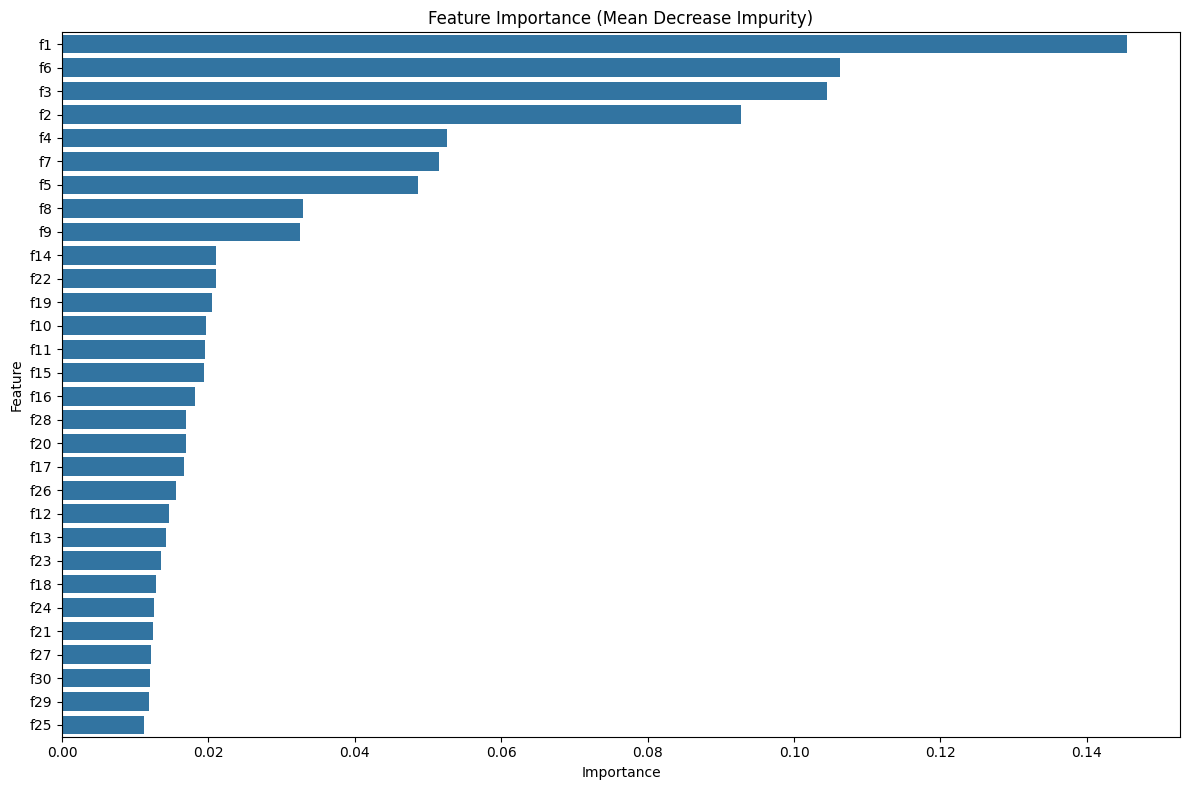

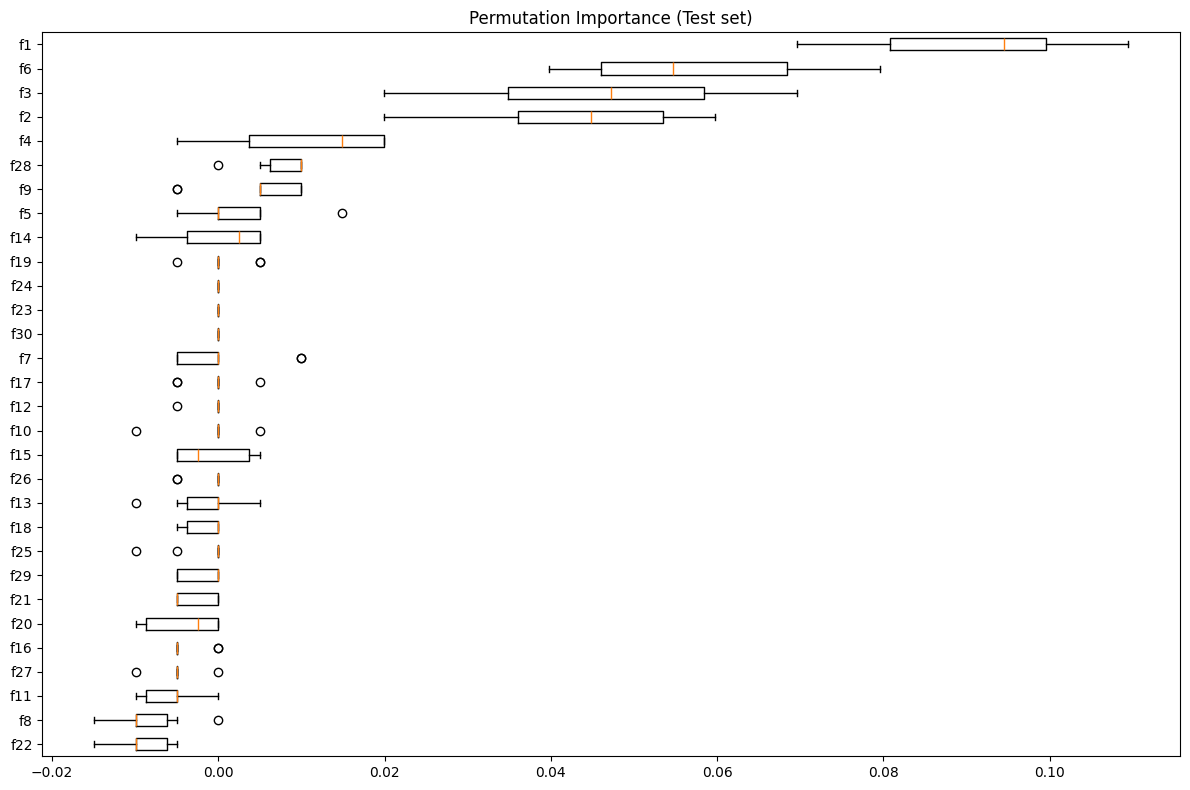

<Figure size 640x480 with 0 Axes>

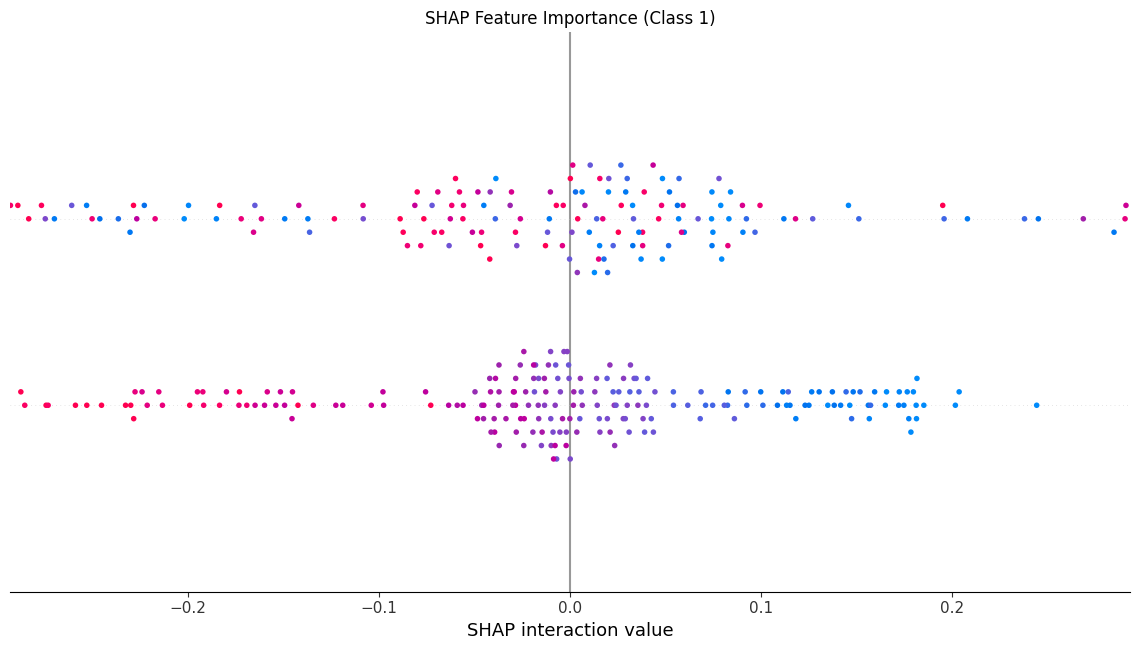

<Figure size 640x480 with 0 Axes>

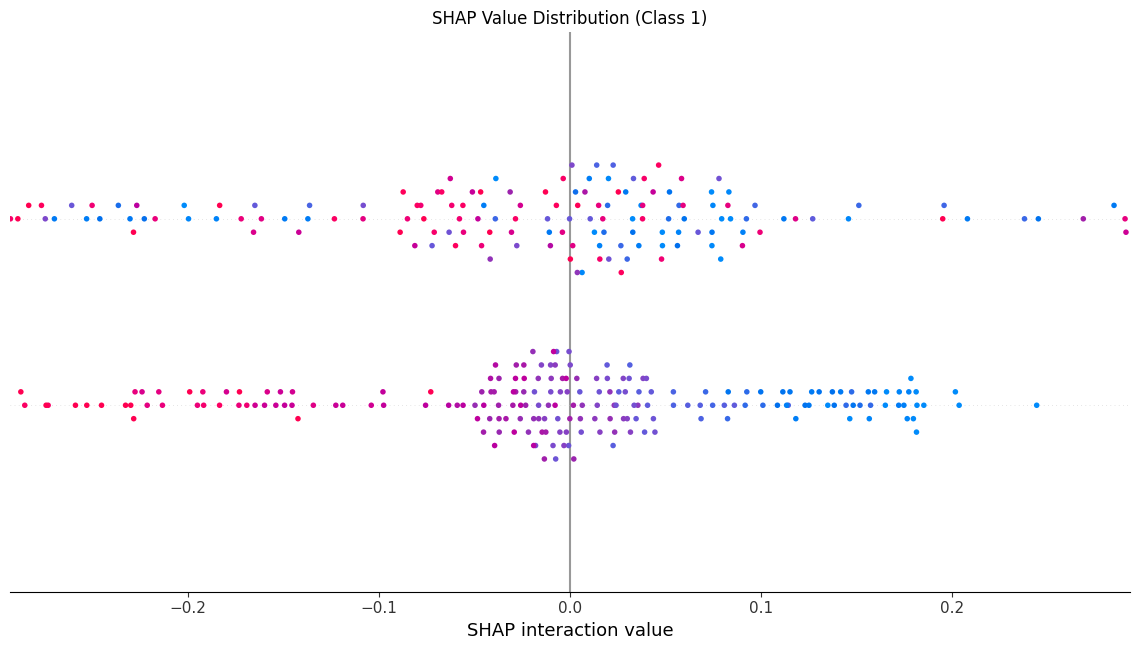

NameError: name 'pdp_isolate' is not defined

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.inspection import permutation_importance
import shap
from sklearn.tree import plot_tree
import eli5
from eli5.sklearn import PermutationImportance
from pdpbox import pdp  # Removed get_dataset import

# Set random seed for reproducibility
np.random.seed(42)

# Load .npy files
try:
    features = np.load('/content/drive/MyDrive/MBC_Feat/Ttest_Selected/features_selected.npy')  # Shape: (n_samples, 30)
    labels = np.load('/content/drive/MyDrive/MBC_Feat/Ttest_Selected/labels_selected.npy')      # Shape: (n_samples,)
except Exception as e:
    print(f"Error loading files: {e}")
    exit()

# Check data consistency
if len(features) != len(labels):
    print("Error: Mismatch between features and labels length")
    exit()
if features.shape[1] != 30:
    print("Error: Expected 30 features")
    exit()

# Create DataFrame with feature names
feature_names = [f'f{i}' for i in range(1, 31)]
df = pd.DataFrame(features, columns=feature_names)
labels = pd.Series(labels.flatten())  # Ensure labels are 1D

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df, labels, test_size=0.2, random_state=42
)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 1. Feature Importance (MDI)
plt.figure(figsize=(12, 8))
importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=importances)
plt.title('Feature Importance (Mean Decrease Impurity)')
plt.tight_layout()
plt.show()

# 2. Permutation Importance
perm_importance = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=42
)

plt.figure(figsize=(12, 8))
sorted_idx = perm_importance.importances_mean.argsort()
plt.boxplot(perm_importance.importances[sorted_idx].T,
            vert=False, labels=X_test.columns[sorted_idx])
plt.title("Permutation Importance (Test set)")
plt.tight_layout()
plt.show()

# 3. SHAP Analysis (Corrected Version)
try:
    # Initialize explainer with correct parameters
    explainer = shap.TreeExplainer(rf, feature_perturbation="tree_path_dependent")

    # Calculate SHAP values properly for binary classification
    shap_values = explainer.shap_values(X_test)

    # Handle different SHAP output formats
    if isinstance(shap_values, list):
        # Binary classification: [negative_class_shap, positive_class_shap]
        shap_values_plot = shap_values[1]  # Use positive class SHAP values
    else:
        # Single output format
        shap_values_plot = shap_values

    # Plot SHAP summary plots
    plt.figure()
    shap.summary_plot(shap_values_plot, X_test, plot_type="bar", show=False)
    plt.title('SHAP Feature Importance (Class 1)')
    plt.tight_layout()
    plt.show()

    plt.figure()
    shap.summary_plot(shap_values_plot, X_test, show=False)
    plt.title('SHAP Value Distribution (Class 1)')
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"SHAP Error: {e}")
    print("Try updating SHAP: pip install --upgrade shap")

# 4. Partial Dependence Plots
top_feature = importances.iloc[0]['Feature']

# Isolate PDP
pdp_iso = pdp_isolate(
    model=rf,
    dataset=X_test,
    model_features=feature_names,
    feature=top_feature
)

# Plot PDP
pdp_plot(pdp_iso, top_feature)
plt.title(f'Partial Dependence Plot for {top_feature}')
plt.tight_layout()
plt.show()

# 5. Decision Tree Visualization
plt.figure(figsize=(20, 10))
plot_tree(rf.estimators_[0],
          feature_names=feature_names,
          class_names=['0', '1'],
          filled=True,
          max_depth=2)
plt.title('Decision Tree Visualization')
plt.show()

# 6. ELI5 Permutation Importance
perm = PermutationImportance(rf, random_state=42).fit(X_test, y_test)
display(eli5.show_weights(perm, feature_names=feature_names))

# 7. Correlation Matrix
plt.figure(figsize=(15, 12))
corr_matrix = X_train.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# 8. Pair Plots of Top 3 Features
top_3 = importances['Feature'].head(3).tolist()
sns.pairplot(pd.concat([X_train[top_3], y_train.rename('label')], axis=1), hue='label')
plt.suptitle('Pair Plots of Top 3 Features', y=1.02)
plt.tight_layout()
plt.show()

# 9. Model Performance
y_pred = rf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

plt.figure()
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

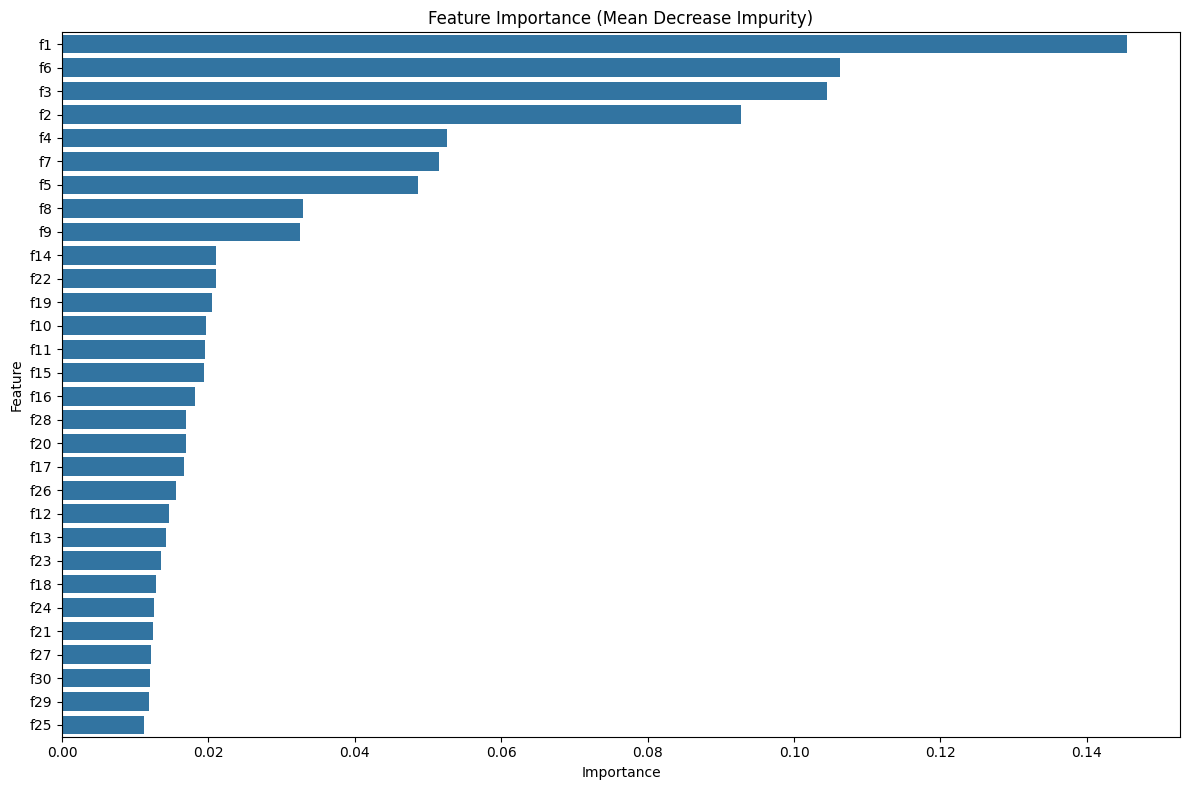

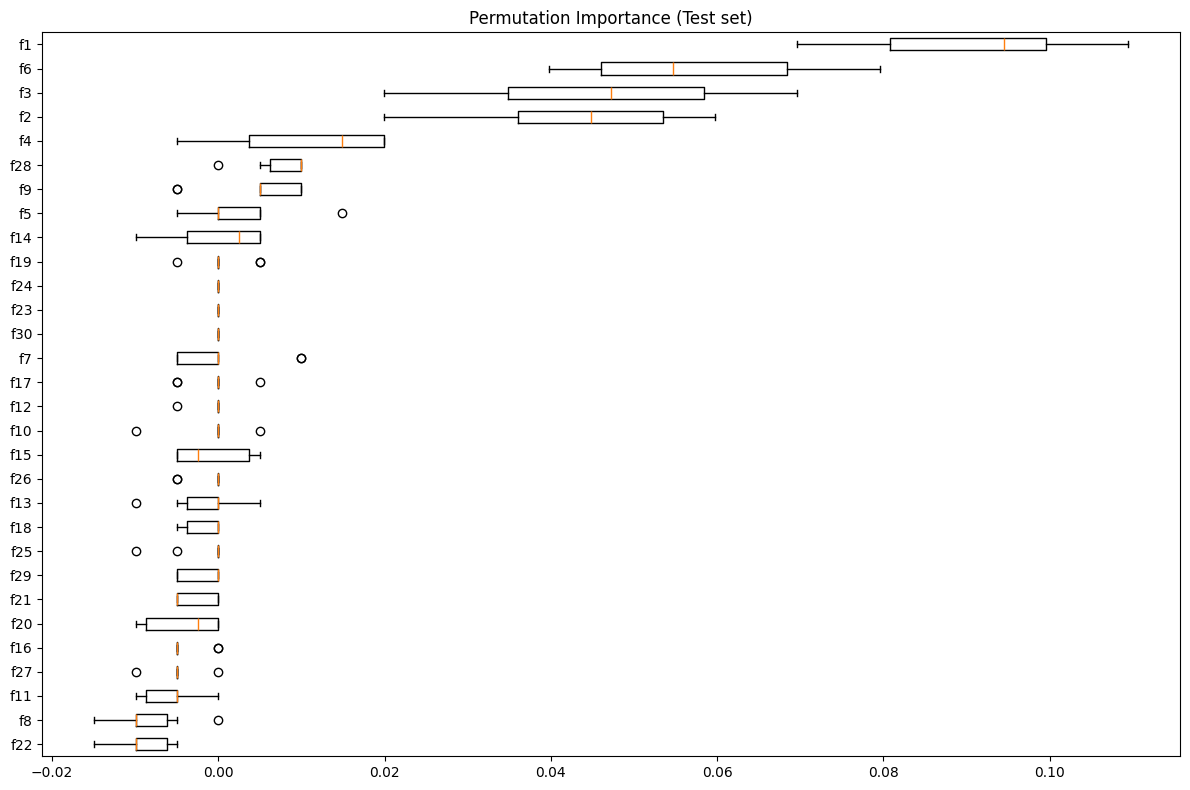

<Figure size 640x480 with 0 Axes>

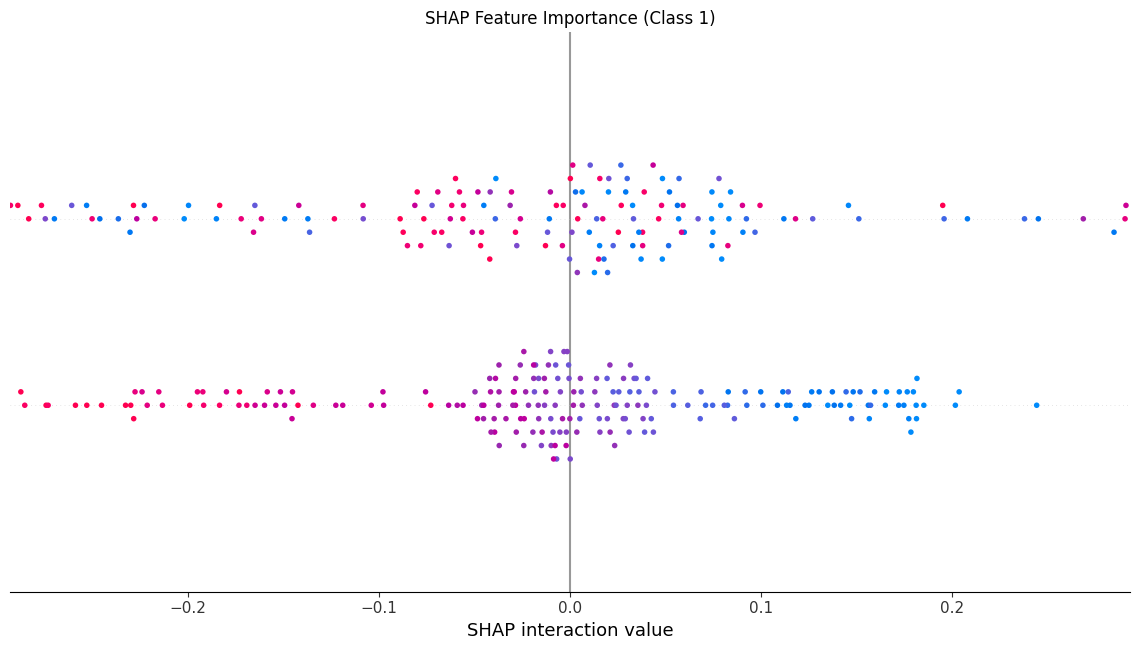

<Figure size 640x480 with 0 Axes>

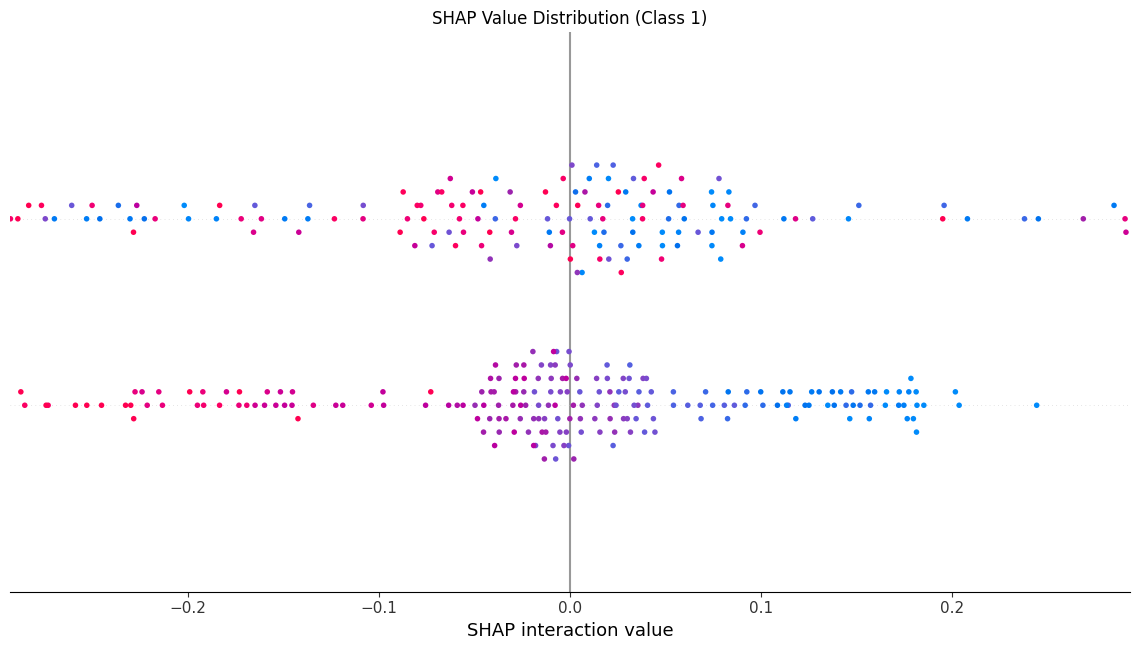

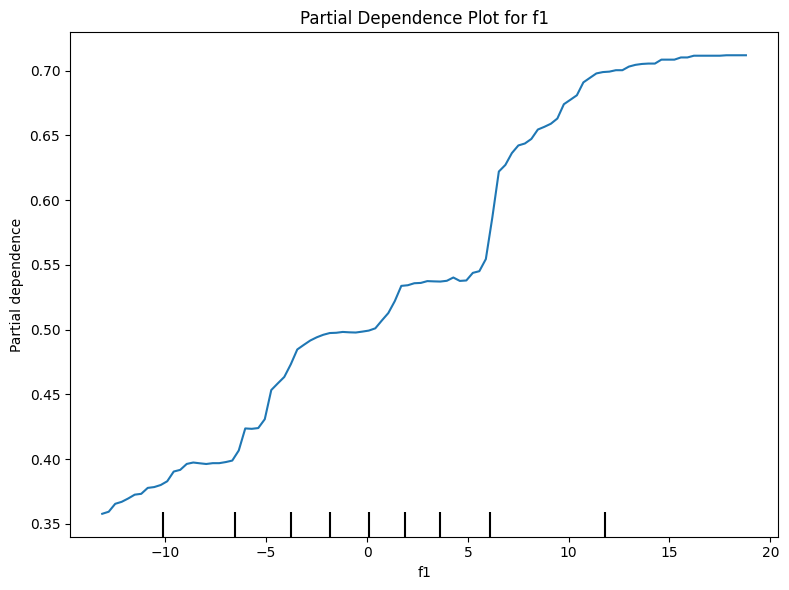

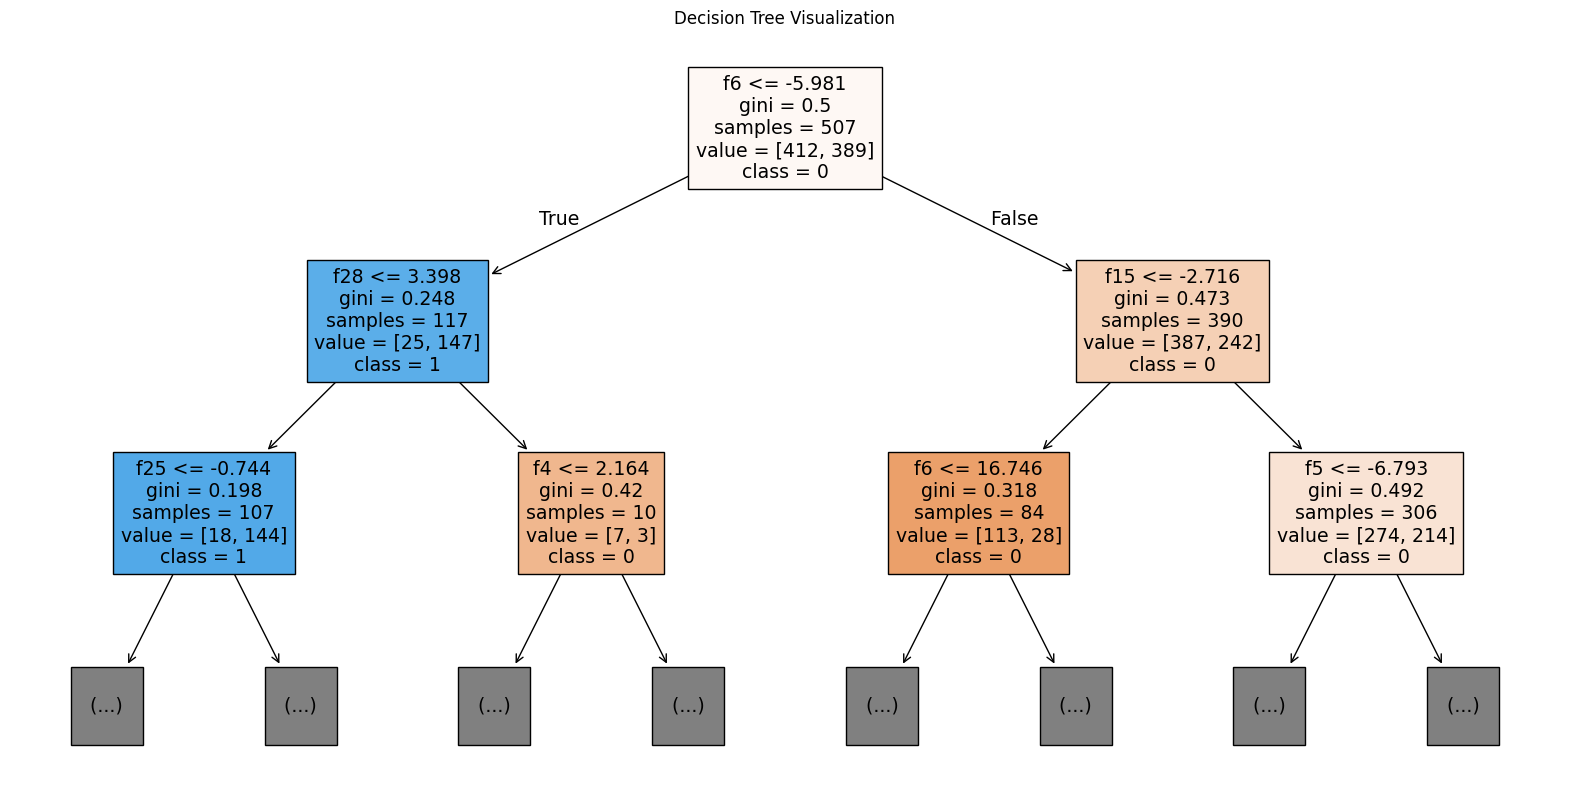

Weight,Feature
0.0925 ± 0.0205,f1
0.0567 ± 0.0240,f6
0.0458 ± 0.0182,f3
0.0418 ± 0.0205,f2
0.0080 ± 0.0162,f4
0.0070 ± 0.0080,f28
0.0040 ± 0.0132,f7
0.0040 ± 0.0116,f5
0.0020 ± 0.0049,f14
0.0010 ± 0.0074,f10


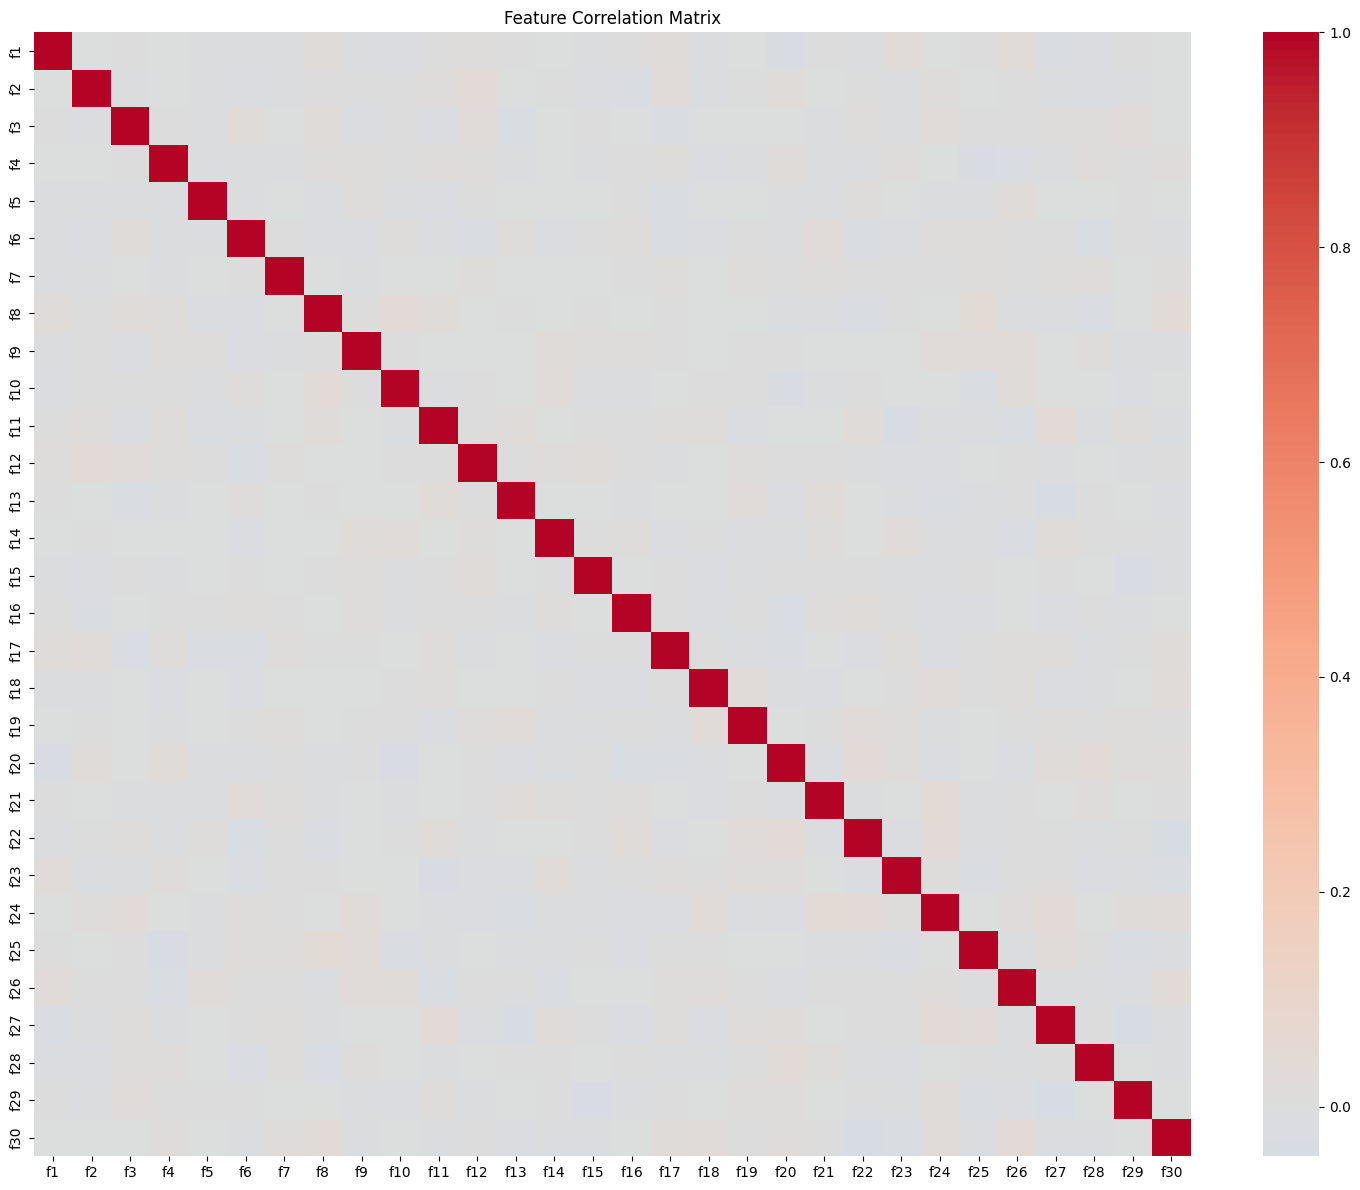

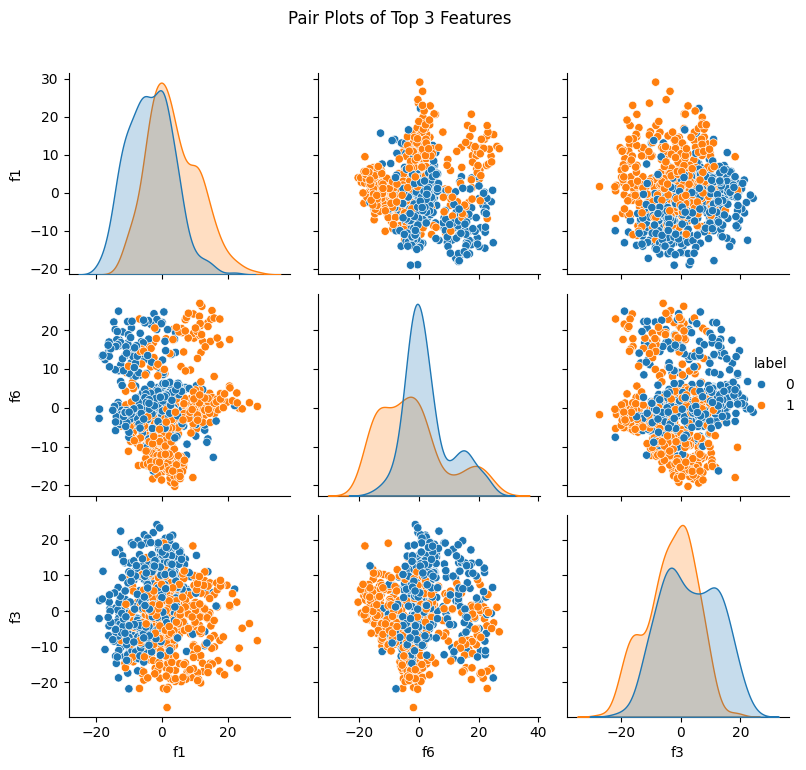


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.89      0.92        97
           1       0.90      0.96      0.93       104

    accuracy                           0.93       201
   macro avg       0.93      0.92      0.93       201
weighted avg       0.93      0.93      0.93       201



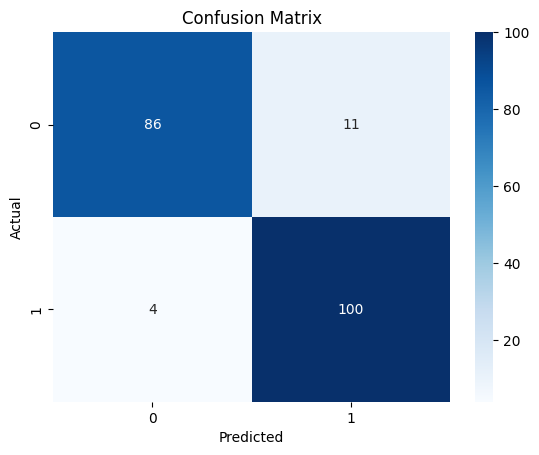

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import shap
from sklearn.tree import plot_tree
import eli5
from eli5.sklearn import PermutationImportance

# Set random seed for reproducibility
np.random.seed(42)

# Load .npy files
try:
    features = np.load('/content/drive/MyDrive/MBC_Feat/Ttest_Selected/features_selected.npy')  # Shape: (n_samples, 30)
    labels = np.load('/content/drive/MyDrive/MBC_Feat/Ttest_Selected/labels_selected.npy')      # Shape: (n_samples,)
except Exception as e:
    print(f"Error loading files: {e}")
    exit()

# Check data consistency
if len(features) != len(labels):
    print("Error: Mismatch between features and labels length")
    exit()
if features.shape[1] != 30:
    print("Error: Expected 30 features")
    exit()

# Create DataFrame with feature names
feature_names = [f'f{i}' for i in range(1, 31)]
df = pd.DataFrame(features, columns=feature_names)
labels = pd.Series(labels.flatten())  # Ensure labels are 1D

# Split data
X_train, X_test, y_train, y_test = train_test_split(df, labels, test_size=0.2, random_state=42)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 1. Feature Importance (MDI)
plt.figure(figsize=(12, 8))
importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=importances)
plt.title('Feature Importance (Mean Decrease Impurity)')
plt.tight_layout()
plt.show()

# 2. Permutation Importance
perm_importance = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=42
)

plt.figure(figsize=(12, 8))
sorted_idx = perm_importance.importances_mean.argsort()
plt.boxplot(perm_importance.importances[sorted_idx].T,
            vert=False, labels=X_test.columns[sorted_idx])
plt.title("Permutation Importance (Test set)")
plt.tight_layout()
plt.show()

# 3. SHAP Analysis
try:
    explainer = shap.TreeExplainer(rf, feature_perturbation="tree_path_dependent")
    shap_values = explainer.shap_values(X_test)

    if isinstance(shap_values, list):
        shap_values_plot = shap_values[1]  # Use positive class SHAP values
    else:
        shap_values_plot = shap_values

    shap.summary_plot(shap_values_plot, X_test, plot_type="bar", show=False)
    plt.title('SHAP Feature Importance (Class 1)')
    plt.tight_layout()
    plt.show()

    shap.summary_plot(shap_values_plot, X_test, show=False)
    plt.title('SHAP Value Distribution (Class 1)')
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"SHAP Error: {e}")
    print("Try updating SHAP: pip install --upgrade shap")

# 4. Partial Dependence Plot using sklearn (instead of pdpbox)
top_feature = importances.iloc[0]['Feature']

fig, ax = plt.subplots(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(
    rf,
    X_test,
    [top_feature],
    feature_names=feature_names,
    ax=ax
)
plt.title(f'Partial Dependence Plot for {top_feature}')
plt.tight_layout()
plt.show()

# 5. Decision Tree Visualization
plt.figure(figsize=(20, 10))
plot_tree(rf.estimators_[0],
          feature_names=feature_names,
          class_names=['0', '1'],
          filled=True,
          max_depth=2)
plt.title('Decision Tree Visualization')
plt.show()

# 6. ELI5 Permutation Importance
perm = PermutationImportance(rf, random_state=42).fit(X_test, y_test)
display(eli5.show_weights(perm, feature_names=feature_names))

# 7. Correlation Matrix
plt.figure(figsize=(15, 12))
corr_matrix = X_train.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# 8. Pair Plots of Top 3 Features
top_3 = importances['Feature'].head(3).tolist()
sns.pairplot(pd.concat([X_train[top_3], y_train.rename('label')], axis=1), hue='label')
plt.suptitle('Pair Plots of Top 3 Features', y=1.02)
plt.tight_layout()
plt.show()

# 9. Model Performance
y_pred = rf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

plt.figure()
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# Step 1: Install necessary packages
!pip install shap matplotlib numpy pandas scikit-learn

# Step 2: Import necessary libraries
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Step 3: Load features and labels from T-test selected files
X = np.load('/content/drive/MyDrive/MBC_Feat/Ttest_Selected/features_selected.npy')  # T-test selected features
y = np.load('/content/drive/MyDrive/MBC_Feat/Ttest_Selected/labels_selected.npy')    # Labels: 0 = Non-cancerous, 1 = Cancerous

# Step 4: Validate data
print(f"Features shape: {X.shape}")  # e.g., (N, 30)
print(f"Labels shape: {y.shape}")    # e.g., (N,)

# Step 5: Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 7: Evaluate performance
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Step 8: SHAP explanation
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Step 9: SHAP Beeswarm Plot (Global Importance)
shap.summary_plot(shap_values[1], X_test, class_names=["Non-Cancerous", "Cancerous"])

# Step 10: SHAP Force Plot for a single sample (Local Explanation)
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[1][0], X_test[0])

# Step 11: SHAP Dependence Plot for feature index 0 (Change index if needed)
shap.dependence_plot(0, shap_values[1], X_test)



Features shape: (1002, 30)
Labels shape: (1002,)
Model Accuracy: 92.54%


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 640x480 with 0 Axes>

Model Accuracy: 93.03%


<Figure size 640x480 with 0 Axes>

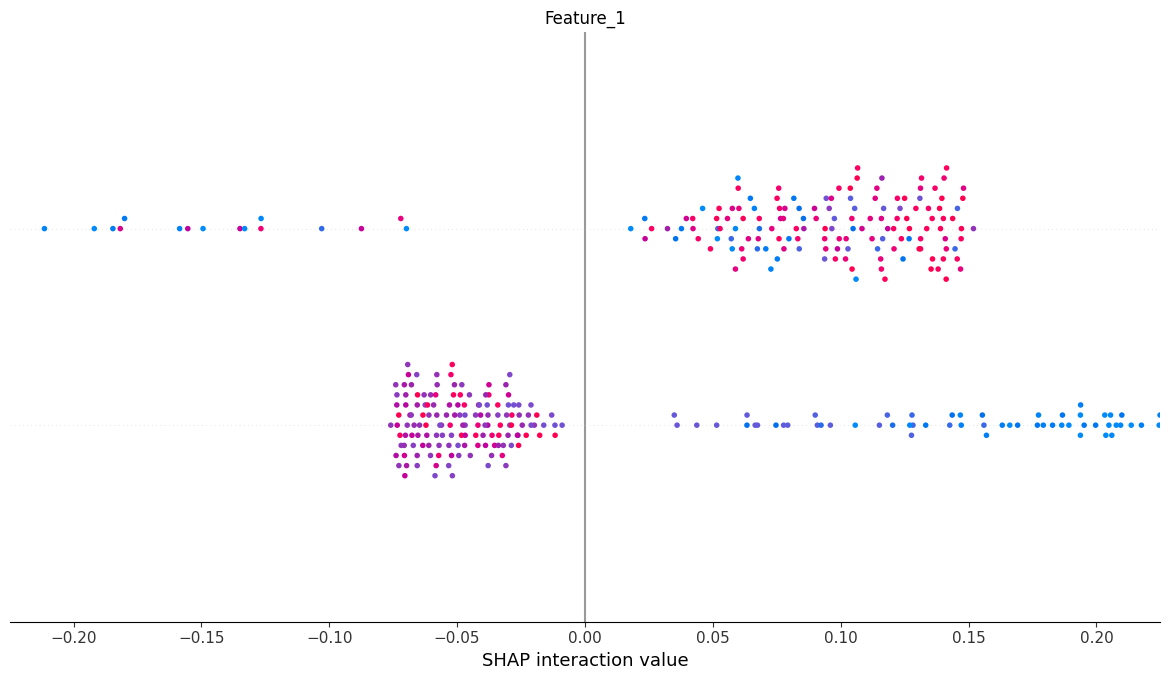

In [ ]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Step 1: Load .npy features and labels
features = np.load('/content/drive/MyDrive/MBC_Feat/PCA_Output/features_pca.npy')
labels = np.load('/content/drive/MyDrive/MBC_Feat/PCA_Output/labels_pca.npy').flatten()

# Step 2: Auto-generate feature names
feature_names = [f'Feature_{i}' for i in range(features.shape[1])]

# Step 3: Prepare DataFrame
X = pd.DataFrame(features, columns=feature_names)
y = pd.Series(labels)

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 6: Predict and print accuracy
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {acc*100:.2f}%")

# Step 7: SHAP Explanation
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Step 8: SHAP summary plot
if isinstance(shap_values, list) and len(shap_values) == 2:
    shap.summary_plot(shap_values[1], X_test, feature_names=feature_names, class_names=["Non-Cancerous", "Cancerous"])
else:
    shap.summary_plot(shap_values, X_test, feature_names=feature_names)


In [ ]:
pip install shap



=== Random Forest ===
Accuracy: 0.97
Sensitivity: 0.98
Specificity: 0.95
AUC: 0.99
Confusion Matrix:
 [[96  5]
 [ 2 98]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96       101
           1       0.95      0.98      0.97       100

    accuracy                           0.97       201
   macro avg       0.97      0.97      0.97       201
weighted avg       0.97      0.97      0.97       201



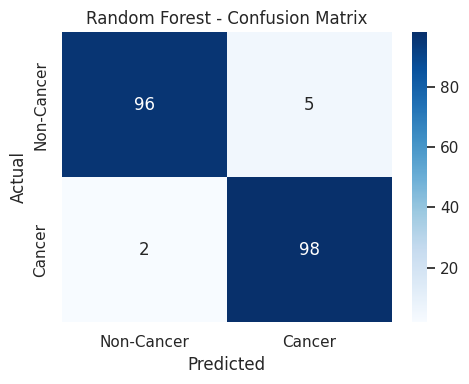


=== SVM ===
Accuracy: 0.98
Sensitivity: 1.00
Specificity: 0.96
AUC: 0.99
Confusion Matrix:
 [[ 97   4]
 [  0 100]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98       101
           1       0.96      1.00      0.98       100

    accuracy                           0.98       201
   macro avg       0.98      0.98      0.98       201
weighted avg       0.98      0.98      0.98       201



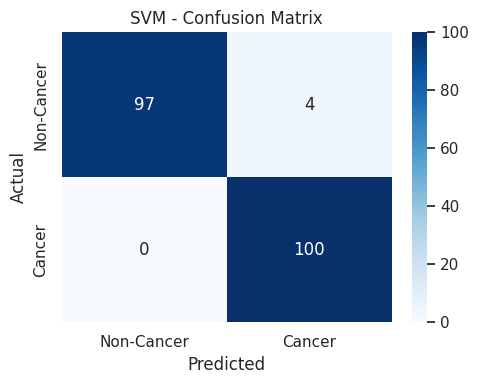


=== KNN ===
Accuracy: 0.94
Sensitivity: 0.94
Specificity: 0.93
AUC: 0.96
Confusion Matrix:
 [[94  7]
 [ 6 94]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.93      0.94       101
           1       0.93      0.94      0.94       100

    accuracy                           0.94       201
   macro avg       0.94      0.94      0.94       201
weighted avg       0.94      0.94      0.94       201



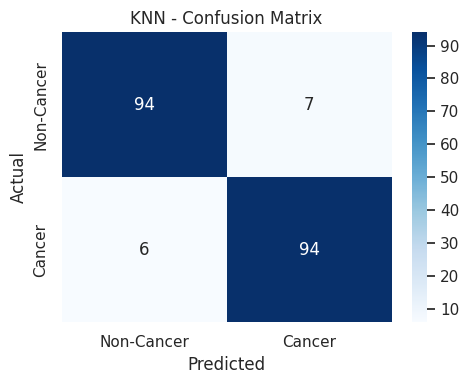

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:45:57] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



=== XGBoost ===
Accuracy: 0.95
Sensitivity: 0.97
Specificity: 0.93
AUC: 0.99
Confusion Matrix:
 [[94  7]
 [ 3 97]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.93      0.95       101
           1       0.93      0.97      0.95       100

    accuracy                           0.95       201
   macro avg       0.95      0.95      0.95       201
weighted avg       0.95      0.95      0.95       201



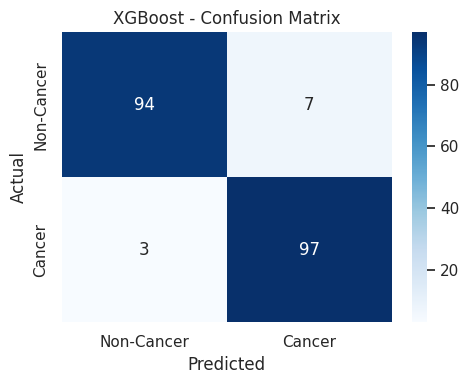

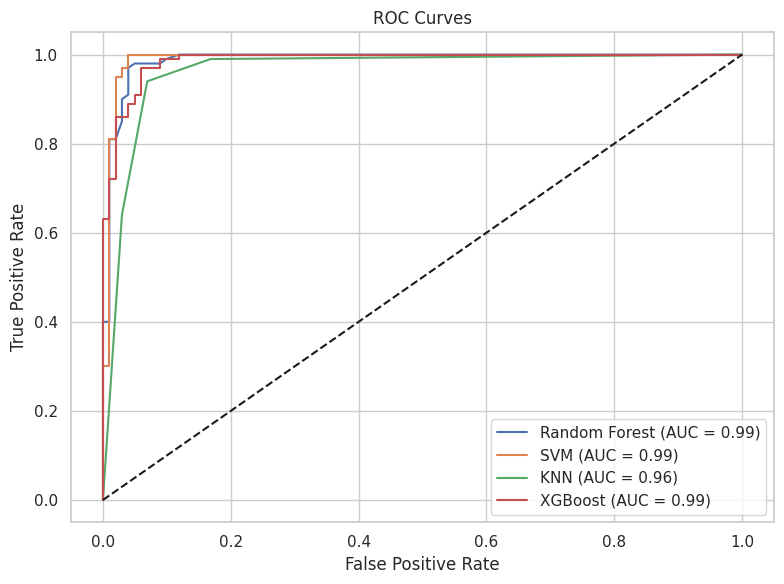

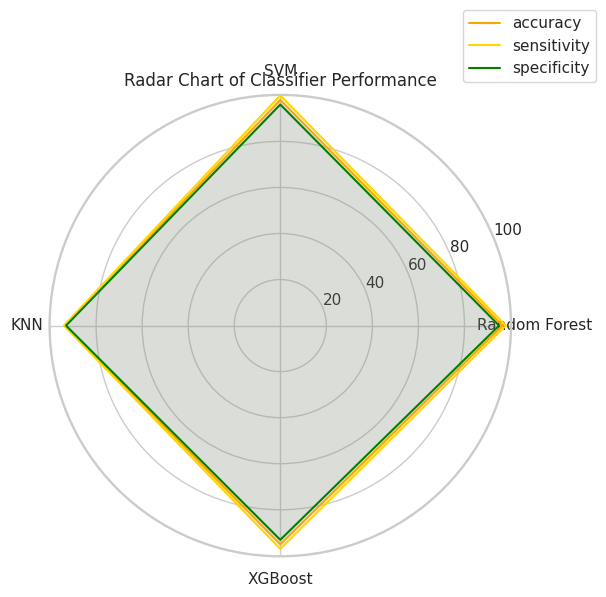

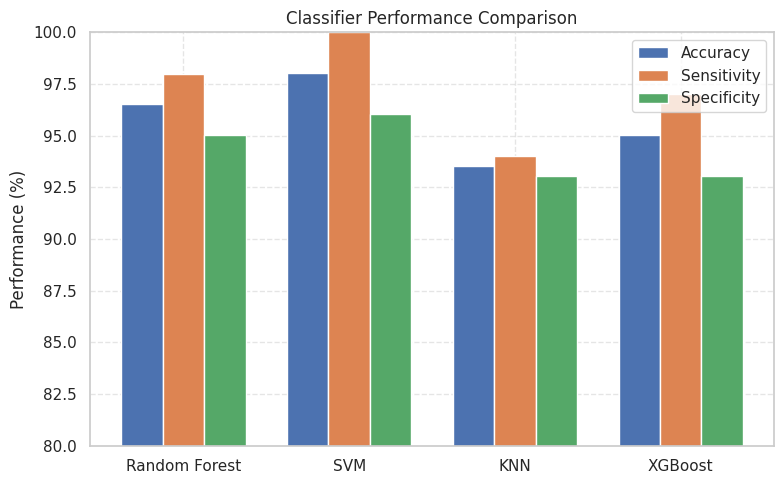

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import seaborn as sns

# === Load selected features and labels ===
features = np.load('/content/drive/MyDrive/MBC_Feat/Ttest_Selected/features_selected.npy')
labels = np.load('/content/drive/MyDrive/MBC_Feat/Ttest_Selected/labels_selected.npy')

# === Train/Test Split ===
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, stratify=labels, random_state=42)

# === Standardize features ===
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# === Define classifiers ===
classifiers = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, kernel='rbf', random_state=42),
    'KNN': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = {}
class_names = ['Non-Cancer', 'Cancer']

# === Function to plot confusion matrix with correct labels ===
def plot_confusion(cm, title):
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{title} - Confusion Matrix')
    plt.tight_layout()
    plt.show()

# === Train, predict, evaluate ===
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    sensitivity = cm[1, 1] / (cm[1, 0] + cm[1, 1]) if (cm[1, 0] + cm[1, 1]) > 0 else 0
    specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1]) if (cm[0, 0] + cm[0, 1]) > 0 else 0
    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    results[name] = {
        'accuracy': acc * 100,
        'sensitivity': sensitivity * 100,
        'specificity': specificity * 100,
        'roc_auc': auc,
        'fpr': fpr,
        'tpr': tpr,
        'confusion_matrix': cm,
        'report': classification_report(y_test, y_pred, output_dict=True)
    }

    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.2f}")
    print(f"Sensitivity: {sensitivity:.2f}")
    print(f"Specificity: {specificity:.2f}")
    print(f"AUC: {auc:.2f}")
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_test, y_pred))

    plot_confusion(cm, name)

# === ROC Curve for all classifiers ===
plt.figure(figsize=(8, 6))
for name, res in results.items():
    plt.plot(res['fpr'], res['tpr'], label=f'{name} (AUC = {res["roc_auc"]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Radar Chart ===
metrics = ['accuracy', 'sensitivity', 'specificity']
angles = np.linspace(0, 2 * np.pi, len(classifiers), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
for metric, color in zip(metrics, ['orange', 'gold', 'green']):
    values = [results[clf][metric] for clf in classifiers]
    values += values[:1]
    ax.plot(angles, values, label=metric, color=color)
    ax.fill(angles, values, alpha=0.1)
ax.set_thetagrids(np.degrees(angles[:-1]), list(classifiers.keys()))
plt.title("Radar Chart of Classifier Performance")
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.2))
plt.show()

# === Bar Chart like Sigma Parameters ===
accs = [results[name]['accuracy'] for name in classifiers]
sens = [results[name]['sensitivity'] for name in classifiers]
specs = [results[name]['specificity'] for name in classifiers]

x = np.arange(len(classifiers))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width, accs, width, label='Accuracy')
ax.bar(x, sens, width, label='Sensitivity')
ax.bar(x + width, specs, width, label='Specificity')

ax.set_xticks(x)
ax.set_xticklabels(list(classifiers.keys()))
ax.set_ylim(80, 100)
ax.set_ylabel('Performance (%)')
ax.set_title('Classifier Performance Comparison')
ax.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


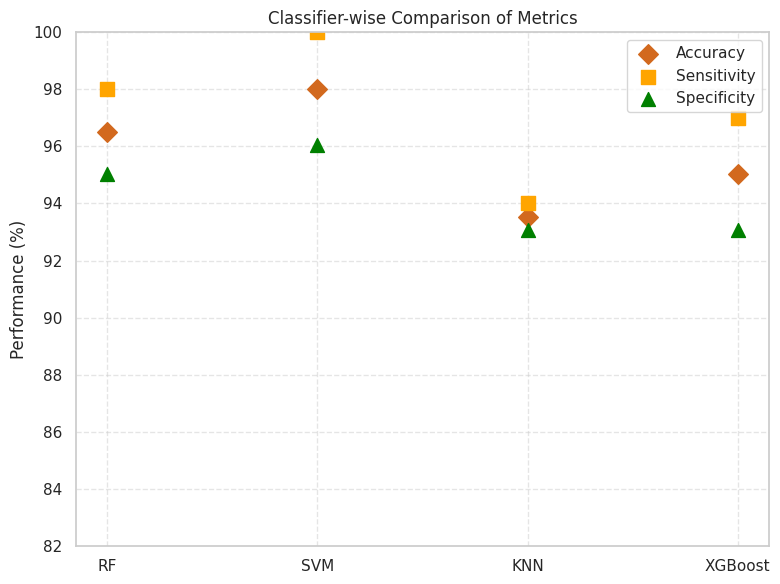

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data — replace these with your actual `results` dictionary values
classifiers = ['RF', 'SVM', 'KNN', 'XGBoost']
accuracy = [results['Random Forest']['accuracy'],
            results['SVM']['accuracy'],
            results['KNN']['accuracy'],
            results['XGBoost']['accuracy']]

sensitivity = [results['Random Forest']['sensitivity'],
               results['SVM']['sensitivity'],
               results['KNN']['sensitivity'],
               results['XGBoost']['sensitivity']]

specificity = [results['Random Forest']['specificity'],
               results['SVM']['specificity'],
               results['KNN']['specificity'],
               results['XGBoost']['specificity']]

x = np.arange(len(classifiers))

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x, accuracy, label='Accuracy', marker='D', color='chocolate', s=100)
plt.scatter(x, sensitivity, label='Sensitivity', marker='s', color='orange', s=100)
plt.scatter(x, specificity, label='Specificity', marker='^', color='green', s=100)

plt.xticks(x, classifiers)
plt.yticks(np.arange(82, 101, 2))
plt.ylim(82, 100)
plt.ylabel("Performance (%)")
plt.title("Classifier-wise Comparison of Metrics")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
print(shap_values.shape)


(201, 30, 2)


In [ ]:
pip install shap


Features shape: (1002, 30)
Labels shape: (1002,)
Model Accuracy: 92.54%


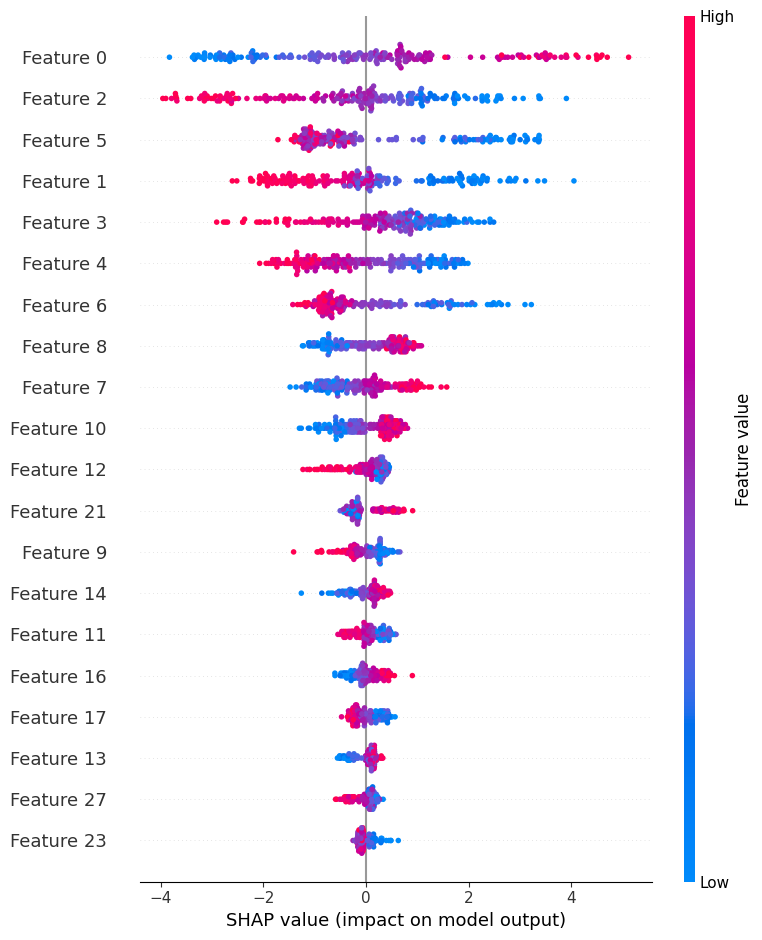

IndexError: invalid index to scalar variable.

In [ ]:
# Step 1: Install necessary packages (if not already installed)
!pip install shap matplotlib numpy pandas scikit-learn

# Step 2: Import necessary libraries
import xgboost as xgb
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score



# Step 4: Load your feature data and labels (adjust path as needed)
X = np.load('/content/drive/MyDrive/MBC_Feat/Ttest_Selected/features_selected.npy')  # Features (VGG16 + VGG19)
y = np.load('/content/drive/MyDrive/MBC_Feat/Ttest_Selected/labels_selected.npy')    # Labels (0 = Benign, 1 = Malignant)

# Step 5: Check if the data is correctly loaded
print(f"Features shape: {X.shape}")  # Should print (number_of_samples, number_of_features)
print(f"Labels shape: {y.shape}")    # Should print (number_of_samples,)

# Step 6: Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Train an XGBoost model
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Step 8: Evaluate the model
y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Step 9: SHAP explanation for the model
# Create a SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Step 10: Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Step 11: Visualize SHAP summary plot (global explainability)
shap.summary_plot(shap_values, X_test)

# Step 12: Visualize SHAP force plot for a specific instance (local explainability)
shap.initjs()  # Initializes JS visualization for interactive plots

# Correct way to access the SHAP values for class 1 (Malignant)
# For class 1 (Malignant), we access shap_values[1], which is an array of SHAP values for class 1.
shap.force_plot(explainer.expected_value[1], shap_values[1][0], X_test[0])

# Step 13: Visualize SHAP dependence plot (how a single feature influences the prediction)
# Replace '0' with the feature index you're interested in
shap.dependence_plot(0, shap_values[1], X_test)  # 0 is the feature index (you can choose another feature index)


Features shape: (1002, 1536)
Labels shape: (1002,)
Model Accuracy: 94.53%


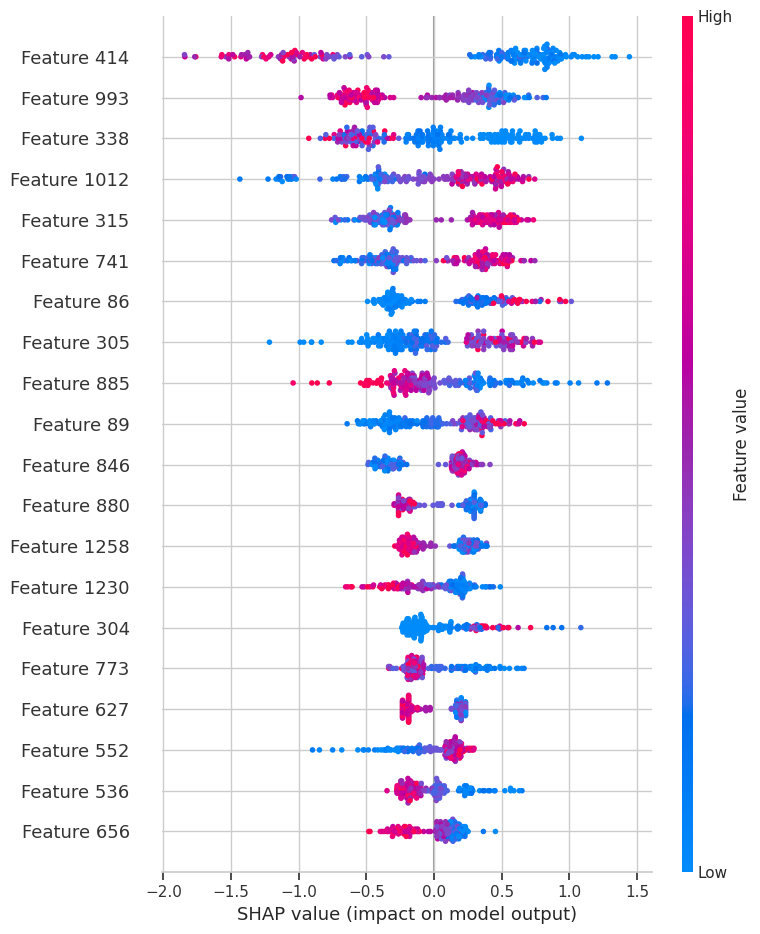

IndexError: invalid index to scalar variable.

In [ ]:
# Step 1: Install necessary packages (if not already installed)
!pip install xgboost shap matplotlib numpy pandas scikit-learn

# Step 2: Import necessary libraries
import xgboost as xgb
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score



# Step 4: Load your feature data and labels (adjust path as needed)
# Use np.load to load .npy files instead of pd.read_csv
X = np.load('/content/drive/MyDrive/MBC_Feat/features.npy')  # Features (VGG16 + VGG19)
y = np.load('/content/drive/MyDrive/MBC_Feat/labels.npy')    # Labels (0 = Benign, 1 = Malignant)

# Step 5: Check if the data is correctly loaded
print(f"Features shape: {X.shape}")  # Should print (number_of_samples, number_of_features)
print(f"Labels shape: {y.shape}")    # Should print (number_of_samples,)

# Step 6: Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Train an XGBoost model
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Step 8: Evaluate the model
y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Step 9: SHAP explanation for the model
# Create a SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Step 10: Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Step 11: Visualize SHAP summary plot (global explainability)
shap.summary_plot(shap_values, X_test)

# Step 12: Visualize SHAP force plot for a specific instance (local explainability)
shap.initjs()  # Initializes JS visualization for interactive plots
shap.force_plot(explainer.expected_value[1], shap_values[1][0], X_test[0])

# Step 13: Visualize SHAP dependence plot (how a single feature influences the prediction)
# Replace '0' with the feature index you're interested in
shap.dependence_plot(0, shap_values, X_test)


Features shape: (1002, 1536)
Labels shape: (1002,)
Model Accuracy: 94.53%


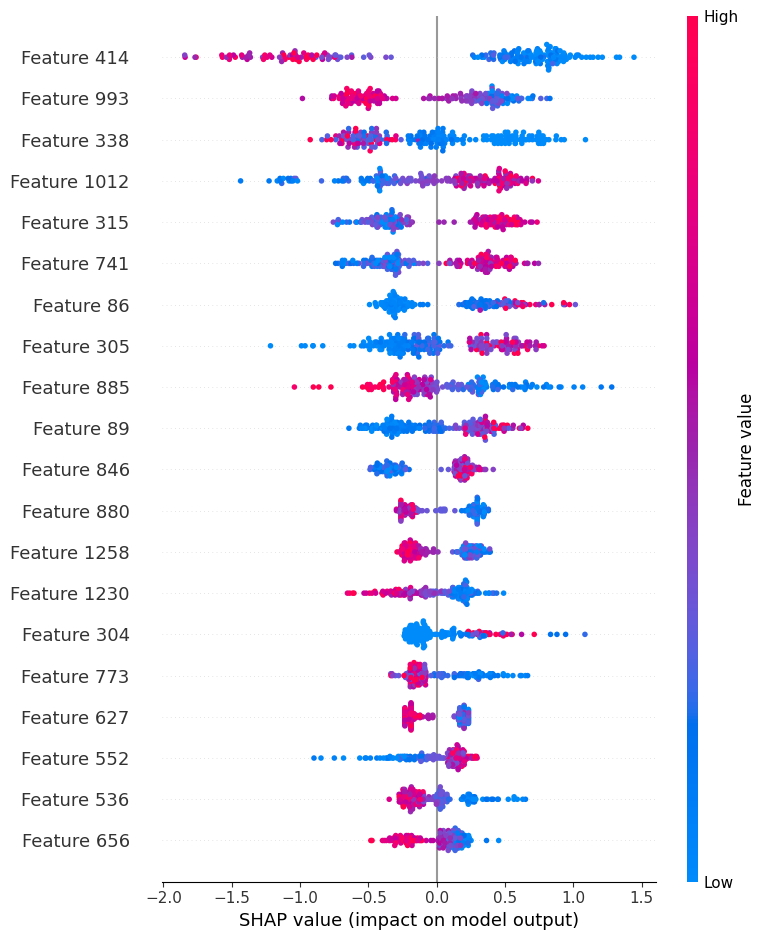

IndexError: invalid index to scalar variable.

In [ ]:
# Step 1: Install necessary packages (if not already installed)
!pip install shap matplotlib numpy pandas scikit-learn

# Step 2: Import necessary libraries
import xgboost as xgb
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score



# Step 4: Load your feature data and labels (adjust path as needed)
# Use np.load to load .npy files instead of pd.read_csv
X = np.load('/content/drive/MyDrive/MBC_Feat/features.npy')  # Features (VGG16 + VGG19)
y = np.load('/content/drive/MyDrive/MBC_Feat/labels.npy')    # Labels (0 = Benign, 1 = Malignant)

# Step 5: Check if the data is correctly loaded
print(f"Features shape: {X.shape}")  # Should print (number_of_samples, number_of_features)
print(f"Labels shape: {y.shape}")    # Should print (number_of_samples,)

# Step 6: Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Train an XGBoost model
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Step 8: Evaluate the model
y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Step 9: SHAP explanation for the model
# Create a SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Step 10: Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Step 11: Visualize SHAP summary plot (global explainability)
shap.summary_plot(shap_values, X_test)

# Step 12: Visualize SHAP force plot for a specific instance (local explainability)
shap.initjs()  # Initializes JS visualization for interactive plots

# Visualizing SHAP force plot for class 1 (Malignant) - make sure to use correct class
shap.force_plot(explainer.expected_value[1], shap_values[1][0], X_test[0])

# Step 13: Visualize SHAP dependence plot (how a single feature influences the prediction)
# Replace '0' with the feature index you're interested in
shap.dependence_plot(0, shap_values[1], X_test)  # 0 is the feature index (you can choose another feature index)


In [ ]:
# prompt: write me python code for generate grad cam of single image as input

import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, classifier_layer_names):
    # Make a model that maps the input image to the activations of the last conv layer
    # and the output predictions of the classifier
    last_conv_layer = model.get_layer(last_conv_layer_name)
    last_conv_layer_model = keras.Model(model.inputs, last_conv_layer.output)

    # Make a second model that maps the activations of the last conv layer to the outputs
    classifier_input = keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input
    for layer_name in classifier_layer_names:
        x = model.get_layer(layer_name)(x)
    classifier_model = keras.Model(classifier_input, x)

    # Compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        # Compute activations of the last conv layer and make the tape watch it
        last_conv_layer_output = last_conv_layer_model(img_array)
        tape.watch(last_conv_layer_output)
        # Compute predictions
        predictions = classifier_model(last_conv_layer_output)
        # Get the index of the top predicted class
        top_pred_index = tf.argmax(predictions[0])
        top_class_channel = predictions[:, top_pred_index]

    # This is the gradient of the top predicted class with regard to
    # the output feature map of the last convolutional layer
    grads = tape.gradient(top_class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient
    # over a channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each channel in the feature map by the importance of this channel
    # with regard to the top predicted class
    last_conv_layer_output = last_conv_layer_output.numpy()[0]
    pooled_grads = pooled_grads.numpy()
    for i in range(pooled_grads.shape[-1]):
        last_conv_layer_output[:, :, i] *= pooled_grads[i]

    # The heatmap is the average of all channel weights
    heatmap = np.mean(last_conv_layer_output, axis=-1)

    # Normalize the heatmap
    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)
    return heatmap.numpy()

def save_and_display_gradcam(img_path, heatmap, alpha=0.4):
    # Load the original image (in color for overlay)
    img = cv2.imread(img_path)
    # Ensure image is RGB if it was grayscale initially
    if len(img.shape) == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    # Resize the heatmap to the original image size
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Convert heatmap to a 3-channel image
    heatmap = np.uint8(255 * heatmap)

    # Apply a color map to the heatmap
    # Use cv2.COLORMAP_JET for a common color map
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Superimpose the heatmap on the original image
    superimposed_img = heatmap * alpha + img
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

    # Display the original and superimposed images
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.title("Grad-CAM Overlay")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    return superimposed_img # Return the superimposed image if needed

# === Example Usage ===
# Assuming you have a trained Keras model loaded or defined here
# For demonstration, let's create a dummy simple CNN model
def build_dummy_model(input_shape):
    model = keras.Sequential([
        keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape),
        keras.layers.MaxPooling2D(pool_size=(2, 2)),
        keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
        keras.layers.MaxPooling2D(pool_size=(2, 2)),
        keras.layers.Conv2D(128, kernel_size=(3, 3), activation='relu', name='last_conv_layer'), # Name this layer
        keras.layers.MaxPooling2D(pool_size=(2, 2)),
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation='relu', name='classifier_dense_1'), # Name classifier layers
        keras.layers.Dropout(0.5),
        keras.layers.Dense(1, activation='sigmoid', name='classifier_output')  # Binary classification
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Replace with your actual model loading/definition
# model = keras.models.load_model('your_model.h5')
# Or build your model architecture
model = build_dummy_model((512, 512, 3)) # Assuming input size 512x512 RGB

# Define the path to your image
img_path = "/content/drive/MyDrive/Dataset/Cancer/IMG (1).jpg" # Replace with your image path

# Define the target image size for the model (must match model's input shape)
img_size = (512, 512) # Assuming 512x512 input for the dummy model

# Define the name of the last convolutional layer in your model
# Find this name by inspecting your model summary: model.summary()
last_conv_layer_name = 'last_conv_layer' # Replace with the actual name

# Define the names of the classifier layers that come *after* the last conv layer
# These are typically Flatten, Dense, Dropout layers leading to the output
classifier_layer_names = ['flatten', 'classifier_dense_1', 'classifier_output'] # Replace with actual names in order

# Preprocess the image for the model
def get_img_array(img_path, size):
    img = keras.preprocessing.image.load_img(img_path, target_size=size, color_mode="rgb") # Ensure RGB
    array = keras.preprocessing.image.img_to_array(img)
    # We add a dimension to transform our array into a "batch" of size 1
    array = np.expand_dims(array, axis=0)
    # Preprocess the image based on your model's requirements (e.g., scaling)
    # For simple models, just scaling to 0-1 is common: array = array / 255.0
    # For models trained on ImageNet, use preprocess_input
    # Example for VGG19 or DenseNet if your model uses it:
    # from tensorflow.keras.applications.vgg19 import preprocess_input as vgg19_preprocess_input
    # array = vgg19_preprocess_input(array)
    # For this dummy model, let's just scale:
    array = array / 255.0
    return array

img_array = get_img_array(img_path, size=img_size)

# Ensure the image array shape matches the expected input shape of the model
if img_array.shape[1:] != model.input_shape[1:]:
    print(f"Error: Image array shape {img_array.shape[1:]} does not match model input shape {model.input_shape[1:]}")
else:
    # Generate heatmap
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name, classifier_layer_names)

    # Display heatmap
    plt.figure(figsize=(6,6))
    plt.imshow(heatmap, cmap='jet')
    plt.title("Grad-CAM Heatmap")
    plt.axis('off')
    plt.show()

    # Save and display superimposed image
    superimposed_image = save_and_display_gradcam(img_path, heatmap)

    # Optional: Save the superimposed image
    # cv2.imwrite('gradcam_result.jpg', superimposed_image)
    # print("Superimposed image saved as gradcam_result.jpg")



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ValueError: Input 0 of layer "classifier_dense_1" is incompatible with the layer: expected axis -1 of input shape to have value 492032, but received input with shape (None, 1968128)

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Predicted class: [('n03729826', 'matchstick', np.float32(0.14740248))]


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_13']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


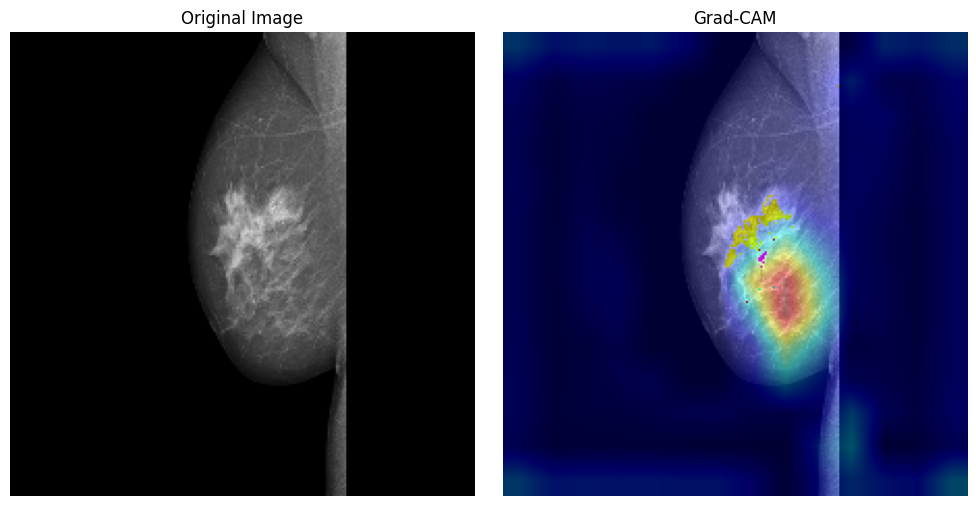

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K

# Load VGG16 model
model = VGG16(weights='imagenet')
model.summary()  # Optional: to see the architecture

# Load a cancerous image
img_path = '/content/drive/MyDrive/Dataset/Cancer/IMG (1).jpg'  # Change this path
img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

# Predict and get class index
preds = model.predict(x)
class_idx = np.argmax(preds[0])
print("Predicted class:", decode_predictions(preds, top=1)[0])

# Get the output of the last convolutional layer
last_conv_layer = model.get_layer('block5_conv3')

# Create a model that maps input image to activations of the last conv layer and predictions
grad_model = Model([model.inputs], [last_conv_layer.output, model.output])

# Compute gradient of the top predicted class with respect to last conv layer output
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(x)
    loss = predictions[:, class_idx]

grads = tape.gradient(loss, conv_outputs)

# Compute channel-wise mean of gradients
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# Multiply each channel in feature map array by "importance" of that channel
conv_outputs = conv_outputs[0]
heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

# Normalize between 0 and 1
heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
heatmap = heatmap.numpy()

# Load original image again (in BGR for OpenCV)
img = cv2.imread(img_path)
img = cv2.resize(img, (224, 224))

# Resize heatmap to image size and apply color map
heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)

# Superimpose heatmap on image
superimposed_img = heatmap_colored * 0.4 + img

# Convert BGR to RGB for matplotlib
superimposed_img = cv2.cvtColor(superimposed_img.astype(np.uint8), cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Grad-CAM")
plt.imshow(superimposed_img)
plt.axis('off')
plt.tight_layout()
plt.show()


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted class: [('n01930112', 'nematode', np.float32(0.72215664))]


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_82']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


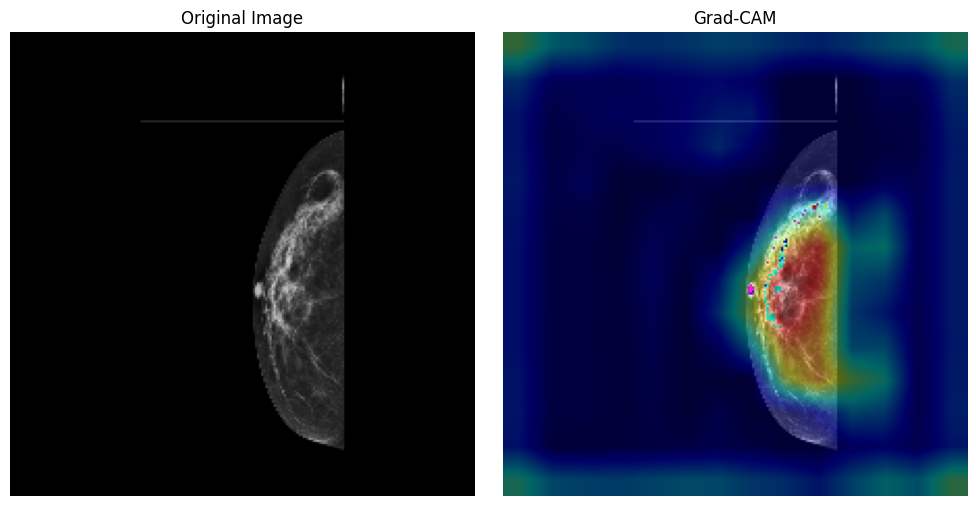

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K

# Load VGG16 model
model = VGG16(weights='imagenet')
model.summary()  # Optional: to see the architecture

# Load a cancerous image
img_path = '/content/drive/MyDrive/Dataset/Cancer/IMG (102).jpg'  # Change this path
img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

# Predict and get class index
preds = model.predict(x)
class_idx = np.argmax(preds[0])
print("Predicted class:", decode_predictions(preds, top=1)[0])

# Get the output of the last convolutional layer
last_conv_layer = model.get_layer('block5_conv3')

# Create a model that maps input image to activations of the last conv layer and predictions
grad_model = Model([model.inputs], [last_conv_layer.output, model.output])

# Compute gradient of the top predicted class with respect to last conv layer output
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(x)
    loss = predictions[:, class_idx]

grads = tape.gradient(loss, conv_outputs)

# Compute channel-wise mean of gradients
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# Multiply each channel in feature map array by "importance" of that channel
conv_outputs = conv_outputs[0]
heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

# Normalize between 0 and 1
heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
heatmap = heatmap.numpy()

# Load original image again (in BGR for OpenCV)
img = cv2.imread(img_path)
img = cv2.resize(img, (224, 224))

# Resize heatmap to image size and apply color map
heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)

# Superimpose heatmap on image
superimposed_img = heatmap_colored * 0.4 + img

# Convert BGR to RGB for matplotlib
superimposed_img = cv2.cvtColor(superimposed_img.astype(np.uint8), cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Grad-CAM")
plt.imshow(superimposed_img)
plt.axis('off')
plt.tight_layout()
plt.show()